# Phase 2 (projections variant) — Grid extension vs. standalone solar (share_dispersion)

Copy of `analyse_GIS_phase2/phase2_share_dispersion.ipynb`. Two changes from the original:

1. **PV/battery price & lifetime** (Section 1): `PV_EUR_KW`, `LIFE_PV`, `BAT_EUR_KWH` now come
   directly from the EnergyScope catalogue `reg_technologies.dat` (cross-checked against 2024
   retail prices, World Bank IDTR) instead of the Peña Balderrama et al. 2020 USD figures. `MV_EUR`,
   `CONN_EUR`, `OM_RATE`, `I_RATE`, and all SHS sizing assumptions (`BATT_DAYS`, `BATT_DOD`,
   `SYS_EFF`) are unchanged, as is the 2012 community geography and the ~1169 kWh/HH sizing.
2. **Section 7** (appended): re-runs the breakeven classification for three household scenarios —
   2024 (control, actual household counts, isolates the price/lifetime effect alone), 2035, and
   2050 (projected household counts by cluster from `projections/output/menages_projetes.csv`).

For every rural community in the study region we compare two ways to bring it electricity:
extending the medium-voltage (MV) grid, or installing a standalone solar home system (SHS).
Whichever is annually cheaper wins. The HH-weighted fraction of communities where the SHS wins,
per cluster, is `share_dispersion`.

Steps: parameters → per-municipality demand → SHS sizing → off-grid households already
electrified (Source B) → breakeven per community (Source B+C combined) → cluster aggregation →
projected household scenarios (2024/2035/2050).


In [86]:
import os
import pandas as pd

BASE = os.path.dirname(os.getcwd())            # repo root (notebook lives in analyse_GIS_phase2/)
OUT = "output"
os.makedirs(OUT, exist_ok=True)

# Cluster -> municipality membership (same mapping as analyse data ramp/demande.ipynb)
CLUSTERS = {
    "C1": ["Exaltación", "Reyes", "Santa_Rosa_Beni", "Ixiamas"],
    "C2": ["Bolpebra"],
    "C3": ["Guayaramerín", "Riberalta", "Puerto_Gonzalo_Moreno"],
    "C4": ["Bella_Flor", "Filadelfia", "Ingavi", "Nueva_Esperanza",
           "Porvenir", "Puerto_Rico", "San_Lorenzo", "San_Pedro",
           "Santa_Rosa_Pando", "Santos_Mercado", "Sena", "Villa_Nueva"],
    "C5": ["Cobija"],
}
MUNI_TO_CLUSTER = {m: c for c, munis in CLUSTERS.items() for m in munis}


## 1. Parameters

Cost data is from **Peña Balderrama et al. 2020, *Energy for Sustainable Development* 56**,
Table A.5 (grid extension) and Table A.7 (standalone SHS). FX and discount rate are fixed
model-wide conventions.


In [87]:
FX = 0.924          # 1 USD = 0.924 EUR — 2024 annual average (IRS/ECB)
I_RATE = 0.10        # model discount rate — Misc_indep.json

# Raw USD costs — Peña Balderrama et al. 2020, ESD 56 (MV/connection unchanged)
MV_USD = 9_000        # USD/km, MV 33kV extension — Table A.5
CONN_USD = 150        # USD/HH, last-mile connection — Table A.5
OM_RATE = 0.02        # %/yr O&M on overnight capex — Tables A.5/A.7
LIFE_MV = 30           # years — Table A.5

MV_EUR = MV_USD * FX
CONN_EUR = CONN_USD * FX

# PV and battery capex/lifetime — EnergyScope catalogue reg_technologies.dat, cross-checked
# against 2024 retail prices (World Bank IDTR). Replaces the Peña Balderrama et al. 2020 USD
# figures (Table A.7) used for these two parameters elsewhere in analyse_GIS_phase2/.
PV_EUR_KW = 2_730     # EUR/kW, standalone PV — reg_technologies.dat:10, retail 2024 x-checked IDTR World Bank
LIFE_PV = 20          # years — reg_technologies.dat:10, same source
BAT_EUR_KWH = 594     # EUR/kWh, battery — reg_technologies.dat:138
LIFE_BAT = 10          # years — unchanged

# SHS sizing assumptions — standard tropical off-grid design
SYS_EFF = 0.75       # PV -> usable AC, incl. battery/inverter/wiring losses
BATT_DAYS = 2        # days of autonomy
BATT_DOD = 0.80       # depth of discharge


def crf(r, n):
    """Capital recovery factor: annualizes an overnight cost over n years at rate r."""
    return r * (1 + r) ** n / ((1 + r) ** n - 1)


CRF_MV = crf(I_RATE, LIFE_MV)
CRF_PV = crf(I_RATE, LIFE_PV)
CRF_BAT = crf(I_RATE, LIFE_BAT)

pd.DataFrame([
    {"Parameter": "FX (USD->EUR)", "Value": FX, "Source": "2024 annual avg, IRS/ECB"},
    {"Parameter": "i_rate", "Value": I_RATE, "Source": "Misc_indep.json"},
    {"Parameter": "MV extension", "Value": f"{MV_USD} USD/km -> {MV_EUR:.0f} EUR/km", "Source": "Peña Balderrama 2020, Table A.5"},
    {"Parameter": "Connection", "Value": f"{CONN_USD} USD/HH -> {CONN_EUR:.1f} EUR/HH", "Source": "Peña Balderrama 2020, Table A.5"},
    {"Parameter": "PV capex", "Value": f"{PV_EUR_KW} EUR/kW", "Source": "reg_technologies.dat:10, retail 2024 x-checked IDTR World Bank"},
    {"Parameter": "Battery capex", "Value": f"{BAT_EUR_KWH} EUR/kWh", "Source": "reg_technologies.dat:138"},
    {"Parameter": "O&M rate", "Value": OM_RATE, "Source": "Peña Balderrama 2020, Tables A.5/A.7"},
    {"Parameter": "Lifetime MV/PV/Bat", "Value": f"{LIFE_MV}/{LIFE_PV}/{LIFE_BAT} y", "Source": "Table A.5 (MV) / reg_technologies.dat (PV, Bat)"},
    {"Parameter": "System efficiency", "Value": SYS_EFF, "Source": "off-grid SHS design assumption"},
    {"Parameter": "Battery autonomy", "Value": f"{BATT_DAYS} days", "Source": "off-grid SHS design assumption"},
    {"Parameter": "Depth of discharge", "Value": BATT_DOD, "Source": "off-grid SHS design assumption"},
    {"Parameter": "CRF_MV/PV/Bat", "Value": f"{CRF_MV:.5f}/{CRF_PV:.5f}/{CRF_BAT:.5f}", "Source": f"CRF(i={I_RATE}, n)"},
])


,Parameter,Value,Source
0,FX (USD->EUR),0.924,"2024 annual avg, IRS/ECB"
1,i_rate,0.1,Misc_indep.json
2,MV extension,9000 USD/km -> 8316 EUR/km,"Peña Balderrama 2020, Table A.5"
3,Connection,150 USD/HH -> 138.6 EUR/HH,"Peña Balderrama 2020, Table A.5"
4,PV capex,2730 EUR/kW,"reg_technologies.dat:10, retail 2024 x-checked..."
5,Battery capex,594 EUR/kWh,reg_technologies.dat:138
6,O&M rate,0.02,"Peña Balderrama 2020, Tables A.5/A.7"
7,Lifetime MV/PV/Bat,30/20/10 y,"Table A.5 (MV) / reg_technologies.dat (PV, Bat)"
8,System efficiency,0.75,off-grid SHS design assumption
9,Battery autonomy,2 days,off-grid SHS design assumption


## 2. Per-municipality demand

Annual electricity per household, `per_hh_kWh = sum(all sufficiency_* columns except
sufficiency_water_heating) / total_hh + ECS_APPOINT_KWH_HH`.

- **RAMP load curves**: `analyse data ramp/sufficiency/data ramp/<municipality>/load_curve_energy_service_full_year_Norte_Amazonia.csv`
  (power in W at 1-minute steps over a year → kWh = W·min / 60,000)
- **Total households**: `exctraction of data/output/CSV_final.csv`, Bolivia Census 2024 column
  `NÚMERO DE VIVIENDAS POR FUENTE DE ELECTRICIDAD | 2024 | Total`

**`sufficiency_water_heating` is excluded** from the electric SHS sizing: dispersed/off-grid
households do not run electric water heating in reality (thermosiphon, direct solar, or no hot
water at all), so including it would over-size the standalone PV+battery system and understate
`share_dispersion`. Only the small electric-resistance fraction found in the "appoint réaliste"
sufficiency variant (`EnergyScope_BO_nord_amazonia`, DEC_HP_ELEC/TS_DEC_HP_ELEC f_max=0, DEC_SOLAR
backed by DEC_DIRECT_ELEC as host tech) is added back, via `ECS_APPOINT_KWH_HH` below.

The RAMP "sufficiency" scenario is uniform by design, so every municipality should land close to
the same per-HH value — used here as a sanity check, not just a calculation.


In [88]:
csv_final = pd.read_csv(
    os.path.join(BASE, "exctraction of data/output/CSV_final.csv"), encoding="utf-8-sig"
)
hh_col = [c for c in csv_final.columns if "2024" in c and "Total" in c and "VIVIENDA" in c.upper()][0]


def std_muni_name(depto, raw):
    """Match CSV_final's municipality names to the CLUSTERS keys.
    'Santa Rosa' exists in both Beni and Pando — disambiguate by department."""
    raw = str(raw).strip()
    if raw == "Santa Rosa":
        return "Santa_Rosa_Beni" if depto == "Beni" else "Santa_Rosa_Pando"
    return raw.replace(" ", "_")


muni_rows = csv_final[csv_final["MUNICIPIO/TIOC"].notna()]
total_hh = {
    std_muni_name(row["DEPARTAMENTO"], row["MUNICIPIO/TIOC"]): row[hh_col]
    for _, row in muni_rows.iterrows()
    if std_muni_name(row["DEPARTAMENTO"], row["MUNICIPIO/TIOC"]) in MUNI_TO_CLUSTER
}
assert set(total_hh) == set(MUNI_TO_CLUSTER), "missing total_hh for some municipalities"


In [89]:
RAMP_DIR = os.path.join(BASE, "analyse data ramp/sufficiency/data ramp")

# APPOINT_ELEC_SHARE: region-wide fraction of decentralised hot-water (ECS / HEAT_LOW_T_DECEN)
# service met by the electric resistance host tech (DEC_DIRECT_ELEC) in the "appoint réaliste"
# sufficiency variant of EnergyScope_BO_nord_amazonia (Data/2025/sufficiency/C{1-5}/Technologies.csv:
# DEC_HP_ELEC and TS_DEC_HP_ELEC f_max=0, so DEC_SOLAR is backed by DEC_DIRECT_ELEC as host tech).
# Source: sufficiency_phase2 run (2026-07-19/20), region-wide DEC_DIRECT_ELEC HEAT_LOW_T_DECEN
# production / total "Hot water" demand = 3.9468 / 71.6685 GWh = 0.04825.
APPOINT_ELEC_SHARE = 0.04825
ECS_APPOINT_KWH_HH = 851 * APPOINT_ELEC_SHARE  # kWh/HH/yr added back as electric appoint

per_hh_kwh = {}
no_ramp_file = []

for muni in MUNI_TO_CLUSTER:
    path = os.path.join(RAMP_DIR, muni, "load_curve_energy_service_full_year_Norte_Amazonia.csv")
    if not os.path.exists(path):
        no_ramp_file.append(muni)
        continue
    df = pd.read_csv(path)
    # sufficiency_water_heating excluded on purpose (see section 2 markdown): dispersed/off-grid
    # households do not run electric water heating in reality. Only ECS_APPOINT_KWH_HH (the small
    # electric-resistance fraction from étape A) is added back below, uniformly per household.
    suff_cols = [c for c in df.columns if c.startswith("sufficiency_") and c != "sufficiency_water_heating"]
    kwh_total = df[suff_cols].sum().sum() / 60_000.0
    per_hh_kwh[muni] = kwh_total / total_hh[muni] + ECS_APPOINT_KWH_HH

# A few municipalities (e.g. Guayaramerín) have no RAMP run -> use the
# total_hh-weighted average of their cluster peers instead.
for muni in no_ramp_file:
    cluster = MUNI_TO_CLUSTER[muni]
    peers = [p for p in CLUSTERS[cluster] if p in per_hh_kwh]
    per_hh_kwh[muni] = (sum(per_hh_kwh[p] * total_hh[p] for p in peers)
                        / sum(total_hh[p] for p in peers))
    print(f"{muni}: no RAMP file -> fallback to {cluster} average over {peers}")

demand = pd.DataFrame([
    {"Cluster": MUNI_TO_CLUSTER[m], "Municipio": m, "total_hh": total_hh[m],
     "per_hh_kWh": round(per_hh_kwh[m], 1)}
    for m in MUNI_TO_CLUSTER
]).sort_values(["Cluster", "Municipio"])

mean_kwh = demand["per_hh_kWh"].mean()
demand["pct_dev_from_mean"] = (demand["per_hh_kWh"] / mean_kwh - 1) * 100
print(f"mean per_hh_kWh = {mean_kwh:.1f}  (sufficiency scenario is uniform by design; "
      f"ECS_APPOINT_KWH_HH = {ECS_APPOINT_KWH_HH:.2f} kWh/HH/yr added to every municipality)")
demand


mean per_hh_kWh = 1168.9  (sufficiency scenario is uniform by design; ECS_APPOINT_KWH_HH = 41.06 kWh/HH/yr added to every municipality)


,Cluster,Municipio,total_hh,per_hh_kWh,pct_dev_from_mean
0,C1,Exaltación,1455.0,1173.8,0.416743
3,C1,Ixiamas,3306.0,1131.4,-3.210510
1,C1,Reyes,3417.0,1158.1,-0.926367
2,C1,Santa_Rosa_Beni,2755.0,1176.3,0.630614
4,C2,Bolpebra,802.0,1166.8,-0.182096
5,C3,Guayaramerín,10891.0,1175.3,0.545066
7,C3,Puerto_Gonzalo_Moreno,1965.0,1173.4,0.382524
6,C3,Riberalta,27442.0,1174.9,0.510846
8,C4,Bella_Flor,1235.0,1169.4,0.040330
9,C4,Filadelfia,2514.0,1164.3,-0.395967


In [90]:
flagged = demand[demand["pct_dev_from_mean"].abs() > 5]
if len(flagged):
    print("FLAGGED — more than 5% off the mean:")
    print(flagged)
else:
    print("All municipalities within 5% of the mean — sanity check passed.")


All municipalities within 5% of the mean — sanity check passed.


## 3. Standalone SHS sizing

Each household's PV + battery system is sized to cover its own municipality's demand:

- PV size: `kWh/yr / (CF × 8760 × η_system)`, with `η_system = 0.75`
- Battery size: `(2 days autonomy × daily kWh) / depth_of_discharge`
- Solar capacity factor (CF) per cluster: mean of the `PV` column in
  `analyse data ramp/sufficiency/output_energyscope/<cluster>/Time_series.csv` (EnergyScope's own solar profile)


**Note — no thermosiphon/solar-water-heater capex added to the breakeven.** ECS (hot water) is
served in this model by `DEC_SOLAR` backed by `DEC_DIRECT_ELEC` as host tech (see étape A) — the
real-world equivalent is a solar thermosiphon with a small electric-resistance backup. This
equipment is needed by households on **both sides** of the breakeven comparison (grid-connected
and dispersed/SHS alike), so its cost cancels out and is deliberately **not** added to either the
`extension` or `standalone` annual cost in `classify_communities`. Only the electric-resistance
kWh (`ECS_APPOINT_KWH_HH`, added to `per_hh_kwh` above) affects PV+battery sizing, since that
portion is genuinely electric.


In [91]:
cf_pv = {}
for cluster in CLUSTERS:
    ts = pd.read_csv(
        os.path.join(BASE, f"analyse data ramp/sufficiency/output_energyscope/{cluster}/Time_series.csv"),
        sep=";", index_col=0,
    )
    cf_pv[cluster] = ts["PV"].mean()


def size_shs(kwh_per_year, cf, crf_pv=CRF_PV, crf_bat=CRF_BAT):
    """Return (overnight capex, annualized cost) in EUR per household."""
    pv_kw = kwh_per_year / (cf * 8760 * SYS_EFF)
    bat_kwh = (BATT_DAYS * kwh_per_year / 365) / BATT_DOD
    pv_eur = pv_kw * PV_EUR_KW
    bat_eur = bat_kwh * BAT_EUR_KWH
    capex = pv_eur + bat_eur
    annual = crf_pv * pv_eur + crf_bat * bat_eur + OM_RATE * capex
    return capex, annual


shs_capex, shs_annual = {}, {}
for muni, kwh in per_hh_kwh.items():
    shs_capex[muni], shs_annual[muni] = size_shs(kwh, cf_pv[MUNI_TO_CLUSTER[muni]])

pd.DataFrame([
    {"Cluster": MUNI_TO_CLUSTER[m], "Municipio": m,
     "overnight_capex_EUR_HH": round(shs_capex[m], 0),
     "annual_EUR_HH": round(shs_annual[m], 2)}
    for m in MUNI_TO_CLUSTER
]).sort_values(["Cluster", "Municipio"])


,Cluster,Municipio,overnight_capex_EUR_HH,annual_EUR_HH
0,C1,Exaltación,7580.0,1258.21
3,C1,Ixiamas,7306.0,1212.80
1,C1,Reyes,7479.0,1241.38
2,C1,Santa_Rosa_Beni,7596.0,1260.89
4,C2,Bolpebra,7582.0,1257.14
5,C3,Guayaramerín,7576.0,1257.87
7,C3,Puerto_Gonzalo_Moreno,7563.0,1255.82
6,C3,Riberalta,7573.0,1257.49
8,C4,Bella_Flor,7712.0,1275.52
9,C4,Filadelfia,7678.0,1269.91


## 4. Breakeven per community

For each community, compare the annualized cost of extending the grid against the annualized SHS
cost. Community-level inputs (distance to nearest line, household count) come from
`analyse_GIS_phase2/output/task1_community_distances_lines.csv`, built upstream in
`gis_phase2_analysis.ipynb`. Household count used in the classification below is Source C
(unelectrified, no-tiene 2012 scaled to 2024) **plus** Source B (already off-grid electrified —
counted in section 5): they live in the same communities and share the same line/distance, so the
connection decision reflects everyone who would benefit from it.

$$\text{annual\_extension} = (CRF_{MV} + OM) \times MV_{EUR/km} \times \frac{dist}{HH} + (CRF_{MV} + OM) \times CONN_{EUR}$$

A community is **dispersed** (SHS wins) if its annual SHS cost is lower than this. The breakeven
distance `d*` is where the two costs are equal — it scales with household count.


In [92]:
task1 = pd.read_csv(
    os.path.join(BASE, "analyse_GIS_phase2/output/task1_community_distances_lines.csv"),
    encoding="utf-8-sig",
)


def classify_communities(communities, shs_annual_by_muni, mv_eur_per_km, conn_eur, crf_mv):
    rows = []
    for _, row in communities.iterrows():
        muni, dist, hh = row["Municipio_std"], row["distance_km"], row["HH_2024_scaled"]
        if hh <= 0:
            continue
        standalone = shs_annual_by_muni[muni]
        slope = (crf_mv + OM_RATE) * mv_eur_per_km
        extension = slope * dist / hh + (crf_mv + OM_RATE) * conn_eur
        d_star = max((standalone - (crf_mv + OM_RATE) * conn_eur) * hh / slope, 0.0)
        rows.append({
            "Cluster": row["Cluster"], "Comunidad": row["Comunidad"], "Municipio_std": muni,
            "HH": hh, "distance_km": dist, "nearest_line_type": row["nearest_line_type"],
            "annual_extension_EUR_HH": round(extension, 2),
            "annual_standalone_EUR_HH": round(standalone, 2),
            "dispersed": standalone < extension,
            "breakeven_distance_km": round(d_star, 3),
        })
    return pd.DataFrame(rows)


## 5. Off-grid households already electrified (Source B)

Source B households are already electrified off-grid in 2012 (diesel generator, solar panel, or
other). They live in the **same communities** as Source C, so the distance and line infrastructure
are shared. Adding them to each community increases its household count, which lowers the per-HH
line cost and can make a community connectable that Source C alone would not justify.

Sources:
- **2012 community counts**: `analyse_GIS_phase2/data/comunidades_electricidad_2012.csv`,
  columns `Motor`, `Panel`, `Otra` (capped at `Hog_Elec - Red_elec` to avoid double-counting)
- **2024 municipal totals**: `exctraction of data/output/CSV_final.csv`, 2024 Motor/Panel/Otra columns


In [93]:
# Home-system unit sizes — aligned with analyse data ramp/reality/home_systems.ipynb
# Source: ENDE BO-L1222 / Programa de Electrificación Rural
PANEL_W = 50                   # Wp per panel-HH (ENDE PEVD kit: >=50 Wp policristalino)
GEN_W = 500                    # W per generator-HH (assumption, no field data — sensitivity at 350 W)
BATT_KWH_PER_PANEL_HH = 0.123  # kWh per panel-HH (ENDE PEVD kit: 123 Wh lithium 12V)


In [94]:
# ── 2024 municipal B totals from CSV_final ────────────────────────────────────
motor_col = [c for c in csv_final.columns if "2024" in c and "Motor" in c and "VIVIENDA" in c.upper()][0]
panel_col = [c for c in csv_final.columns if "2024" in c and "Panel" in c][0]
otra_col  = [c for c in csv_final.columns if "2024" in c and "Otra"  in c][0]
print("Source B columns from CSV_final:")
print(f"  motor: '{motor_col}'")
print(f"  panel: '{panel_col}'")
print(f"  otra:  '{otra_col}'")

muni_b = {}   # muni -> {total, motor, panel, otra}
for _, row in csv_final[csv_final["MUNICIPIO/TIOC"].notna()].iterrows():
    name = std_muni_name(row["DEPARTAMENTO"], row["MUNICIPIO/TIOC"])
    if name in MUNI_TO_CLUSTER:
        muni_b[name] = {
            "total": row[motor_col] + row[panel_col] + row[otra_col],
            "motor": row[motor_col],
            "panel": row[panel_col],
            "otra":  row[otra_col],
        }

b_check = pd.DataFrame([
    {"Cluster": MUNI_TO_CLUSTER[m], "Municipio": m,
     "Motor_2024": muni_b[m]["motor"], "Panel_2024": muni_b[m]["panel"],
     "Otra_2024": muni_b[m]["otra"], "B_total_2024": muni_b[m]["total"]}
    for m in MUNI_TO_CLUSTER
]).sort_values(["Cluster", "Municipio"])
print(f"\nTotal B households across all municipalities: {b_check['B_total_2024'].sum():.0f}")
b_check


Source B columns from CSV_final:
  motor: 'NÚMERO DE VIVIENDAS POR FUENTE DE ELECTRICIDAD | 2024 | Motor propio'
  panel: 'NÚMERO DE VIVIENDAS POR FUENTE DE ELECTRICIDAD | 2024 | Panel solar'
  otra:  'NÚMERO DE VIVIENDAS POR FUENTE DE ELECTRICIDAD | 2024 | Otra'

Total B households across all municipalities: 9325


,Cluster,Municipio,Motor_2024,Panel_2024,Otra_2024,B_total_2024
0,C1,Exaltación,203.0,664.0,23.0,890.0
3,C1,Ixiamas,337.0,353.0,103.0,793.0
1,C1,Reyes,96.0,213.0,44.0,353.0
2,C1,Santa_Rosa_Beni,198.0,405.0,17.0,620.0
4,C2,Bolpebra,160.0,216.0,17.0,393.0
5,C3,Guayaramerín,166.0,383.0,97.0,646.0
7,C3,Puerto_Gonzalo_Moreno,48.0,58.0,126.0,232.0
6,C3,Riberalta,422.0,692.0,282.0,1396.0
8,C4,Bella_Flor,67.0,160.0,88.0,315.0
9,C4,Filadelfia,334.0,240.0,34.0,608.0


In [95]:
# ── Load 2012 community-level electrification survey ─────────────────────────
# Columns used below: Comunidad, Motor/Panel/Otra (off-grid counts), Hog_Elec, Red_elec.
# Note: this file encodes one municipality as "Tercera Sección - Santa Rosa" (Depto = Beni), which
# the name-extraction regex turns into "Santa Rosa" — disambiguated below by department so it
# joins correctly with task1.
com2012 = pd.read_csv(
    os.path.join(BASE, "analyse_GIS_phase2/data/comunidades_electricidad_2012.csv"),
    encoding="utf-8-sig", low_memory=False,
)
com2012["Municipio_std"] = com2012["Municipio"].str.extract(r"- (.+)$")[0].str.strip()
com2012["Municipio_std"] = com2012["Municipio_std"].fillna(com2012["Municipio"].str.strip())

# "Santa Rosa" is ambiguous (exists in both Beni and Pando) — disambiguate by department BEFORE
# the general space->underscore normalization below, since "Santa_Rosa" alone isn't a valid
# MUNI_TO_CLUSTER key. Substring match (not exact): Pando's community is recorded as "Santa Rosa
# del Abuná", not literally "Santa Rosa" — same substring gis_phase2_analysis.ipynb's own
# MUNI_FILTER (cell 5) already uses for this municipality, so this isn't a new assumption.
is_santa_rosa = com2012["Municipio_std"].str.contains("Santa Rosa", na=False)
com2012.loc[is_santa_rosa & (com2012["Depto"] == "Beni"), "Municipio_std"] = "Santa_Rosa_Beni"
com2012.loc[is_santa_rosa & (com2012["Depto"] == "Pando"), "Municipio_std"] = "Santa_Rosa_Pando"
print(f"renamed {is_santa_rosa.sum()} 'Santa Rosa*' rows by department "
      f"({(com2012['Municipio_std'] == 'Santa_Rosa_Beni').sum()} -> Santa_Rosa_Beni, "
      f"{(com2012['Municipio_std'] == 'Santa_Rosa_Pando').sum()} -> Santa_Rosa_Pando)")

# Villa Nueva: raw name carries a parenthetical suffix, "Villa Nueva (Loma Alta)", not stripped by
# the general space->underscore replace below. Single case, no department ambiguity (only Pando).
is_villa_nueva = com2012["Municipio_std"].str.contains("Villa Nueva", na=False)
com2012.loc[is_villa_nueva, "Municipio_std"] = "Villa_Nueva"
print(f"renamed {is_villa_nueva.sum()} 'Villa Nueva*' rows -> Villa_Nueva")

# General normalization: MUNI_TO_CLUSTER and task1's own Municipio_std use underscores for every
# multi-word name (e.g. "Puerto_Gonzalo_Moreno"), not just the two cases above. The previous ad
# hoc single-case patch left every other multi-word municipality as space-separated, so it was
# silently dropped by the isin() filter below — no error, no warning.
com2012["Municipio_std"] = com2012["Municipio_std"].str.replace(" ", "_", regex=False)

# Blocking assertion: every municipality in MUNI_TO_CLUSTER must have at least one matching row
# here, or Source B for it silently resolves to 0 downstream (via cell 17's reindex().fillna(0)).
present = set(com2012["Municipio_std"].unique())
missing = set(MUNI_TO_CLUSTER) - present
assert not missing, f"No com2012 rows match these MUNI_TO_CLUSTER municipalities: {sorted(missing)}"
print("All MUNI_TO_CLUSTER municipalities have a match in com2012 -> OK")

# ── 2012 community-level B counts → scale to 2024 ──────────────────────────
# B_2012 = min(Motor+Panel+Otra, Hog_Elec - Red_elec) to avoid double-counting
study_b = com2012[com2012["Municipio_std"].isin(MUNI_TO_CLUSTER)].copy()
study_b["B_2012_raw"] = (study_b["Motor"].fillna(0)
                         + study_b["Panel"].fillna(0)
                         + study_b["Otra"].fillna(0))
study_b["B_cap"]  = (study_b["Hog_Elec"].fillna(0) - study_b["Red_elec"].fillna(0)).clip(lower=0)
study_b["B_2012"] = study_b[["B_2012_raw", "B_cap"]].min(axis=1)
study_b["Panel_2012"] = study_b["Panel"].fillna(0)
study_b["Motor_2012"] = study_b["Motor"].fillna(0)
study_b["Otra_2012"]  = study_b["Otra"].fillna(0)
study_b["Comunidad_norm"] = study_b["Comunidad"].str.strip().str.upper()

# Scale each community's 2012 count proportionally to the 2024 municipal total
# (same method used for Source C scaling to 2024). Panel/Motor/Otra scale to their
# own 2024 municipal totals; "Otra" is kept separate here and split 50/50 later.
for col_2012, b_key in [("B_2012", "total"), ("Panel_2012", "panel"),
                        ("Motor_2012", "motor"), ("Otra_2012", "otra")]:
    col_2024 = col_2012.replace("_2012", "_2024")
    denom = study_b.groupby("Municipio_std")[col_2012].transform("sum")
    b24   = study_b["Municipio_std"].map({m: muni_b[m][b_key] for m in muni_b})
    study_b[col_2024] = (study_b[col_2012] / denom.replace(0, float("nan")) * b24).fillna(0)

# Aggregate to (Municipio_std, Comunidad_norm) — removes any duplicate rows
b_comm = (
    study_b.groupby(["Municipio_std", "Comunidad_norm"])[["B_2024", "Panel_2024", "Motor_2024", "Otra_2024"]]
    .sum()
    .reset_index()
)
print(f"Communities with B data: {len(b_comm)} (out of {len(task1)} in task1)")

renamed 127 'Santa Rosa*' rows by department (29 -> Santa_Rosa_Beni, 15 -> Santa_Rosa_Pando)
renamed 21 'Villa Nueva*' rows -> Villa_Nueva
All MUNI_TO_CLUSTER municipalities have a match in com2012 -> OK
Communities with B data: 706 (out of 697 in task1)


In [96]:
# ── Assign B values onto task1 without merging (avoids row duplication) ───
# Some community names repeat within a municipality (e.g. "San Pedro" in Bella_Flor).
# Indexing by (Municipio_std, Comunidad_norm) preserves the exact 697-row structure of task1.
BCOLS = ["B_2024", "Panel_2024", "Motor_2024", "Otra_2024"]
b_indexed = b_comm.set_index(["Municipio_std", "Comunidad_norm"])[BCOLS]

task1_bc = task1.copy()
task1_bc["Comunidad_norm"] = task1_bc["Comunidad"].str.strip().str.upper()

# Join key: (Municipio_std, Comunidad_norm) -- unchanged from before. What changes is how the
# per-community b_comm value is applied when this key isn't unique within task1: previously
# .reindex() assigned the SAME (already-summed) value to every task1 row sharing a key, silently
# doubling (or tripling) B_2024 wherever two physically distinct communities share a name within
# one municipality (e.g. two "SAN ANTONIO" in Sena, three "PALESTINA" in Riberalta). Fixed by
# splitting the b_comm value across homonymous rows instead of duplicating it, weighted by each
# row's 2012 population (Poblacion_2012 -- task1's own 2012-vintage size weight, the natural
# choice for splitting a household count without an independent per-row 2012 household figure)
# when the group's total population is nonzero, or equally when it is not.
GROUP_KEYS = ["Municipio_std", "Comunidad_norm"]
group_pop = task1_bc.groupby(GROUP_KEYS)["Poblacion_2012"].transform("sum")
n_in_group = task1_bc.groupby(GROUP_KEYS)["Comunidad_norm"].transform("size")
share = (task1_bc["Poblacion_2012"] / group_pop).where(group_pop > 0, 1.0 / n_in_group)

key_index = pd.MultiIndex.from_frame(task1_bc[GROUP_KEYS])
b_per_key = b_indexed.reindex(key_index).fillna(0.0)
for col in BCOLS:
    task1_bc[col] = b_per_key[col].values * share.values

n_dup_rows = int((n_in_group > 1).sum())
n_dup_groups = int(task1_bc.loc[n_in_group > 1, GROUP_KEYS].drop_duplicates().shape[0])
print(f"Homonym groups (>1 community sharing the same name within a municipality): "
      f"{n_dup_groups}, rows involved: {n_dup_rows}")

matched_b = (task1_bc["B_2024"] > 0).sum()
print(f"Communities with B households matched: {matched_b}/{len(task1_bc)}")
total_assigned = task1_bc["B_2024"].sum()
print(f"Total B households assigned: {total_assigned:.4f}")
census_total = sum(muni_b[m]["total"] for m in muni_b)
print(f"  (municipal totals from CSV_final: {census_total:.0f})")

# Known residual: com2012 community names with no match in task1's GIS layer at all (pre-existing
# data-quality gap between two independently-compiled community lists -- distinct from the two
# defects fixed above, not addressed here). Accounted for explicitly rather than silently ignored,
# so the blocking assertion below catches any *unexplained* gap.
task1_keys_set = set(zip(task1_bc["Municipio_std"], task1_bc["Comunidad_norm"]))
b_comm_keys_set = set(zip(b_comm["Municipio_std"], b_comm["Comunidad_norm"]))
orphan_keys = b_comm_keys_set - task1_keys_set
orphan_total = (b_comm.set_index(["Municipio_std", "Comunidad_norm"]).loc[list(orphan_keys), "B_2024"].sum()
                if orphan_keys else 0.0)
print(f"  Known residual: {len(orphan_keys)} 2012-census community names have no match in task1 "
      f"-> {orphan_total:.1f} households unavoidably unassigned by this join (community-name "
      f"mismatch between 2012 census and GIS layer, not fixed here)")

# Blocking assertion: every household in the census total must be either assigned or accounted for
# by the known residual above -- i.e. no unexplained gap beyond the two fixed defects.
assert abs((total_assigned + orphan_total) - census_total) < 1.0, (
    f"assigned ({total_assigned:.1f}) + known residual ({orphan_total:.1f}) != census total "
    f"({census_total:.0f}): unexplained gap beyond the two fixed defects and the known "
    "community-name mismatch"
)
print(f"ASSERTION (assigned + known residual == census total {census_total:.0f}) -> OK")

# HH for breakeven = C (no-tiene scaled) + B — larger HH → lower per-HH extension cost,
# so a community with enough B households can be connectable even if C alone wouldn't be.
task1_bc["HH_2024_scaled"] = task1_bc["HH_2024_scaled"] + task1_bc["B_2024"]

communities_bc = classify_communities(task1_bc, shs_annual, MV_EUR, CONN_EUR, CRF_MV)

# Attach Panel/Motor/Otra for TECH_HS estimation.
# classify_communities skips rows with HH <= 0 and returns results in the same order —
# so we can align by position with the non-zero-HH rows of task1_bc.
task1_bc_valid = task1_bc[task1_bc["HH_2024_scaled"] > 0].reset_index(drop=True)
communities_bc["Panel_2024"] = task1_bc_valid["Panel_2024"].values
communities_bc["Motor_2024"] = task1_bc_valid["Motor_2024"].values
communities_bc["Otra_2024"]  = task1_bc_valid["Otra_2024"].values

print(f"{len(communities_bc)} communities: "
      f"{(~communities_bc['dispersed']).sum()} connectable, {communities_bc['dispersed'].sum()} dispersed")

Homonym groups (>1 community sharing the same name within a municipality): 20, rows involved: 41
Communities with B households matched: 604/697
Total B households assigned: 9078.0789
  (municipal totals from CSV_final: 9325)
  Known residual: 30 2012-census community names have no match in task1 -> 246.9 households unavoidably unassigned by this join (community-name mismatch between 2012 census and GIS layer, not fixed here)
ASSERTION (assigned + known residual == census total 9325) -> OK
697 communities: 444 connectable, 253 dispersed


## 6. Aggregate per cluster

`share_dispersion` is the fraction of ALL households (Source A + B + C, from CSV_final) in a
cluster that end up off-grid (SHS) rather than grid-connected.


In [97]:
def aggregate_clusters(comm_bc):
    # Denominator = total HH per cluster from CSV_final (Source A + B + C)
    rows = []
    for cluster in CLUSTERS:
        sub = comm_bc[comm_bc["Cluster"] == cluster]
        total_hh_csv  = sum(total_hh[m] for m in CLUSTERS[cluster])   # A+B+C denominator
        hh_dispersed  = sub.loc[sub["dispersed"], "HH"].sum()
        connectable   = ~sub["dispersed"]
        ext_line = (sub.loc[connectable, "distance_km"] * MV_EUR).sum()
        ext_conn = sub.loc[connectable, "HH"].sum() * CONN_EUR         # C+B connectable HH

        # Dispersed B: existing off-grid equipment fed to EnergyScope as brownfield f_min.
        # Unit sizes from ENDE (PANEL_W / GEN_W / BATT_KWH_PER_PANEL_HH), aligned with home_systems.ipynb.
        # "Otra" (unspecified off-grid source) split 50/50 between PV and diesel, same as home_systems.
        disp = sub["dispersed"]
        disp_panel = sub.loc[disp, "Panel_2024"].sum() + sub.loc[disp, "Otra_2024"].sum() / 2
        disp_motor = sub.loc[disp, "Motor_2024"].sum() + sub.loc[disp, "Otra_2024"].sum() / 2

        rows.append({
            "Cluster": cluster,
            "share_dispersion": round(hh_dispersed / total_hh_csv, 4) if total_hh_csv else 0.0,
            "extension_capex_EUR": round(ext_line + ext_conn, 0),
            "N_connectable": int(connectable.sum()),
            "N_dispersed": int(sub["dispersed"].sum()),
            # TECH_HS brownfield capacity for EnergyScope f_min (W -> GW, kWh -> GWh)
            "f_min_PV_HS_GW":     round(disp_panel * PANEL_W / 1e9, 8),
            "f_min_HS_DIESEL_GW": round(disp_motor * GEN_W / 1e9, 8),
            "f_min_BATT_HS_GWh":  round(disp_panel * BATT_KWH_PER_PANEL_HH / 1e6, 8),
        })
    return pd.DataFrame(rows)


summary_bc = aggregate_clusters(communities_bc)
summary_bc


,Cluster,share_dispersion,extension_capex_EUR,N_connectable,N_dispersed,f_min_PV_HS_GW,f_min_HS_DIESEL_GW,f_min_BATT_HS_GWh
0,C1,0.1660,9168870.0,76,88,2.509000e-05,0.000187,0.000062
1,C2,0.1487,1614644.0,10,6,6.500000e-07,0.000021,0.000002
2,C3,0.0179,7566979.0,117,43,8.070000e-06,0.000058,0.000020
3,C4,0.0774,19370468.0,227,116,1.043000e-05,0.000153,0.000026
4,C5,0.0000,157242.0,14,0,0.000000e+00,0.000000,0.000000


### Documentation — changement d'hypothèses & crédit de l'équipement existant (hors breakeven)

Deux vérifications gardées **en dehors** du breakeven, pour les limitations de la thèse :

1. **Avant/après** l'harmonisation des tailles unitaires avec `home_systems.ipynb`
   (panneau 80 W → 50 W, ajout batterie, `Otra` désormais splitée 50/50 PV/diesel).
2. **Valeur du kit existant de la Source B** en % du coût standalone qu'elle paierait sinon.
   Ce crédit n'est **volontairement pas** soustrait dans `classify_communities` — il est déjà porté par
   le `f_min` brownfield d'EnergyScope (PV_HS / BATT_HS). Affiché ici uniquement pour quantifier sa petitesse.


In [98]:
# ── (documentation) Impact of harmonizing home-system unit sizes with home_systems.ipynb ──
# OLD phase2 assumptions: panel 80 W, motor 500 W, no battery, "Otra" excluded
# NEW (this notebook):    panel 50 W (=0.625x), motor 500 W, battery 0.123 kWh/panel-HH, "Otra" split 50/50
OLD_PANEL_W, OLD_GEN_W = 80, 500
cmp_rows = []
for cluster in CLUSTERS:
    sub = communities_bc[communities_bc["Cluster"] == cluster]
    d = sub["dispersed"]
    panel_old = sub.loc[d, "Panel_2024"].sum()                     # no Otra
    motor_old = sub.loc[d, "Motor_2024"].sum()                     # no Otra
    panel_new = panel_old + sub.loc[d, "Otra_2024"].sum() / 2      # +Otra/2
    motor_new = motor_old + sub.loc[d, "Otra_2024"].sum() / 2      # +Otra/2
    cmp_rows.append({
        "Cluster": cluster,
        "PV_HS_MW_old(80W)":      round(panel_old * OLD_PANEL_W / 1e6, 4),
        "PV_HS_MW_new(50W+Otra)": round(panel_new * PANEL_W / 1e6, 4),
        "DIESEL_MW_old":          round(motor_old * OLD_GEN_W / 1e6, 4),
        "DIESEL_MW_new(+Otra)":   round(motor_new * GEN_W / 1e6, 4),
    })
fmin_cmp = pd.DataFrame(cmp_rows)
print("f_min before/after harmonization (50/80 = 0.625 unit effect; the rest is the added Otra/2):")
display(fmin_cmp)

# ── (documentation, NOT applied to the breakeven) Value of B's EXISTING kit vs the standalone cost ──
# Kept out of classify_communities on purpose: this credit is already carried by EnergyScope's
# brownfield f_min (PV_HS / BATT_HS). Shown here only to quantify how small it is, for the thesis limitations.
kit_pv_capex  = (PANEL_W / 1000) * PV_EUR_KW            # EUR/panel-HH, overnight PV
kit_bat_capex = BATT_KWH_PER_PANEL_HH * BAT_EUR_KWH     # EUR/panel-HH, overnight battery
kit_annual = (CRF_PV * kit_pv_capex + CRF_BAT * kit_bat_capex
              + OM_RATE * (kit_pv_capex + kit_bat_capex))   # EUR/yr/panel-HH
print(f"\nExisting ENDE kit = {PANEL_W} Wp PV + {BATT_KWH_PER_PANEL_HH*1000:.0f} Wh battery "
      f"= {kit_pv_capex:.0f} + {kit_bat_capex:.0f} = {kit_pv_capex + kit_bat_capex:.0f} EUR overnight "
      f"-> {kit_annual:.1f} EUR/yr annualized")
credit_rows = []
for cluster in CLUSTERS:
    shs_cluster = sum(shs_annual[m] for m in CLUSTERS[cluster]) / len(CLUSTERS[cluster])  # mean standalone EUR/yr/HH
    credit_rows.append({
        "Cluster": cluster,
        "standalone_EUR_yr_HH":   round(shs_cluster, 1),
        "existing_kit_EUR_yr_HH": round(kit_annual, 1),
        "credit_if_applied_%":    round(100 * kit_annual / shs_cluster, 2),
    })
credit_doc = pd.DataFrame(credit_rows)
print("If B's existing kit were credited against the full-sufficiency standalone cost, it would lower it by:")
display(credit_doc)


f_min before/after harmonization (50/80 = 0.625 unit effect; the rest is the added Otra/2):


,Cluster,PV_HS_MW_old(80W),PV_HS_MW_new(50W+Otra),DIESEL_MW_old,DIESEL_MW_new(+Otra)
0,C1,0.0384,0.0251,0.1764,0.1870
1,C2,0.0010,0.0007,0.0206,0.0209
2,C3,0.0121,0.0081,0.0526,0.0580
3,C4,0.0143,0.0104,0.1381,0.1529
4,C5,0.0000,0.0000,0.0000,0.0000



Existing ENDE kit = 50 Wp PV + 123 Wh battery = 136 + 73 = 210 EUR overnight -> 32.1 EUR/yr annualized
If B's existing kit were credited against the full-sufficiency standalone cost, it would lower it by:


,Cluster,standalone_EUR_yr_HH,existing_kit_EUR_yr_HH,credit_if_applied_%
0,C1,1243.3,32.1,2.58
1,C2,1257.1,32.1,2.55
2,C3,1257.1,32.1,2.55
3,C4,1277.2,32.1,2.51
4,C5,1247.4,32.1,2.57


In [99]:
# share_dispersion_final_BC.csv n'est plus ecrit ici : depuis la section 16, le calcul publie est
# la classification gloutonne a rejet definitif (section 15), et c'est la section 16 qui ecrit ce
# fichier. summary_bc reste calcule ci-dessus — il alimente la comparaison de la section 16.
communities_bc.to_csv("output/community_breakeven_detail_BC.csv", index=False)
print("Saved: output/community_breakeven_detail_BC.csv")
print("output/share_dispersion_final_BC.csv -> ecrit en section 16 (calcul publie = glouton)")


Saved: output/community_breakeven_detail_BC.csv
output/share_dispersion_final_BC.csv -> ecrit en section 16 (calcul publie = glouton)


## Outputs (sections 1-6, price/lifetime change applied, 2024 actual household counts)

All saved to `analyse_GIS_phase2_projections/output/`:

- `share_dispersion_final_BC.csv` — share_dispersion, extension capex, and TECH_HS f_min
  (GW / GWh) per cluster, using combined Source B+C household counts
- `community_breakeven_detail_BC.csv` — per-community classification (dispersed vs connectable)

See Section 7 below for the three projected-household scenarios (2024 control / 2035 / 2050).


## 7. Projected household scenarios (2024 control / 2035 / 2050)

`share_dispersion` (Section 6) fixes the household count at its 2024 value. Here the same
breakeven classification (Sections 4-5) is re-run three times, changing **only** the number of
households per cluster — everything else (2012 community geography, distances, per-HH demand
`per_hh_kwh` fixed at ~1169 kWh/HH, SHS unit costs, `MV_EUR`/`CONN_EUR`/`OM_RATE`/`I_RATE`) stays
exactly as computed above.

- **2024** — actual household counts (`scale = 1` for every cluster). Control run: since Sections
  1-6 already use the new PV/battery price and lifetime, this isolates the **price effect alone**
  from the demography effect, and is the run to compare against the published
  `analyse_GIS_phase2` values (455/242 communities, 45.58 M€, 4.84 M€/yr).
- **2035 / 2050** — projected household counts per cluster from
  `projections/output/menages_projetes.csv` (column `cluster`, summed `hh_2035`/`hh_2050`), not
  modified here.

**Scaling method**: each community's combined B+C household count (`task1_bc["HH_2024_scaled"]`,
already built in Section 5) is multiplied by a single per-cluster factor
`scale[cluster] = target_hh[cluster] / hh_2024[cluster]`. This grows every community in a cluster
proportionally — it does not redistribute households between communities or municipalities, and
it does not touch distances or per-household demand. `hh_2024` is read from the same CSV (its
`hh_2024` column matches the notebook's own `total_hh` sums per cluster exactly — both derive from
`CSV_final`'s 2024 census column), so the 2024 scenario's scale factors are exactly 1.0.


In [100]:
proj = pd.read_csv(os.path.join(BASE, "projections/output/menages_projetes.csv"))
hh_by_cluster_year = proj.groupby("cluster")[["hh_2024", "hh_2035", "hh_2050"]].sum()

hh_2024_baseline = hh_by_cluster_year["hh_2024"]

check = pd.DataFrame({
    "hh_2024 (menages_projetes.csv)": hh_2024_baseline,
    "total_hh (this notebook, Section 2)": pd.Series({c: sum(total_hh[m] for m in CLUSTERS[c]) for c in CLUSTERS}),
})
check["match"] = (check["hh_2024 (menages_projetes.csv)"] - check["total_hh (this notebook, Section 2)"]).abs() < 1e-6
assert check["match"].all(), "hh_2024 in menages_projetes.csv does not match this notebook's total_hh — check source alignment"
print("hh_2024 cluster totals from menages_projetes.csv match this notebook's total_hh exactly:")
check

SCENARIOS = {
    "2024": hh_2024_baseline,
    "2035": hh_by_cluster_year["hh_2035"],
    "2050": hh_by_cluster_year["hh_2050"],
}


hh_2024 cluster totals from menages_projetes.csv match this notebook's total_hh exactly:


## 7bis. Topologie d'extension — arbre incrémental

Le capex d'extension était calculé **en étoile** : chaque communauté connectable tire sa propre
antenne jusqu'au réseau MT existant, longueur totale `Σ distance_km`. Cette convention compte le
tronc commun d'une grappe de communautés voisines autant de fois qu'il y a de communautés dans la
grappe.

Cette section calcule la topologie **en arbre**, qui devient la valeur publiée en section 7 :

- arbre couvrant de poids minimal sur les communautés connectables, plus un nœud racine virtuel
  représentant le réseau MT existant (arête communauté→racine = `distance_km`) ;
- **arêtes inter-cluster interdites** : C1–C5 sont des zones de modélisation EnergyScope
  distinctes, une ligne qui les relierait ne correspondrait à rien dans le modèle ;
- **incrémental** : l'arbre 2035 conserve toutes les arêtes de 2024 et n'ajoute que ce qui
  raccorde les communautés nouvellement connectables (Prim démarré sur l'ensemble de nœuds déjà
  couvert par l'arbre 2024) ; l'arbre 2050 part de l'arbre 2035. Une ligne construite en 2024
  n'est pas démolie en 2035.

Le capex se décompose en trois postes : **ligne** (EUR/km), **transformateur** (EUR par
communauté connectable), **raccordement** (EUR par ménage connectable). Seul le poste ligne
dépend de la topologie ; l'étoile est conservée à côté sous `extension_capex_star_EUR`.

In [101]:
# ── 7bis.1 Géométrie des communautés (coordonnées métriques) ─────────────────
# task1_community_distances_lines.csv ne porte AUCUNE colonne de coordonnées : la géométrie
# n'existe que dans le GeoJSON source. Elle est rejointe ici sur task1_bc. `distance_km` n'est
# PAS recalculée, elle est reprise telle quelle de task1.
#
# Constantes de cette cellule et leur source dans le dépôt :
#   UTM_CRS = "EPSG:32719" (UTM zone 19S, unités = mètres)
#       analyse_GIS_phase2_projections/gis_phase2_analysis.ipynb, cellule 2 ligne 40
#   MUNI_FILTER (21 triplets nom_std / département / sous-chaîne du nom de municipalité)
#       analyse_GIS_phase2_projections/gis_phase2_analysis.ipynb, cellule 5 lignes 7-29,
#       recopié à l'identique — c'est ce filtre qui définit les 697 communautés
#   filtre No_tiene > 0
#       analyse_GIS_phase2_projections/gis_phase2_analysis.ipynb, cellule 6 ligne 14
#   fichier de géométrie
#       analyse_GIS_phase2_projections/data/comunidades_electricidad_2012.json
#       chargé par gis_phase2_analysis.ipynb cellule 3 ligne 6, CRS forcé EPSG:4326 ligne 7
#   distance_km (reprise, non recalculée)
#       produite par gis_phase2_analysis.ipynb cellule 15 ligne 34 dans EPSG:32719,
#       distance euclidienne planaire point → ligne MT
import geopandas as gpd
import numpy as np

UTM_CRS = "EPSG:32719"

MUNI_FILTER = [
    ("Exaltación",            "Beni",   "Exaltac"),
    ("Guayaramerín",          "Beni",   "Guayaramer"),
    ("Reyes",                 "Beni",   "Reyes"),
    ("Riberalta",             "Beni",   "Riberalta"),
    ("Santa_Rosa_Beni",       "Beni",   "Santa Rosa"),
    ("Ixiamas",               "La Paz", "Ixiamas"),
    ("Bella_Flor",            "Pando",  "Bella Flor"),
    ("Bolpebra",              "Pando",  "Bolpebra"),
    ("Cobija",                "Pando",  "Cobija"),
    ("Filadelfia",            "Pando",  "Filadelfia"),
    ("Ingavi",                "Pando",  "Ingavi"),
    ("Nueva_Esperanza",       "Pando",  "Nueva Esperanza"),
    ("Porvenir",              "Pando",  "Porvenir"),
    ("Puerto_Gonzalo_Moreno", "Pando",  "Puerto Gonzalo"),
    ("Puerto_Rico",           "Pando",  "Puerto Rico"),
    ("San_Lorenzo",           "Pando",  "San Lorenzo"),
    ("San_Pedro",             "Pando",  "San Pedro"),
    ("Santa_Rosa_Pando",      "Pando",  "Santa Rosa del Abun"),
    ("Santos_Mercado",        "Pando",  "Santos Mercado"),
    ("Sena",                  "Pando",  "Sena"),
    ("Villa_Nueva",           "Pando",  "Villa Nueva"),
]

_com = gpd.read_file("data/comunidades_electricidad_2012.json")
_com.set_crs("EPSG:4326", inplace=True, allow_override=True)

_parts = []
for _std, _dept, _sub in MUNI_FILTER:
    _mask = (_com["Depto"].str.contains(_dept, case=False, na=False)
             & _com["Municipio"].str.contains(_sub, case=False, na=False))
    _s = _com[_mask].copy()
    _s["Municipio_std"] = _std
    _parts.append(_s)

_geo = pd.concat(_parts, ignore_index=True)
for _c in ("No_tiene", "poblacion"):
    _geo[_c] = pd.to_numeric(_geo[_c], errors="coerce").fillna(0)
_geo = _geo[_geo["No_tiene"] > 0].to_crs(UTM_CRS)
_geo = _geo.rename(columns={"No_tiene": "No_tiene_2012", "poblacion": "Poblacion_2012"})
_geo["x_utm_m"] = _geo.geometry.x
_geo["y_utm_m"] = _geo.geometry.y

# Clé de jointure (Municipio_std, Comunidad, No_tiene_2012, Poblacion_2012) : unicité vérifiée
# des deux côtés par assertion, ce n'est pas une hypothèse.
GEO_KEY = ["Municipio_std", "Comunidad", "No_tiene_2012", "Poblacion_2012"]
assert not _geo.duplicated(GEO_KEY).any(), "clé de jointure non unique côté GeoJSON"
assert not task1_bc.duplicated(GEO_KEY).any(), "clé de jointure non unique côté task1_bc"

task1_geo = task1_bc.merge(_geo[GEO_KEY + ["x_utm_m", "y_utm_m"]], on=GEO_KEY,
                           how="left", validate="one_to_one")
assert len(task1_geo) == len(task1_bc) == 697, f"attendu 697 lignes, obtenu {len(task1_geo)}"
assert task1_geo["x_utm_m"].notna().all(), "communautés sans géométrie après jointure"

print(f"géométrie rattachée à {len(task1_geo)} communautés, CRS {UTM_CRS}")
print(f"  emprise x : {task1_geo['x_utm_m'].min():,.0f} – {task1_geo['x_utm_m'].max():,.0f} m")
print(f"  emprise y : {task1_geo['y_utm_m'].min():,.0f} – {task1_geo['y_utm_m'].max():,.0f} m")

géométrie rattachée à 697 communautés, CRS EPSG:32719
  emprise x : 439,633 – 929,390 m
  emprise y : 8,403,161 – 8,911,661 m


In [102]:
# ── 7bis.2 Coûts unitaires, algorithme d'arbre, décomposition du capex ───────
# TRAFO_USD = 3500 USD par communauté connectable — poste de transformation MT/BT.
#   Source : Peña Balderrama et al. 2020, Energy for Sustainable Development 56,
#   table A.5 p.113 — MÊME table que MV_USD (section 1, 9000 USD/km) et que CONN_USD
#   (section 1, 150 USD/HH), déjà utilisés dans ce notebook.
# FX = 0.924 — section 1 (moyenne annuelle 2024, IRS/ECB).
# MV_EUR, CONN_EUR — section 1.
# CRF_MV = crf(I_RATE=0.10, LIFE_MV=30) — section 1 ; I_RATE depuis Misc_indep.json,
#   LIFE_MV depuis Peña Balderrama 2020 table A.5.
TRAFO_USD = 3_500
TRAFO_EUR = TRAFO_USD * FX

assert abs(CRF_MV - 0.10607925) < 1e-8, f"CRF_MV inattendu : {CRF_MV}"
print(f"MV_EUR    = {MV_EUR:>9,.1f} EUR/km    ({MV_USD} USD/km x FX {FX})")
print(f"TRAFO_EUR = {TRAFO_EUR:>9,.1f} EUR/comm. ({TRAFO_USD} USD x FX {FX})")
print(f"CONN_EUR  = {CONN_EUR:>9,.1f} EUR/ménage ({CONN_USD} USD/HH x FX {FX})")
print(f"CRF_MV    = {CRF_MV:.8f}")

ROOT = -1   # nœud racine virtuel = réseau MT existant


def _euclid_km(x, y):
    """Matrice des distances euclidiennes planaires en km, dans UTM_CRS.
    Même métrique et même CRS que distance_km (gis_phase2_analysis.ipynb cellule 15
    ligne 34), pour que les arêtes communauté-communauté et communauté-racine soient
    commensurables."""
    return np.hypot(x[:, None] - x[None, :], y[:, None] - y[None, :]) / 1000.0


def build_tree_mst(idx, D, d_grid, cluster):
    """Arbre couvrant de poids minimal sur les nœuds `idx` plus la racine.
    Arêtes autorisées : communauté→racine (poids d_grid) et communauté→communauté du
    MÊME cluster (poids D). Renvoie {frozenset({i, j}): longueur_km}."""
    from scipy.sparse import csr_matrix
    from scipy.sparse.csgraph import minimum_spanning_tree
    n = len(idx)
    W = np.zeros((n + 1, n + 1))
    same = cluster[idx][:, None] == cluster[idx][None, :]
    W[1:, 1:] = np.where(same, D[np.ix_(idx, idx)], 0.0)
    W[0, 1:] = d_grid[idx]
    W[1:, 0] = d_grid[idx]
    mst = minimum_spanning_tree(csr_matrix(np.triu(W)))
    coo = mst.tocoo()
    return {frozenset((ROOT if a == 0 else idx[a - 1],
                       ROOT if b == 0 else idx[b - 1])): w
            for a, b, w in zip(coo.row, coo.col, coo.data)}


def extend_tree_prim(edges0, idx, D, d_grid, cluster):
    """Prim démarré sur l'ensemble de nœuds DÉJÀ couvert par `edges0`.
    Toutes les arêtes de `edges0` sont conservées telles quelles ; seules sont ajoutées
    celles qui raccordent les nœuds de `idx` encore absents. Mêmes arêtes autorisées
    que build_tree_mst."""
    edges = dict(edges0)
    inside = {ROOT}
    for e in edges0:
        inside |= set(e)
    todo = [i for i in idx if i not in inside]
    best = {}
    for i in todo:
        best[i] = (d_grid[i], ROOT)
        for j in inside:
            if j != ROOT and cluster[j] == cluster[i] and D[i, j] < best[i][0]:
                best[i] = (D[i, j], j)
    while todo:
        i = min(todo, key=lambda k: best[k][0])
        w, j = best[i]
        edges[frozenset((i, j))] = w
        todo.remove(i)
        inside.add(i)
        for k in todo:
            if cluster[k] == cluster[i] and D[i, k] < best[k][0]:
                best[k] = (D[i, k], i)
    return edges


def edges_length_by_cluster(edges):
    """RÈGLE D'AFFECTATION D'UNE ARÊTE À UN CLUSTER
      - arête communauté→communauté : les arêtes inter-cluster sont interdites à la
        construction (build_tree_mst et extend_tree_prim n'autorisent que
        cluster[i] == cluster[j]), donc les deux extrémités sont dans le même cluster
        → ce cluster.
      - arête communauté→racine : une seule extrémité communautaire → son cluster.
    Chaque arête appartient donc à exactement un cluster, et la somme des longueurs par
    cluster reconstitue la longueur totale de l'arbre."""
    out = {c: 0.0 for c in CLUSTERS}
    for e, w in edges.items():
        cl = {CL_ARR[n] for n in e if n != ROOT}
        assert len(cl) == 1, f"arête inter-cluster détectée : {cl}"
        out[cl.pop()] += w
    return out


def capex_posts(length_km, n_connectable, hh_connectable, mv_eur=None):
    """Décomposition du capex d'extension en trois postes.
    `mv_eur` permet la sensibilité de la section 8.3 sans toucher la valeur publiée."""
    mv = MV_EUR if mv_eur is None else mv_eur
    ligne = length_km * mv
    transfo = n_connectable * TRAFO_EUR
    raccord = hh_connectable * CONN_EUR
    total = ligne + transfo + raccord
    return {"ligne_EUR": ligne, "transformateur_EUR": transfo,
            "raccordement_EUR": raccord, "total_EUR": total,
            "total_annualise_EUR": CRF_MV * total}


# Matrices figées, réutilisées par la section 7 et par la section 8
_X = task1_geo["x_utm_m"].to_numpy()
_Y = task1_geo["y_utm_m"].to_numpy()
D_COMM = _euclid_km(_X, _Y)
D_GRID = task1_geo["distance_km"].to_numpy()
CL_ARR = task1_geo["Cluster"].to_numpy()
print(f"\nmatrice de distances communauté-communauté : {D_COMM.shape}, "
      f"max {D_COMM.max():,.1f} km")

MV_EUR    =   8,316.0 EUR/km    (9000 USD/km x FX 0.924)
TRAFO_EUR =   3,234.0 EUR/comm. (3500 USD x FX 0.924)
CONN_EUR  =     138.6 EUR/ménage (150 USD/HH x FX 0.924)
CRF_MV    = 0.10607925

matrice de distances communauté-communauté : (697, 697), max 542.7 km


In [103]:
def run_scenario(hh_scale_by_cluster):
    """Re-run the Section 4-5 breakeven classification with each community's combined B+C
    household count multiplied by a single per-cluster factor. Distances, per_hh_kwh, shs_annual,
    MV_EUR/CONN_EUR/CRF_MV are untouched — only household counts move."""
    task1_scn = task1_bc.copy()
    task1_scn["HH_2024_scaled"] = task1_scn["HH_2024_scaled"] * task1_scn["Cluster"].map(hh_scale_by_cluster)
    return classify_communities(task1_scn, shs_annual, MV_EUR, CONN_EUR, CRF_MV)


def summarize_scenario(comm, target_hh_by_cluster, tree_km_by_cluster):
    """Sorties par cluster.

    `extension_capex_EUR` est désormais le capex ARBRE (section 7bis) : poste ligne calculé
    sur la longueur de l'arbre incrémental, plus le poste transformateur (TRAFO_EUR par
    communauté connectable) et le poste raccordement (CONN_EUR par ménage connectable).
    `extension_capex_annualise_EUR` = CRF_MV x ce total.

    L'ancienne convention en étoile (Σ distance_km) est conservée sous
    `extension_capex_star_EUR` / `extension_capex_star_annualise_EUR`, et sous
    `extension_capex_star_sans_transfo_EUR` — cette dernière est la définition exacte des
    valeurs publiées dans analyse_GIS_phase2 (étoile, sans poste transformateur) et sert de
    base de comparaison à la cellule suivante.

    `km_MT_a_raccorder` reste la longueur en étoile (colonne historique, inchangée) ;
    `km_MT_arbre` est la longueur de l'arbre affectée au cluster.
    """
    rows = []
    for cluster in CLUSTERS:
        sub = comm[comm["Cluster"] == cluster]
        connectable = ~sub["dispersed"]
        dispersed = sub["dispersed"]
        n_conn = int(connectable.sum())
        hh_conn = sub.loc[connectable, "HH"].sum()
        km_star = sub.loc[connectable, "distance_km"].sum()
        km_tree = tree_km_by_cluster[cluster]
        star = capex_posts(km_star, n_conn, hh_conn)
        tree = capex_posts(km_tree, n_conn, hh_conn)
        demande_dispersee_kwh = (sub.loc[dispersed, "HH"]
                                  * sub.loc[dispersed, "Municipio_std"].map(per_hh_kwh)).sum()
        rows.append({
            "Cluster": cluster,
            "N_connectable": n_conn,
            "N_dispersed": int(dispersed.sum()),
            "N_total_communities": int(len(sub)),
            "extension_capex_EUR": round(tree["total_EUR"], 0),
            "extension_capex_annualise_EUR": round(tree["total_annualise_EUR"], 0),
            "extension_capex_ligne_EUR": round(tree["ligne_EUR"], 0),
            "extension_capex_transformateur_EUR": round(tree["transformateur_EUR"], 0),
            "extension_capex_raccordement_EUR": round(tree["raccordement_EUR"], 0),
            "extension_capex_star_EUR": round(star["total_EUR"], 0),
            "extension_capex_star_annualise_EUR": round(star["total_annualise_EUR"], 0),
            "extension_capex_star_sans_transfo_EUR": round(km_star * MV_EUR
                                                           + hh_conn * CONN_EUR, 0),
            "demande_dispersee_GWh": round(demande_dispersee_kwh / 1e6, 4),
            "km_MT_arbre": round(km_tree, 2),
            "km_MT_a_raccorder": round(km_star, 2),
            "menages_cluster": round(target_hh_by_cluster[cluster], 0),
        })
    df = pd.DataFrame(rows)
    total = {col: df[col].sum() for col in df.columns if col != "Cluster"}
    total["Cluster"] = "TOTAL"
    for col in ["demande_dispersee_GWh"]:
        total[col] = round(total[col], 4)
    return pd.concat([df, pd.DataFrame([total])], ignore_index=True)

In [104]:
# CLASSIFICATION PAR BREAKEVEN INDEPENDANT — plus publiee depuis la section 16, conservee ici
# telle quelle : elle alimente les colonnes _breakeven_independant des fichiers publies.
# L'arbre est INCRÉMENTAL : celui d'un horizon conserve toutes les arêtes du précédent.
# Les horizons sont donc parcourus dans l'ordre chronologique (SCENARIOS préserve l'ordre
# d'insertion 2024 -> 2035 -> 2050) et l'arbre de l'itération précédente sert d'ensemble
# initial à Prim (extend_tree_prim, section 7bis).
scenario_summaries = {}
scenario_communities = {}
conn_by_year, hh_by_year, trees = {}, {}, {}
_prev_tree = None

for year, target_hh in SCENARIOS.items():
    scale = {c: target_hh[c] / hh_2024_baseline[c] for c in CLUSTERS}
    comm = run_scenario(scale)

    # Alignement positionnel comm <-> task1_geo : classify_communities parcourt task1_bc
    # ligne à ligne en conservant l'ordre et ne saute que les lignes HH <= 0 (section 4).
    assert len(comm) == len(task1_geo), f"{year} : lignes HH<=0 écartées, alignement rompu"
    assert (comm["Comunidad"].values == task1_geo["Comunidad"].values).all()
    assert (comm["Municipio_std"].values == task1_geo["Municipio_std"].values).all()
    conn_by_year[year] = ~comm["dispersed"].values
    hh_by_year[year] = comm["HH"].values

    if _prev_tree is not None:
        _prev_year = list(trees)[-1]
        assert not (conn_by_year[_prev_year] & ~conn_by_year[year]).any(), (
            f"une communauté connectable en {_prev_year} ne l'est plus en {year} : "
            "arbre incrémental impossible")

    _idx = np.where(conn_by_year[year])[0]
    trees[year] = (build_tree_mst(_idx, D_COMM, D_GRID, CL_ARR) if _prev_tree is None
                   else extend_tree_prim(_prev_tree, _idx, D_COMM, D_GRID, CL_ARR))
    _prev_tree = trees[year]

    tree_km_cl = edges_length_by_cluster(trees[year])
    assert abs(sum(tree_km_cl.values()) - sum(trees[year].values())) < 1e-6, \
        f"{year} : la somme des longueurs par cluster ne reconstitue pas l'arbre"

    summary = summarize_scenario(comm, target_hh, tree_km_cl)

    # ── ASSERTION BLOQUANTE ──────────────────────────────────────────────────
    # La somme des cinq clusters doit reproduire le capex arbre total à 1 EUR près.
    _n_tot = int(conn_by_year[year].sum())
    _hh_tot = float(hh_by_year[year][conn_by_year[year]].sum())
    _tot_attendu = capex_posts(float(sum(trees[year].values())), _n_tot, _hh_tot)["total_EUR"]
    _tot_ecrit = float(summary.loc[summary["Cluster"] == "TOTAL",
                                   "extension_capex_EUR"].iloc[0])
    assert abs(_tot_ecrit - _tot_attendu) <= 1.0, (
        f"{year} : somme des clusters {_tot_ecrit:,.0f} EUR != total arbre "
        f"{_tot_attendu:,.0f} EUR (écart {_tot_ecrit - _tot_attendu:,.2f} EUR > 1 EUR)")

    # AUCUNE ECRITURE ICI. Depuis la section 16, cluster_summary.csv et community_detail.csv
    # publient la classification gloutonne a rejet definitif ; `summary` et `comm` alimentent
    # les colonnes _breakeven_independant de ces memes fichiers. Le repertoire est cree ici
    # parce que la cellule suivante y ecrit comparison_vs_published.csv.
    year_dir = os.path.join(OUT, year)
    os.makedirs(year_dir, exist_ok=True)

    scenario_summaries[year] = summary
    scenario_communities[year] = comm
    print(f"{year}: scale {({c: round(v, 4) for c, v in scale.items()})}")
    print(f"      arbre {sum(trees[year].values()):>8,.2f} km | "
          f"étoile {summary.loc[summary['Cluster'] == 'TOTAL', 'km_MT_a_raccorder'].iloc[0]:>8,.2f} km | "
          f"capex arbre {_tot_ecrit:>12,.0f} EUR "
          f"(ASSERTION somme clusters == total, écart {_tot_ecrit - _tot_attendu:+.4f} EUR)")
    print(f"      (breakeven independant, non publie — voir section 16)")

EXT_YEARS = list(trees)
tree_len = {y: float(sum(trees[y].values())) for y in EXT_YEARS}
star_len = {y: float(D_GRID[conn_by_year[y]].sum()) for y in EXT_YEARS}

scenario_summaries["2024"]

2024: scale {'C1': np.float64(1.0), 'C2': np.float64(1.0), 'C3': np.float64(1.0), 'C4': np.float64(1.0), 'C5': np.float64(1.0)}
      arbre 2,308.07 km | étoile 4,279.42 km | capex arbre   22,920,277 EUR (ASSERTION somme clusters == total, écart -0.0670 EUR)
      (breakeven independant, non publie — voir section 16)
2035: scale {'C1': np.float64(1.1838), 'C2': np.float64(1.2442), 'C3': np.float64(1.1901), 'C4': np.float64(1.2522), 'C5': np.float64(1.2261)}
      arbre 2,758.10 km | étoile 5,330.63 km | capex arbre   27,392,362 EUR (ASSERTION somme clusters == total, écart -0.0391 EUR)
      (breakeven independant, non publie — voir section 16)
2050: scale {'C1': np.float64(1.3604), 'C2': np.float64(1.5013), 'C3': np.float64(1.3807), 'C4': np.float64(1.5343), 'C5': np.float64(1.4774)}
      arbre 2,998.49 km | étoile 6,020.92 km | capex arbre   30,089,070 EUR (ASSERTION somme clusters == total, écart -0.9897 EUR)
      (breakeven independant, non publie — voir section 16)


,Cluster,N_connectable,N_dispersed,N_total_communities,extension_capex_EUR,extension_capex_annualise_EUR,extension_capex_ligne_EUR,extension_capex_transformateur_EUR,extension_capex_raccordement_EUR,extension_capex_star_EUR,extension_capex_star_annualise_EUR,extension_capex_star_sans_transfo_EUR,demande_dispersee_GWh,km_MT_arbre,km_MT_a_raccorder,menages_cluster
0,C1,76,88,164,6116314.0,648814.0,5436210.0,245784.0,434321.0,9414654.0,998699.0,9168870.0,2.1002,653.70,1050.33,10933.0
1,C2,10,6,16,1049731.0,111355.0,944386.0,32340.0,73005.0,1646984.0,174711.0,1614644.0,0.1392,113.56,185.38,802.0
2,C3,117,43,160,4660615.0,494395.0,3500569.0,378378.0,781668.0,7945357.0,842837.0,7566979.0,0.8483,420.94,815.93,40298.0
3,C4,227,116,343,10891099.0,1155320.0,9244630.0,734118.0,912351.0,20104586.0,2132679.0,19370468.0,1.5092,1111.67,2219.59,16612.0
4,C5,14,0,14,202518.0,21483.0,68122.0,45276.0,89120.0,202518.0,21483.0,157242.0,0.0000,8.19,8.19,15564.0
5,TOTAL,444,253,697,22920277.0,2431367.0,19193917.0,1435896.0,2290465.0,39314099.0,4170409.0,37878203.0,4.5969,2308.06,4279.42,84209.0


In [105]:
# ── 2024 (price-only-changed) vs published analyse_GIS_phase2 values
# PORTEE : cette comparaison reste celle du classement par BREAKEVEN INDEPENDANT (section 7),
# la seule de meme definition que les valeurs publiees dans analyse_GIS_phase2. Elle ne porte
# PAS sur le calcul publie depuis la section 16 (glouton a rejet definitif). ─────────────────────────
# Publié (analyse_GIS_phase2/output/share_dispersion_final_BC.csv, prix PV/batterie USD de
# Peña Balderrama et al. 2020, durées de vie PV/bat 15/10 ans) : 455 connectable, 242 dispersed,
# 45.58 M€ de capex d'extension, 4.84 M€/an annualisés (CRF_MV x capex).
#
# ATTENTION À LA BASE DE COMPARAISON : la valeur publiée de 45.58 M€ est une ÉTOILE SANS poste
# transformateur. Depuis la section 7bis, `extension_capex_EUR` est l'ARBRE avec transformateur —
# les deux ne sont pas comparables. La comparaison ci-dessous porte donc sur
# `extension_capex_star_sans_transfo_EUR`, seule colonne de même définition que la valeur
# publiée. Le capex arbre publié est reporté à part, sans écart calculé.
published = {
    "N_connectable": 455,
    "N_dispersed": 242,
    "extension_capex_star_sans_transfo_EUR": 45_580_000,
    "extension_capex_star_sans_transfo_annualise_EUR": 4_840_000,
}
run_2024_total = scenario_summaries["2024"].set_index("Cluster").loc["TOTAL"]
this_run = {
    "N_connectable": run_2024_total["N_connectable"],
    "N_dispersed": run_2024_total["N_dispersed"],
    "extension_capex_star_sans_transfo_EUR":
        run_2024_total["extension_capex_star_sans_transfo_EUR"],
    "extension_capex_star_sans_transfo_annualise_EUR":
        round(CRF_MV * run_2024_total["extension_capex_star_sans_transfo_EUR"], 0),
}

comparison_2024 = pd.DataFrame([
    {"metric": k, "published": v, "this_run_2024_price_change_only": this_run[k],
     "delta": this_run[k] - v, "pct_change": round(100 * (this_run[k] - v) / v, 2)}
    for k, v in published.items()
])

# Nouvelle convention publiée (arbre + transformateur) — sans écart, base différente
nouvelle_convention = pd.DataFrame([
    {"metric": m, "published": None, "this_run_2024_price_change_only": run_2024_total[m],
     "delta": None, "pct_change": None}
    for m in ["extension_capex_EUR", "extension_capex_annualise_EUR",
              "extension_capex_star_EUR", "km_MT_arbre", "km_MT_a_raccorder"]
])
comparison_2024 = pd.concat([comparison_2024, nouvelle_convention], ignore_index=True)

comparison_2024.to_csv(os.path.join(OUT, "2024", "comparison_vs_published.csv"), index=False)
print("2024 control run vs published analyse_GIS_phase2 values")
print("(comparaison à définition constante = étoile sans transformateur ; les cinq dernières")
print(" lignes sont la nouvelle convention publiée, sans base de comparaison)")
comparison_2024

2024 control run vs published analyse_GIS_phase2 values
(comparaison à définition constante = étoile sans transformateur ; les cinq dernières
 lignes sont la nouvelle convention publiée, sans base de comparaison)


C:\Users\valen\AppData\Local\Temp\ipykernel_37440\2638243498.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_2024 = pd.concat([comparison_2024, nouvelle_convention], ignore_index=True)


,metric,published,this_run_2024_price_change_only,delta,pct_change
0,N_connectable,455,444.00,-11.0,-2.42
1,N_dispersed,242,253.00,11.0,4.55
2,extension_capex_star_sans_transfo_EUR,45580000,37878203.00,-7701797.0,-16.90
3,extension_capex_star_sans_transfo_annualise_EUR,4840000,4018091.00,-821909.0,-16.98
4,extension_capex_EUR,None,22920277.00,NaN,NaN
5,extension_capex_annualise_EUR,None,2431367.00,NaN,NaN
6,extension_capex_star_EUR,None,39314099.00,NaN,NaN
7,km_MT_arbre,None,2308.06,NaN,NaN
8,km_MT_a_raccorder,None,4279.42,NaN,NaN


## Section 7 outputs

**Depuis la section 16, cette section n'ecrit plus aucun fichier.** Le calcul publie dans
`output/<annee>/cluster_summary.csv` et `output/<annee>/community_detail.csv` est la
classification **gloutonne a rejet definitif** (section 15). Les grandeurs calculees ici, par
**breakeven independant** (chaque communaute jugee sur sa propre antenne depuis le reseau MT
existant), y sont conservees sous les colonnes suffixees `_breakeven_independant`.

Colonnes, identiques dans les deux jeux :

- `N_connectable`, `N_dispersed`, `N_total_communities`
- `extension_capex_EUR` — topologie en **ARBRE** (section 7bis) : poste ligne sur la longueur
  de l'arbre + poste transformateur (`TRAFO_EUR` par communaute connectable) + poste
  raccordement (`CONN_EUR` par menage). L'arbre est celui de la topologie consideree :
  arbre incremental (section 7) pour `_breakeven_independant`, arbre glouton (section 15)
  pour les colonnes publiees.
- `extension_capex_annualise_EUR` — `CRF_MV x extension_capex_EUR`
- `extension_capex_ligne_EUR`, `extension_capex_transformateur_EUR`,
  `extension_capex_raccordement_EUR` — les trois postes du capex arbre
- `extension_capex_star_EUR`, `extension_capex_star_annualise_EUR` — topologie en etoile
  (`Σ distance_km`), memes trois postes
- `extension_capex_star_sans_transfo_EUR` — etoile sans poste transformateur ; c'est la
  definition exacte des valeurs publiees dans `analyse_GIS_phase2`
- `demande_dispersee_GWh` — demande electrique annuelle des menages disperses
- `km_MT_arbre` — longueur d'arbre affectee au cluster ; `km_MT_a_raccorder` — longueur en
  etoile (colonne historique, inchangee)
- `menages_cluster` — nombre de menages du cluster pour ce scenario

`community_detail.csv` porte `dispersed` (glouton, publie),
`dispersed_breakeven_independant` (section 7) et `km_arete_parent_glouton` (longueur de
l'arete parente dans l'arbre glouton publie, vide pour une communaute dispersee).

`output/2024/comparison_vs_published.csv` compare le run 2024 **par breakeven independant** aux
valeurs publiees d'`analyse_GIS_phase2` a definition constante (etoile sans transformateur) ;
il ne porte pas sur le calcul publie depuis la section 16.

`output/share_dispersion_final_BC.csv` est ecrit en section 16 : il porte les valeurs
gloutonnes et conserve les valeurs des runs EnergyScope verrouilles sous
`share_dispersion_runs_verrouilles`. Sa colonne `extension_capex_EUR` reste, comme avant,
l'ETOILE SANS transformateur — le meme nom de colonne recouvre deux definitions selon le
fichier. Ce fichier alimente
`EnergyScope_BO_nord_amazonia/Data/2025/sufficiency/share_dispersion_final_BC.csv`, qui en est
une **copie distincte** et n'est pas modifiee ici.


## 8. Vérifications de l'arbre, détail par cluster et sensibilités

Les arbres publiés sont construits en section 7. Cette section les vérifie, en donne le détail
par cluster et la décomposition en trois postes, puis chiffre deux sensibilités **non publiées**.

In [106]:
# ── 8.1 Assertions sur les arbres publiés et totaux étoile vs arbre ──────────
# Les arbres, conn_by_year, hh_by_year, tree_len et star_len viennent de la boucle de la
# section 7 ; rien n'est recalculé ici.

# ── ASSERTIONS BLOQUANTES ────────────────────────────────────────────────────
assert tree_len["2024"] <= tree_len["2035"] <= tree_len["2050"] + 1e-9, \
    "longueur d'arbre non monotone entre horizons"
assert set(trees["2024"]) <= set(trees["2035"]) <= set(trees["2050"]), \
    "arêtes non emboîtées : une arête d'un horizon disparaît au suivant"
for _y in EXT_YEARS:
    assert tree_len[_y] <= star_len[_y] + 1e-9, \
        f"{_y} : arbre ({tree_len[_y]:.2f} km) plus long que l'étoile ({star_len[_y]:.2f} km)"
print("ASSERTIONS BLOQUANTES OK — monotonie, emboîtement des arêtes, arbre <= étoile")

_rows = []
_prev_len = 0.0
for _y in EXT_YEARS:
    _tot = scenario_summaries[_y].set_index("Cluster").loc["TOTAL"]
    _rows.append({
        "annee": _y,
        "N_connectable": int(_tot["N_connectable"]),
        "HH_connectables": round(float(hh_by_year[_y][conn_by_year[_y]].sum()), 1),
        "star_km": round(star_len[_y], 2),
        "star_capex_EUR": _tot["extension_capex_star_EUR"],
        "star_capex_annualise_EUR": _tot["extension_capex_star_annualise_EUR"],
        "star_capex_sans_transfo_EUR": _tot["extension_capex_star_sans_transfo_EUR"],
        "tree_km": round(tree_len[_y], 2),
        "tree_km_ajoutes": round(tree_len[_y] - _prev_len, 2),
        "tree_n_aretes": len(trees[_y]),
        "tree_capex_EUR": _tot["extension_capex_EUR"],
        "tree_capex_annualise_EUR": _tot["extension_capex_annualise_EUR"],
        "ratio_tree_star_km": round(tree_len[_y] / star_len[_y], 4),
    })
    _prev_len = tree_len[_y]

capex_tree_vs_star = pd.DataFrame(_rows)
extension_capex_published_EUR = dict(zip(capex_tree_vs_star["annee"],
                                         capex_tree_vs_star["tree_capex_EUR"]))
extension_capex_star_legacy_EUR = dict(zip(capex_tree_vs_star["annee"],
                                           capex_tree_vs_star["star_capex_EUR"]))
print()
print(capex_tree_vs_star.to_string(index=False))

ASSERTIONS BLOQUANTES OK — monotonie, emboîtement des arêtes, arbre <= étoile

annee  N_connectable  HH_connectables  star_km  star_capex_EUR  star_capex_annualise_EUR  star_capex_sans_transfo_EUR  tree_km  tree_km_ajoutes  tree_n_aretes  tree_capex_EUR  tree_capex_annualise_EUR  ratio_tree_star_km
 2024            444          16525.7  4279.43      39314099.0                 4170409.0                   37878203.0  2308.07          2308.07            444      22920277.0                 2431367.0              0.5393
 2035            473          21113.2  5330.63      48785465.0                 5175126.0                   47255783.0  2758.10           450.03            473      27392362.0                 2905761.0              0.5174
 2050            491          25726.6  6020.93      55223636.0                 5858082.0                   53635742.0  2998.49           240.39            491      30089070.0                 3191827.0              0.4980


In [107]:
# ── 8.2 Détail par cluster et décomposition en trois postes ──────────────────
# Les colonnes viennent directement de cluster_summary.csv tel qu'écrit en section 7 ; la
# règle d'affectation d'une arête à un cluster est documentée dans edges_length_by_cluster
# (section 7bis.2).
_cols = ["Cluster", "N_connectable", "km_MT_a_raccorder", "extension_capex_star_EUR",
         "extension_capex_star_annualise_EUR", "km_MT_arbre", "extension_capex_ligne_EUR",
         "extension_capex_transformateur_EUR", "extension_capex_raccordement_EUR",
         "extension_capex_EUR", "extension_capex_annualise_EUR"]
for _y in EXT_YEARS:
    print(f"─── {_y} ───")
    print(scenario_summaries[_y][_cols].to_string(index=False))
    print()

print("─── décomposition en trois postes, tous clusters confondus (ARBRE) ───")
_rows = []
for _y in EXT_YEARS:
    _t = scenario_summaries[_y].set_index("Cluster").loc["TOTAL"]
    _rows.append({"annee": _y,
                  "ligne_EUR": _t["extension_capex_ligne_EUR"],
                  "transformateur_EUR": _t["extension_capex_transformateur_EUR"],
                  "raccordement_EUR": _t["extension_capex_raccordement_EUR"],
                  "total_EUR": _t["extension_capex_EUR"]})
_agg = pd.DataFrame(_rows).set_index("annee")
for _p in ["ligne_EUR", "transformateur_EUR", "raccordement_EUR"]:
    _agg[f"part_{_p.split('_')[0]}_%"] = (100 * _agg[_p] / _agg["total_EUR"]).round(1)
print(_agg.to_string())

print()
print("─── décomposition en trois postes, tous clusters confondus (ÉTOILE) ───")
_rows = []
for _y in EXT_YEARS:
    _t = scenario_summaries[_y].set_index("Cluster").loc["TOTAL"]
    _ligne_star = _t["extension_capex_star_EUR"] - _t["extension_capex_transformateur_EUR"] \
        - _t["extension_capex_raccordement_EUR"]
    _rows.append({"annee": _y, "ligne_EUR": round(_ligne_star, 0),
                  "transformateur_EUR": _t["extension_capex_transformateur_EUR"],
                  "raccordement_EUR": _t["extension_capex_raccordement_EUR"],
                  "total_EUR": _t["extension_capex_star_EUR"]})
_aggs = pd.DataFrame(_rows).set_index("annee")
for _p in ["ligne_EUR", "transformateur_EUR", "raccordement_EUR"]:
    _aggs[f"part_{_p.split('_')[0]}_%"] = (100 * _aggs[_p] / _aggs["total_EUR"]).round(1)
print(_aggs.to_string())

─── 2024 ───
Cluster  N_connectable  km_MT_a_raccorder  extension_capex_star_EUR  extension_capex_star_annualise_EUR  km_MT_arbre  extension_capex_ligne_EUR  extension_capex_transformateur_EUR  extension_capex_raccordement_EUR  extension_capex_EUR  extension_capex_annualise_EUR
     C1             76            1050.33                 9414654.0                            998699.0       653.70                  5436210.0                            245784.0                          434321.0            6116314.0                       648814.0
     C2             10             185.38                 1646984.0                            174711.0       113.56                   944386.0                             32340.0                           73005.0            1049731.0                       111355.0
     C3            117             815.93                 7945357.0                            842837.0       420.94                  3500569.0                            378378.0          

### 8.3 Sensibilité au coût unitaire de ligne — borne haute, NON publiée

Le coût de ligne publié est `MV_USD = 9000` USD/km (Peña Balderrama et al. 2020, table A.5).
Cette sous-section rejoue les mêmes arbres avec `MV_USD_HIGH = 12262` USD/km comme borne haute.
**Aucune valeur de cette sous-section n'est écrite dans les CSV.** Les arbres, les classements
connectable/dispersée et les postes transformateur et raccordement sont strictement inchangés.

In [108]:
# ── 8.3 Sensibilité au coût unitaire de ligne (BORNE HAUTE — NON PUBLIÉE) ────
# MV_USD_HIGH = 12262 USD/km — ligne MT 22.9 kV triphasée.
#   Source citée : BID 2025, Paraguay, tableau 29 p.159, ligne MV_2.
#   SOURCE ABSENTE du dépôt — ce document n'est pas versionné dans bolivia-energy-data ;
#   la valeur provient de la référence citée et ne peut pas être retracée depuis un
#   fichier du dépôt, contrairement à MV_USD / CONN_USD / TRAFO_USD.
# FX = 0.924 — section 1 (identique à la valeur publiée).
MV_USD_HIGH = 12_262
MV_EUR_HIGH = MV_USD_HIGH * FX
print(f"MV_EUR      = {MV_EUR:,.1f} EUR/km  (publié, {MV_USD} USD/km)")
print(f"MV_EUR_HIGH = {MV_EUR_HIGH:,.1f} EUR/km  (borne haute, {MV_USD_HIGH} USD/km, "
      f"x{MV_EUR_HIGH / MV_EUR:.4f})")

_rows = []
for _y in EXT_YEARS:
    _n = int(conn_by_year[_y].sum())
    _hh = float(hh_by_year[_y][conn_by_year[_y]].sum())
    _base = capex_posts(tree_len[_y], _n, _hh)
    _high = capex_posts(tree_len[_y], _n, _hh, mv_eur=MV_EUR_HIGH)
    _rows.append({
        "annee": _y, "tree_km": round(tree_len[_y], 2),
        "capex_publie_EUR": round(_base["total_EUR"], 0),
        "capex_publie_annualise_EUR": round(_base["total_annualise_EUR"], 0),
        "capex_MV_haut_EUR": round(_high["total_EUR"], 0),
        "capex_MV_haut_annualise_EUR": round(_high["total_annualise_EUR"], 0),
        "ecart_EUR": round(_high["total_EUR"] - _base["total_EUR"], 0),
        "ecart_%": round(100 * (_high["total_EUR"] / _base["total_EUR"] - 1), 2),
    })

capex_sensi_mv_high = pd.DataFrame(_rows)
print()
print(capex_sensi_mv_high.to_string(index=False))

MV_EUR      = 8,316.0 EUR/km  (publié, 9000 USD/km)
MV_EUR_HIGH = 11,330.1 EUR/km  (borne haute, 12262 USD/km, x1.3624)

annee  tree_km  capex_publie_EUR  capex_publie_annualise_EUR  capex_MV_haut_EUR  capex_MV_haut_annualise_EUR  ecart_EUR  ecart_%
 2024  2308.07        22920277.0                   2431366.0         29877005.0                    3169330.0  6956728.0    30.35
 2035  2758.10        27392362.0                   2905761.0         35705527.0                    3787615.0  8313165.0    30.35
 2050  2998.49        30089071.0                   3191826.0         39126793.0                    4150541.0  9037722.0    30.04


### 8.4 Réallocation spatiale de la Source C — sensibilité, drapeau désactivé

`hh_2024_scaled` répartit le total Censo 2024 de chaque municipalité au prorata des poids
`No_tiene_2012` (gis_phase2_analysis.ipynb cellule 8 lignes 27-29), c'est-à-dire uniformément
dans l'espace. Or l'électrification survenue entre 2012 et 2024 s'est vraisemblablement faite
en priorité près du réseau existant.

Règle alternative testée ici, municipalité par municipalité :

- si `f_muni = non_elec_hh_2024 / Σ No_tiene_2012 < 1`, retirer les ménages électrifiés en
  commençant par la communauté de plus petit `distance_km`, en vidant chaque communauté avant
  de passer à la suivante, jusqu'à atteindre le total Censo 2024 ;
- si `f_muni >= 1`, conserver le prorata actuel — la croissance du nombre de ménages sans accès
  n'a pas de signature spatiale documentée dans le dépôt.

**`REALLOC_SOURCE_C = False` : cette règle n'est PAS la version publiée**, et aucune valeur de
cette sous-section n'est écrite dans les CSV. Motifs :

1. la priorisation « du plus proche au plus lointain » n'est étayée par aucune donnée du dépôt —
   il n'existe pas de série communautaire 2024 permettant de la valider, seulement des totaux
   municipaux (`exctraction of data/output/municipalities_counts.csv`) ;
2. elle est appliquée en tout ou rien (chaque communauté est vidée entièrement avant la
   suivante), ce qui est une borne extrême et non une estimation ;
3. elle ne touche que la Source C : la Source B communautaire reste répartie selon la règle de
   la section 5, donc les deux sources deviennent spatialement incohérentes.

Le capex en arbre sous cette règle est calculé ci-dessous quel que soit l'état du drapeau, pour
citation comme limitation chiffrée.

In [109]:
# ── 8.4 Réallocation spatiale de la Source C (SENSIBILITÉ — DÉSACTIVÉE) ──────
# REALLOC_SOURCE_C = False -> la version publiée n'utilise PAS cette règle ; voir la cellule
# markdown ci-dessus pour les trois motifs. Ce drapeau ne modifie AUCUN CSV : la section 7 a
# déjà écrit les fichiers avec le pool prorata. Il ne réaffecte que la variable en mémoire
# extension_capex_published_EUR, pour permettre une exploration interactive.
#
# Constantes et sources de cette cellule :
#   non_elec_hh (Censo 2024, par municipalité)
#       exctraction of data/output/municipalities_counts.csv, colonne non_elec_hh,
#       produite par exctraction of data/municipality_count.ipynb cellule 7 ligne 1
#       depuis CSV_final.csv colonne "... | 2024 | No tiene"
#   No_tiene_2012 (par communauté, recensement 2012)
#       task1_geo["No_tiene_2012"], origine comunidades_electricidad_2012.json colonne
#       No_tiene (gis_phase2_analysis.ipynb cellule 5 ligne 43, cellule 17 ligne 27)
#   B_2024 (par communauté) — task1_bc["B_2024"], section 5 de ce notebook
#   facteurs d'échelle par horizon — SCENARIOS / hh_2024_baseline, section 7
REALLOC_SOURCE_C = False

_censo = pd.read_csv(os.path.join(BASE, "exctraction of data/output/municipalities_counts.csv"))
_censo = _censo[_censo["municipality"] != "TOTAL"].set_index("municipality")["non_elec_hh"]

_t = task1_geo.copy()
_t["C_prorata"] = _t["HH_2024_scaled"] - _t["B_2024"]     # Source C seule, prorata actuel
_c_new = pd.Series(index=_t.index, dtype=float)
_regles = []
for _muni, _g in _t.groupby("Municipio_std"):
    _nt12 = _g["No_tiene_2012"].sum()
    _target = float(_censo[_muni])
    _f = _target / _nt12
    if _f >= 1.0:
        _c_new.loc[_g.index] = _g["C_prorata"].values
        _n_zero = int((_g["C_prorata"] <= 0).sum())
    else:
        _g2 = _g.sort_values("distance_km")                # plus proche du réseau d'abord
        _rem = _nt12 - _target
        _vals = []
        for _v in _g2["No_tiene_2012"].values:
            _take = min(_v, _rem)
            _vals.append(_v - _take)
            _rem -= _take
        _c_new.loc[_g2.index] = _vals
        _n_zero = int(sum(1 for _v in _vals if _v <= 0))
    _regles.append({"Municipio_std": _muni, "Cluster": MUNI_TO_CLUSTER[_muni],
                    "No_tiene_2012": _nt12, "censo_2024": _target, "f_muni": round(_f, 4),
                    "regle": "prorata" if _f >= 1.0 else "vidage depuis le réseau",
                    "n_com_a_zero": _n_zero})
_t["C_realloc"] = _c_new

realloc_rules = pd.DataFrame(_regles).sort_values(["Cluster", "f_muni"])

# ── ASSERTIONS BLOQUANTES ────────────────────────────────────────────────────
_par_muni = _t.groupby("Municipio_std")["C_realloc"].sum()
assert max(abs(_par_muni[m] - _censo[m]) for m in _censo.index) < 1e-6, \
    "la réallocation ne reproduit pas non_elec_hh_2024 par municipalité"
assert abs(_t["C_realloc"].sum() - _censo.sum()) < 1e-6, \
    f"total réalloué {_t['C_realloc'].sum()} != {_censo.sum()}"
print(f"ASSERTIONS BLOQUANTES OK — total réalloué {_t['C_realloc'].sum():.6f} "
      f"= Censo 2024 {_censo.sum()}")
print(f"communautés à zéro après réallocation : "
      f"{int(realloc_rules['n_com_a_zero'].sum())} / {len(_t)}")
print()
print(realloc_rules.to_string(index=False))

# Reclassification avec la règle de breakeven EXISTANTE (section 4), rien d'autre ne change
_conn_re, _hh_re, _trees_re = {}, {}, {}
_prev = None
for _y in EXT_YEARS:
    _scale = {c: SCENARIOS[_y][c] / hh_2024_baseline[c] for c in CLUSTERS}
    _scn = _t.copy()
    _scn["HH_2024_scaled"] = (_scn["C_realloc"] + _scn["B_2024"]) * _scn["Cluster"].map(_scale)
    _valid = _scn["HH_2024_scaled"].to_numpy() > 0
    _res = classify_communities(_scn, shs_annual, MV_EUR, CONN_EUR, CRF_MV)
    assert len(_res) == int(_valid.sum()), "classify_communities : lignes inattendues"
    _c = np.zeros(len(_scn), dtype=bool)
    _c[np.where(_valid)[0]] = ~_res["dispersed"].to_numpy()
    _conn_re[_y] = _c
    _hh_re[_y] = _scn["HH_2024_scaled"].to_numpy()

for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
    assert not (_conn_re[_a] & ~_conn_re[_b]).any(), \
        f"réallocation : connectables non emboîtés entre {_a} et {_b}"

for _y in EXT_YEARS:
    _idx = np.where(_conn_re[_y])[0]
    _trees_re[_y] = (build_tree_mst(_idx, D_COMM, D_GRID, CL_ARR) if _prev is None
                     else extend_tree_prim(_prev, _idx, D_COMM, D_GRID, CL_ARR))
    _prev = _trees_re[_y]

_len_re = {y: float(sum(_trees_re[y].values())) for y in EXT_YEARS}
assert _len_re["2024"] <= _len_re["2035"] <= _len_re["2050"] + 1e-9
assert set(_trees_re["2024"]) <= set(_trees_re["2035"]) <= set(_trees_re["2050"])

_rows = []
for _y in EXT_YEARS:
    _n = int(_conn_re[_y].sum())
    _hh = float(_hh_re[_y][_conn_re[_y]].sum())
    _p = capex_posts(_len_re[_y], _n, _hh)
    _rows.append({
        "annee": _y, "N_connectable_realloue": _n,
        "N_connectable_publie": int(conn_by_year[_y].sum()),
        "HH_connectables": round(_hh, 1),
        "tree_km_realloue": round(_len_re[_y], 2),
        "tree_km_publie": round(tree_len[_y], 2),
        "ligne_EUR": round(_p["ligne_EUR"], 0),
        "transformateur_EUR": round(_p["transformateur_EUR"], 0),
        "raccordement_EUR": round(_p["raccordement_EUR"], 0),
        "capex_realloue_EUR": round(_p["total_EUR"], 0),
        "capex_realloue_annualise_EUR": round(_p["total_annualise_EUR"], 0),
        "capex_publie_EUR": round(extension_capex_published_EUR[_y], 0),
        "ecart_%": round(100 * (_p["total_EUR"]
                                / extension_capex_published_EUR[_y] - 1), 2),
    })

capex_sensi_realloc = pd.DataFrame(_rows)
print()
print(capex_sensi_realloc.to_string(index=False))

if REALLOC_SOURCE_C:
    extension_capex_published_EUR = dict(zip(capex_sensi_realloc["annee"],
                                             capex_sensi_realloc["capex_realloue_EUR"]))
    print("\nREALLOC_SOURCE_C = True -> variable en mémoire remplacée (CSV NON réécrits)")
else:
    print("\nREALLOC_SOURCE_C = False -> capex publié inchangé "
          "(cette section reste une sensibilité)")

ASSERTIONS BLOQUANTES OK — total réalloué 11389.000000 = Censo 2024 11389
communautés à zéro après réallocation : 85 / 697

        Municipio_std Cluster  No_tiene_2012  censo_2024  f_muni                   regle  n_com_a_zero
                Reyes      C1          963.0       711.0  0.7383 vidage depuis le réseau             9
           Exaltación      C1          271.0       273.0  1.0074                 prorata             0
              Ixiamas      C1          986.0      1043.0  1.0578                 prorata             0
      Santa_Rosa_Beni      C1          311.0       407.0  1.3087                 prorata             0
             Bolpebra      C2          306.0       253.0  0.8268 vidage depuis le réseau             1
         Guayaramerín      C3          961.0       825.0  0.8585 vidage depuis le réseau             6
Puerto_Gonzalo_Moreno      C3          370.0       348.0  0.9405 vidage depuis le réseau             0
            Riberalta      C3         2562.0      29

## 9. Cartes de contrôle

Trois figures affichées en sortie de cellule (aucun fichier image n'est écrit), suivies des
contrôles numériques correspondants.

- **Figure 1** — horizon 2024, topologie étoile (gauche) contre topologie arbre (droite).
- **Figure 2** — les trois horizons de l'arbre, arêtes colorées par horizon d'ajout, pour
  visualiser que 2035 et 2050 ajoutent des branches sans redessiner l'existant.
- **Figure 3** — zoom sur C4 seul, arbre 2024, avec le nom des 15 communautés les plus
  peuplées.

Convention de lecture, valable pour les trois figures : **DISPERSÉE = desservie par système
autonome PV+batterie, et non pas sans accès à l'électricité.**

In [110]:
# ── 9.1 Couche réseau MT et pieds de perpendiculaire ─────────────────────────
# Le fichier de lignes n'était pas nécessaire jusqu'ici : distance_km est reprise du CSV.
# Il l'est pour les cartes, à la fois comme fond de plan et pour tracer les arêtes vers la
# racine à l'endroit exact où elles rejoignent le réseau.
#
# Constantes et sources :
#   analyse_GIS_phase2_projections/data/Líneas_de_Media_Tensión_2023.json
#       653 features MultiLineString, chargé et validé par gis_phase2_analysis.ipynb
#       cellule 14 lignes 7-41 (hard gate), reprojeté en EPSG:32719 cellule 15 ligne 11
#   UTM_CRS = "EPSG:32719" — défini en section 7bis.1
#   MARGIN_M = 25000 m : marge d'affichage autour de l'emprise des communautés. La couche MT
#       est nationale (elle couvre toute la Bolivie) ; sans recadrage la zone d'étude est
#       illisible. Valeur de mise en page, sans effet sur aucun calcul.
import shapely as shp
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

MARGIN_M = 25_000

_lin = gpd.read_file("data/Líneas_de_Media_Tensión_2023.json")
_lin.set_crs("EPSG:4326", inplace=True, allow_override=True)
LIN_UTM = _lin.to_crs(UTM_CRS)
LIN_UNION = LIN_UTM.geometry.unary_union
print(f"réseau MT 2023 : {len(LIN_UTM)} features, "
      f"types {sorted(set(LIN_UTM.geometry.geom_type))}")

# Pied de la perpendiculaire de chaque communauté sur le réseau : c'est le point qui réalise
# distance_km. Sert à tracer les arêtes vers la racine (étoile comme arbre).
XY = task1_geo[["x_utm_m", "y_utm_m"]].to_numpy()
_sl = shp.shortest_line([shp.Point(p) for p in XY], LIN_UNION)
FOOT = np.array([shp.get_coordinates(g)[1] for g in _sl])
_check = np.hypot(FOOT[:, 0] - XY[:, 0], FOOT[:, 1] - XY[:, 1]) / 1000.0
assert np.abs(_check - D_GRID).max() < 1e-6, \
    "le pied de perpendiculaire ne reproduit pas distance_km"
print(f"pieds de perpendiculaire calculés pour {len(FOOT)} communautés "
      f"(max |recalcul - distance_km| = {np.abs(_check - D_GRID).max():.2e} km)")

# Palette commune aux trois figures
C_GRID_LAYER = "#c2c7cc"    # réseau MT existant
C_EDGE = "#111111"          # arêtes à construire
C_CONN = "#1f6feb"          # communauté connectable
C_DISP = "#e07b00"          # communauté dispersée
C_BY_YEAR = {"2024": "#111111", "2035": "#c0392b", "2050": "#7d3c98"}

LEGENDE_DISPERSEE = ("Communauté DISPERSÉE — desservie par système autonome PV+batterie,\n"
                     "et non pas sans accès à l'électricité")

C:\Users\valen\AppData\Local\Temp\ipykernel_37440\1959402986.py:24: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  LIN_UNION = LIN_UTM.geometry.unary_union


réseau MT 2023 : 653 features, types ['MultiLineString']
pieds de perpendiculaire calculés pour 697 communautés (max |recalcul - distance_km| = 8.85e-13 km)


In [111]:
# ── 9.2 Fonctions de tracé partagées ─────────────────────────────────────────
# Taille du point proportionnelle à la RACINE de HH (demandé) : s = S_MIN + S_SPAN*sqrt(hh/max).
S_MIN, S_SPAN = 5.0, 210.0


def _sizes(hh):
    hh = np.asarray(hh, dtype=float)
    m = hh.max() if hh.max() > 0 else 1.0
    return S_MIN + S_SPAN * np.sqrt(np.clip(hh, 0, None) / m)


def _segments_star(mask):
    """Étoile : chaque communaué connectable rejoint le point le plus proche du réseau."""
    return [[(XY[i, 0], XY[i, 1]), (FOOT[i, 0], FOOT[i, 1])] for i in np.where(mask)[0]]


def _segments_tree(edges):
    """Arbre : arête communauté-communauté = segment entre les deux points ;
    arête communauté-racine = segment communauté -> pied de perpendiculaire."""
    segs = []
    for e in edges:
        a, b = tuple(e)
        if a == ROOT or b == ROOT:
            c = b if a == ROOT else a
            segs.append([(XY[c, 0], XY[c, 1]), (FOOT[c, 0], FOOT[c, 1])])
        else:
            segs.append([(XY[a, 0], XY[a, 1]), (XY[b, 0], XY[b, 1])])
    return segs


def _base_map(ax, sub=None):
    """Fond de plan : réseau MT en gris clair, cadrage sur l'emprise des communautés."""
    LIN_UTM.plot(ax=ax, color=C_GRID_LAYER, linewidth=0.55, zorder=1)
    pts = XY if sub is None else XY[sub]
    ax.set_xlim(pts[:, 0].min() - MARGIN_M, pts[:, 0].max() + MARGIN_M)
    ax.set_ylim(pts[:, 1].min() - MARGIN_M, pts[:, 1].max() + MARGIN_M)
    ax.set_aspect("equal")
    ax.set_axis_off()


def _plot_points(ax, conn, hh, sub=None):
    s = _sizes(hh)
    sel = np.ones(len(XY), dtype=bool) if sub is None else sub
    for m, col in ((conn & sel, C_CONN), (~conn & sel, C_DISP)):
        ax.scatter(XY[m, 0], XY[m, 1], s=s[m], c=col, alpha=0.85,
                   edgecolor="white", linewidth=0.3, zorder=3)


def _legend_handles(extra=()):
    h = [Line2D([], [], color=C_GRID_LAYER, lw=1.6, label="Réseau MT 2023 (existant)")]
    h += list(extra)
    h += [
        Line2D([], [], marker="o", ls="", ms=9, mfc=C_CONN, mec="white",
               label="Communauté CONNECTABLE — raccordée au réseau MT"),
        Line2D([], [], marker="o", ls="", ms=9, mfc=C_DISP, mec="white",
               label=LEGENDE_DISPERSEE),
        Line2D([], [], marker="o", ls="", ms=5, mfc="#555", mec="white",
               label="taille du point ∝ √HH du scénario"),
    ]
    return h


print(f"fonctions de tracé prêtes (taille point = {S_MIN} + {S_SPAN}·√(HH/HH_max))")

fonctions de tracé prêtes (taille point = 5.0 + 210.0·√(HH/HH_max))


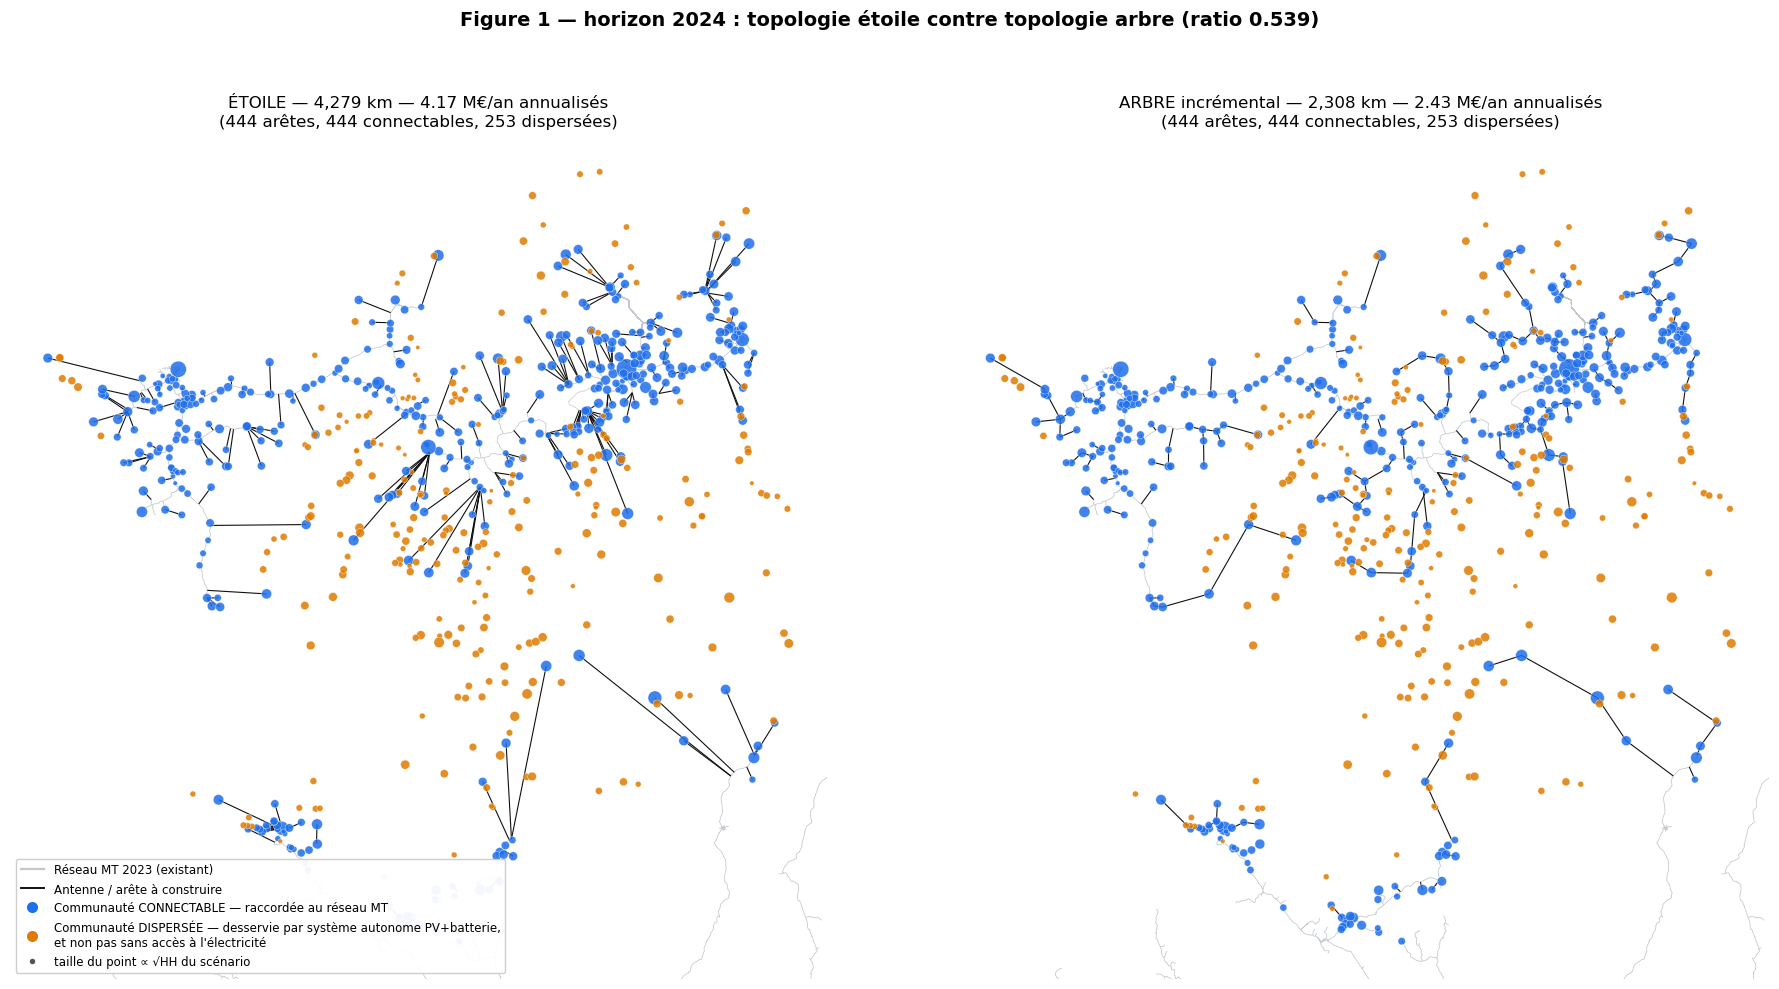

In [112]:
# ── 9.3 Figure 1 — horizon 2024 : étoile vs arbre ────────────────────────────
_y = "2024"
_conn, _hh = conn_by_year[_y], hh_by_year[_y]
_tot = scenario_summaries[_y].set_index("Cluster").loc["TOTAL"]

fig, axes = plt.subplots(1, 2, figsize=(19, 10))

for ax, (titre, segs, km, ann) in zip(axes, [
    ("ÉTOILE", _segments_star(_conn), star_len[_y],
     _tot["extension_capex_star_annualise_EUR"]),
    ("ARBRE incrémental", _segments_tree(trees[_y]), tree_len[_y],
     _tot["extension_capex_annualise_EUR"]),
]):
    _base_map(ax)
    ax.add_collection(LineCollection(segs, colors=C_EDGE, linewidths=0.8, zorder=2))
    _plot_points(ax, _conn, _hh)
    ax.set_title(f"{titre} — {km:,.0f} km — {ann / 1e6:.2f} M€/an annualisés\n"
                 f"({len(segs)} arêtes, {int(_conn.sum())} connectables, "
                 f"{int((~_conn).sum())} dispersées)", fontsize=12)

axes[0].legend(handles=_legend_handles(
    [Line2D([], [], color=C_EDGE, lw=1.4, label="Antenne / arête à construire")]),
    loc="lower left", fontsize=8.5, frameon=True, facecolor="white", framealpha=0.95)

plt.tight_layout()
plt.subplots_adjust(top=0.86)
plt.suptitle(f"Figure 1 — horizon {_y} : topologie étoile contre topologie arbre "
             f"(ratio {tree_len[_y] / star_len[_y]:.3f})",
             fontweight="bold", fontsize=14, y=0.985)
plt.show()

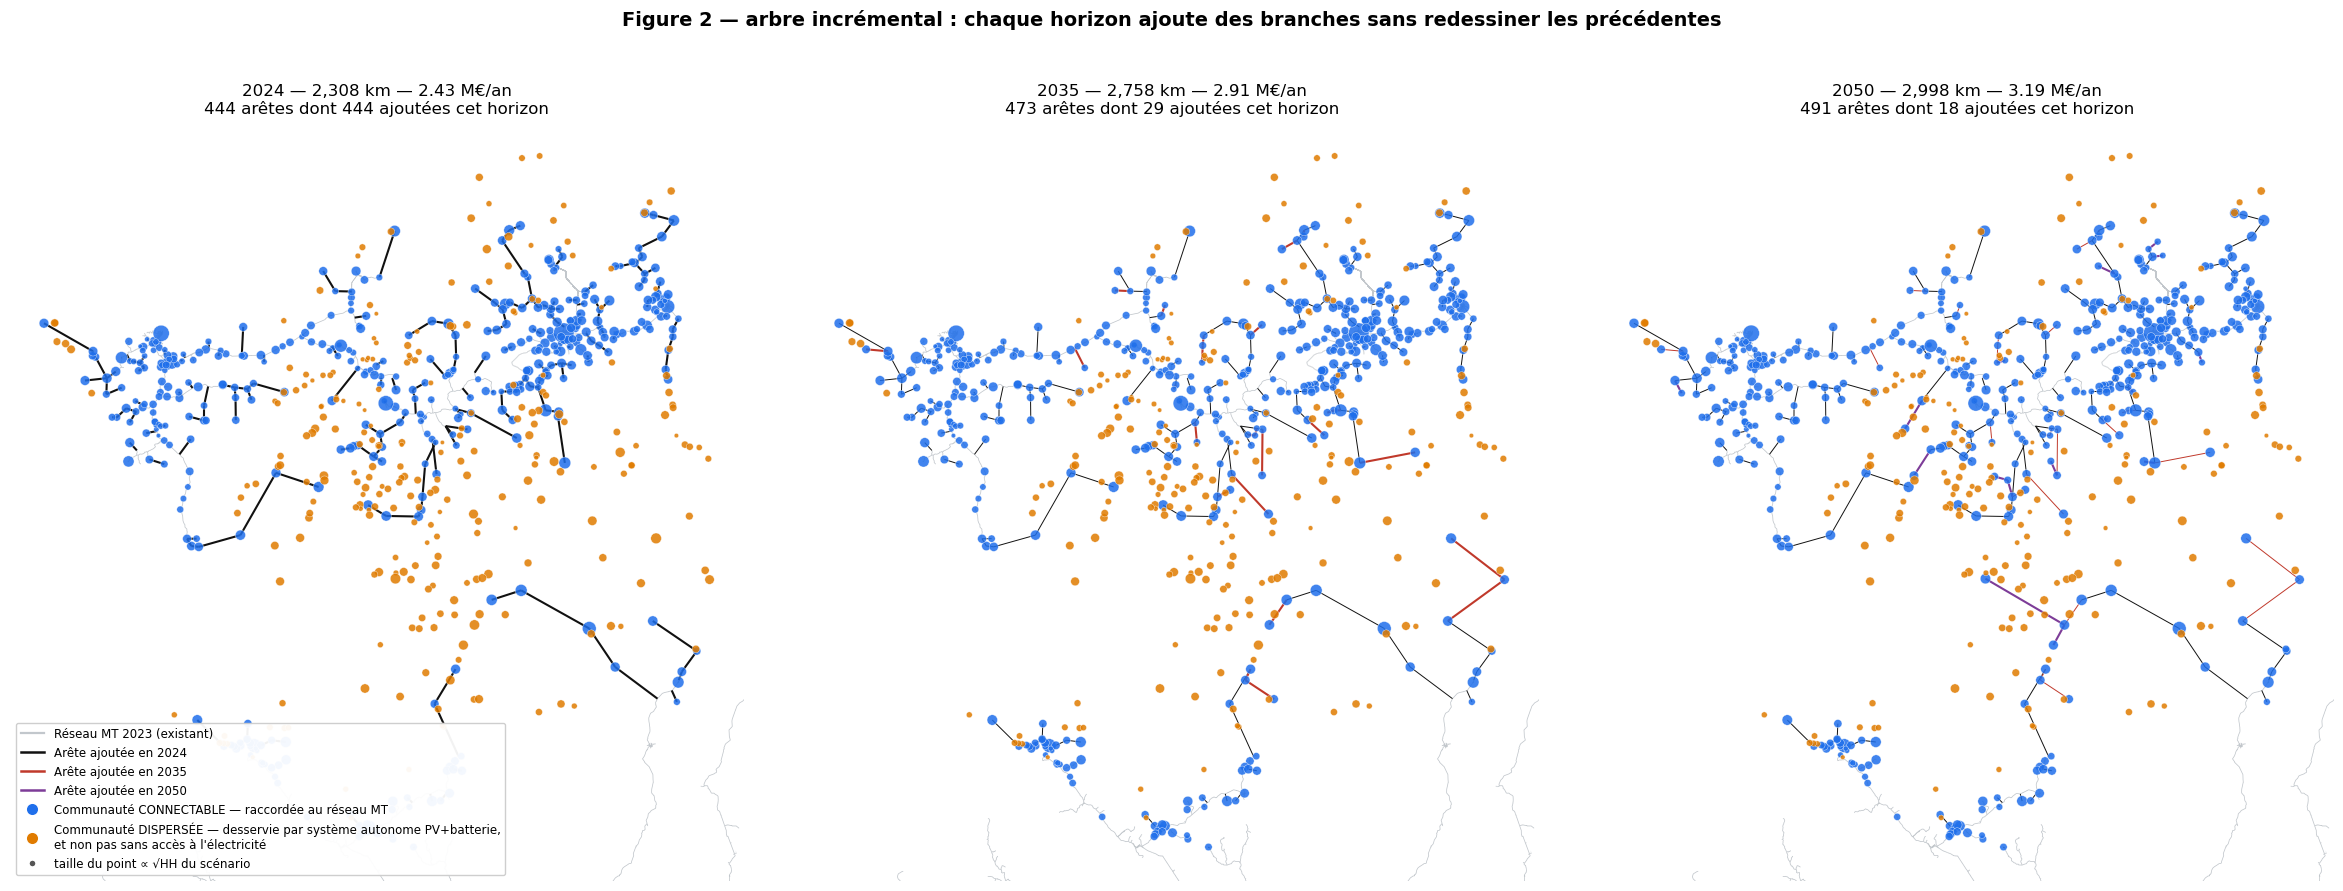

arêtes par horizon d'ajout :
  2024 : 444 arêtes, 2,308.07 km
  2035 :  29 arêtes,   450.03 km
  2050 :  18 arêtes,   240.39 km


In [113]:
# ── 9.4 Figure 2 — les trois horizons, arêtes colorées par horizon d'ajout ───
# L'arbre étant incrémental (extend_tree_prim conserve toutes les arêtes précédentes),
# l'horizon d'ajout d'une arête est le premier horizon dont l'arbre la contient.
edge_year = {}
for _y in EXT_YEARS:
    for e in trees[_y]:
        edge_year.setdefault(e, _y)

fig, axes = plt.subplots(1, 3, figsize=(24, 9))

for ax, _y in zip(axes, EXT_YEARS):
    _base_map(ax)
    for _src in EXT_YEARS[:EXT_YEARS.index(_y) + 1]:
        _sub = [e for e in trees[_y] if edge_year[e] == _src]
        if _sub:
            ax.add_collection(LineCollection(
                _segments_tree(_sub), colors=C_BY_YEAR[_src],
                linewidths=1.5 if _src == _y else 0.7, zorder=2))
    _plot_points(ax, conn_by_year[_y], hh_by_year[_y])
    _tot = scenario_summaries[_y].set_index("Cluster").loc["TOTAL"]
    _added = len([e for e in trees[_y] if edge_year[e] == _y])
    ax.set_title(f"{_y} — {tree_len[_y]:,.0f} km — "
                 f"{_tot['extension_capex_annualise_EUR'] / 1e6:.2f} M€/an\n"
                 f"{len(trees[_y])} arêtes dont {_added} ajoutées cet horizon",
                 fontsize=12)

axes[0].legend(handles=_legend_handles(
    [Line2D([], [], color=C_BY_YEAR[y], lw=1.8, label=f"Arête ajoutée en {y}")
     for y in EXT_YEARS]),
    loc="lower left", fontsize=8.5, frameon=True, facecolor="white", framealpha=0.95)

plt.tight_layout()
plt.subplots_adjust(top=0.86)
plt.suptitle("Figure 2 — arbre incrémental : chaque horizon ajoute des branches "
             "sans redessiner les précédentes",
             fontweight="bold", fontsize=14, y=0.985)
plt.show()

print("arêtes par horizon d'ajout :")
for _y in EXT_YEARS:
    _n = len([e for e in edge_year if edge_year[e] == _y])
    _km = sum(trees[EXT_YEARS[-1]][e] for e in edge_year if edge_year[e] == _y)
    print(f"  {_y} : {_n:>3} arêtes, {_km:>8,.2f} km")

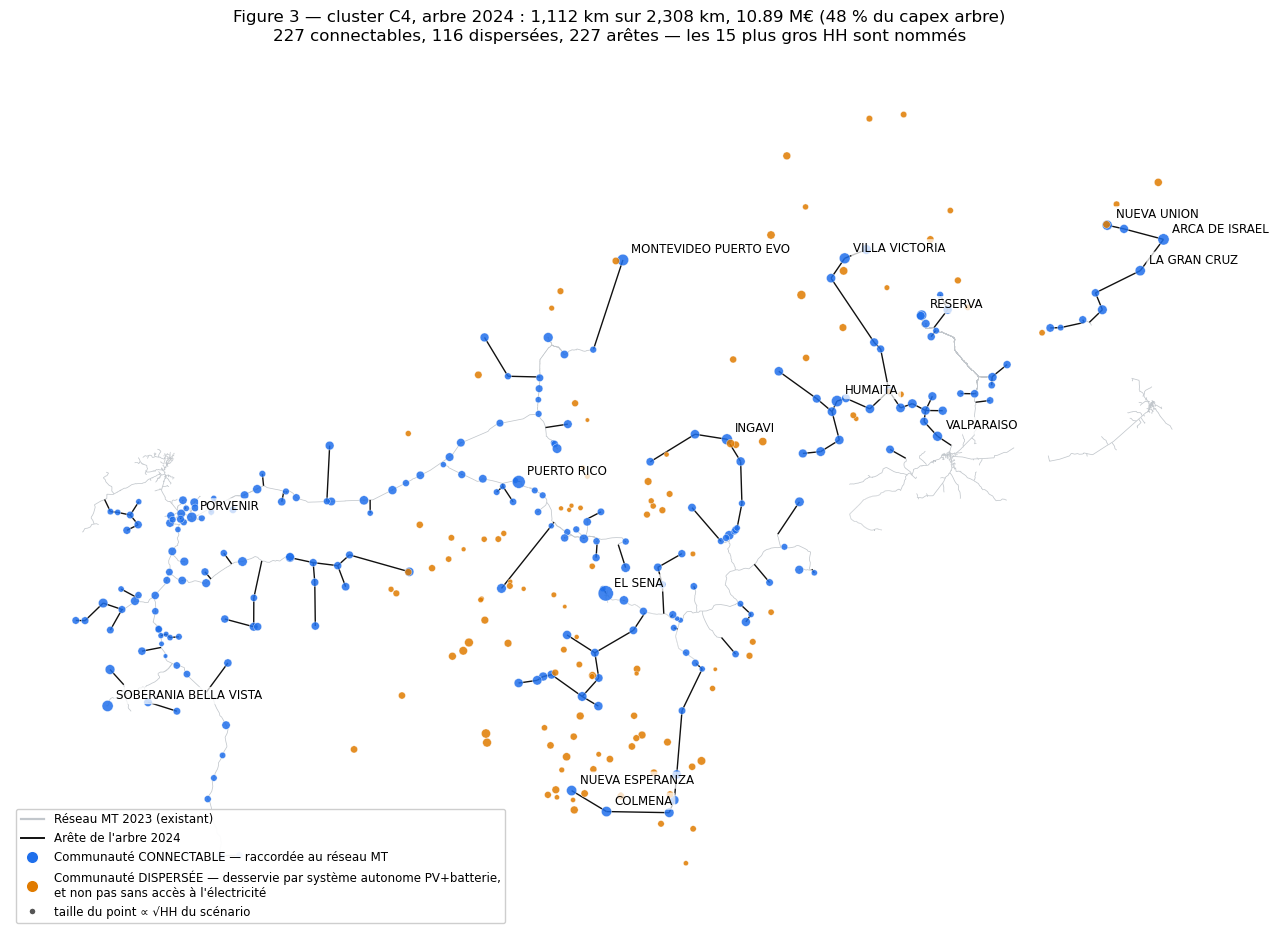

Les 15 plus gros HH de C4 (HH du scénario 2024) :
   1. EL SENA                    Sena                   HH    391.9  d_grid   0.164 km  connectable
   2. PUERTO RICO                Puerto_Rico            HH    189.7  d_grid   0.246 km  connectable
   3. MONTEVIDEO PUERTO EVO      Bella_Flor             HH    116.6  d_grid  35.609 km  connectable
   4. ARCA DE ISRAEL             Nueva_Esperanza        HH    107.4  d_grid  42.287 km  connectable
   5. HUMAITA                    Ingavi                 HH    104.4  d_grid  30.574 km  connectable
   6. SOBERANIA BELLA VISTA      Filadelfia             HH    102.6  d_grid   0.015 km  connectable
   7. INGAVI                     Ingavi                 HH     91.3  d_grid  35.291 km  connectable
   8. VILLA VICTORIA             Santos_Mercado         HH     88.9  d_grid  36.022 km  connectable
   9. NUEVA ESPERANZA            Sena                   HH     70.9  d_grid  67.488 km  connectable
  10. COLMENA                    Sena             

In [114]:
# ── 9.5 Figure 3 — zoom sur C4, arbre 2024, 15 plus gros HH nommés ──────────
# C4 est le cluster le plus étendu et celui qui porte la plus grosse part du capex.
_y = "2024"
_c4 = (CL_ARR == "C4")
_tot = scenario_summaries[_y].set_index("Cluster")
_part_c4 = _tot.loc["C4", "extension_capex_EUR"] / _tot.loc["TOTAL", "extension_capex_EUR"]

# Les arêtes étant strictement intra-cluster, celles de C4 se sélectionnent sans ambiguïté
_edges_c4 = {e: w for e, w in trees[_y].items()
             if all(_c4[n] for n in e if n != ROOT)}

fig, ax = plt.subplots(figsize=(13, 12))
_base_map(ax, sub=_c4)
ax.add_collection(LineCollection(_segments_tree(_edges_c4), colors=C_EDGE,
                                 linewidths=1.0, zorder=2))
_plot_points(ax, conn_by_year[_y], hh_by_year[_y], sub=_c4)

N_LABELS = 15   # nombre de communautés nommées (mise en page, sans effet sur les calculs)
_idx_c4 = np.where(_c4)[0]
_top = _idx_c4[np.argsort(hh_by_year[_y][_idx_c4])[::-1][:N_LABELS]]
for i in _top:
    ax.annotate(f"{task1_geo['Comunidad'].iloc[i]}",
                (XY[i, 0], XY[i, 1]), xytext=(6, 5), textcoords="offset points",
                fontsize=8.5, zorder=4,
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.75))

ax.set_title(f"Figure 3 — cluster C4, arbre {_y} : "
             f"{_tot.loc['C4', 'km_MT_arbre']:,.0f} km sur "
             f"{_tot.loc['TOTAL', 'km_MT_arbre']:,.0f} km, "
             f"{_tot.loc['C4', 'extension_capex_EUR'] / 1e6:.2f} M€ "
             f"({_part_c4 * 100:.0f} % du capex arbre)\n"
             f"{int(conn_by_year[_y][_c4].sum())} connectables, "
             f"{int((~conn_by_year[_y][_c4]).sum())} dispersées, "
             f"{len(_edges_c4)} arêtes — les {N_LABELS} plus gros HH sont nommés",
             fontsize=12)
ax.legend(handles=_legend_handles(
    [Line2D([], [], color=C_EDGE, lw=1.4, label="Arête de l'arbre 2024")]),
    loc="lower left", fontsize=8.5, frameon=True, facecolor="white", framealpha=0.95)
plt.tight_layout()
plt.show()

print(f"Les {N_LABELS} plus gros HH de C4 (HH du scénario {_y}) :")
for _r, i in enumerate(_top, 1):
    print(f"  {_r:>2}. {task1_geo['Comunidad'].iloc[i]:<26} "
          f"{task1_geo['Municipio_std'].iloc[i]:<22} "
          f"HH {hh_by_year[_y][i]:>8.1f}  d_grid {D_GRID[i]:>7.3f} km  "
          f"{'connectable' if conn_by_year[_y][i] else 'DISPERSÉE'}")

In [115]:
# ── 9.6 Contrôles numériques sur les arêtes ─────────────────────────────────
# LONG_EDGE_KM = 40 km : seuil de signalement d'une arête inhabituellement longue.
#   Valeur de contrôle, choisie pour cette relecture ; elle n'intervient dans aucun calcul
#   de capex et n'est comparée à aucune source du dépôt.
LONG_EDGE_KM = 40.0

_muni = task1_geo["Municipio_std"].to_numpy()
_nom = task1_geo["Comunidad"].to_numpy()


def _label(n):
    return "réseau MT (racine)" if n == ROOT else f"{_nom[n]} ({_muni[n]}, {CL_ARR[n]})"


for _y in EXT_YEARS:
    _E = trees[_y]
    _cc = [(e, w) for e, w in _E.items() if ROOT not in e]
    _rt = [(e, w) for e, w in _E.items() if ROOT in e]

    # (1) arêtes de plus de LONG_EDGE_KM
    _long = sorted(((w, e) for e, w in _E.items() if w > LONG_EDGE_KM), reverse=True)

    # (2) arêtes franchissant une frontière municipale (autorisé, on compte)
    _cross = [(e, w) for e, w in _cc if _muni[tuple(e)[0]] != _muni[tuple(e)[1]]]

    # (3) ASSERTION BLOQUANTE — aucune arête inter-cluster
    for e, w in _cc:
        a, b = tuple(e)
        assert CL_ARR[a] == CL_ARR[b], (
            f"{_y} : arête inter-cluster {CL_ARR[a]}/{CL_ARR[b]} entre "
            f"{_label(a)} et {_label(b)}")

    print(f"─── {_y} : {len(_E)} arêtes ({len(_rt)} vers la racine, "
          f"{len(_cc)} communauté-communauté) ───")
    print(f"  (1) arêtes > {LONG_EDGE_KM:.0f} km : {len(_long)}"
          f"  ({sum(w for w, _ in _long):,.2f} km au total)")
    for w, e in _long:
        a, b = tuple(e)
        print(f"        {w:>7.2f} km   {_label(a)}  <->  {_label(b)}")
    print(f"  (2) arêtes communauté-communauté franchissant une frontière municipale : "
          f"{len(_cross)} / {len(_cc)}  ({sum(w for _, w in _cross):,.2f} km)")
    _pairs = {}
    for e, w in _cross:
        a, b = tuple(e)
        k = " | ".join(sorted((_muni[a], _muni[b])))
        _pairs[k] = _pairs.get(k, [0, 0.0])
        _pairs[k][0] += 1
        _pairs[k][1] += w
    for k in sorted(_pairs, key=lambda k: -_pairs[k][1]):
        print(f"        {_pairs[k][0]:>2} arête(s), {_pairs[k][1]:>7.2f} km   {k}")
    print(f"  (3) ASSERTION OK — aucune arête ne relie deux clusters différents")
    print()

─── 2024 : 444 arêtes (281 vers la racine, 163 communauté-communauté) ───
  (1) arêtes > 40 km : 4  (194.10 km au total)
          57.41 km   ESTANCIAS DISPERSAS (Exaltación, C1)  <->  COQUINAL (Exaltación, C1)
          52.78 km   TOROMONAS (Ixiamas, C1)  <->  EL TIGRE (Ixiamas, C1)
          42.31 km   EL CANDADO (Santa_Rosa_Beni, C1)  <->  réseau MT (racine)
          41.59 km   NUEVA CANAAN (Bolpebra, C2)  <->  SAN PEDRO DE BOLPEBRA (Bolpebra, C2)
  (2) arêtes communauté-communauté franchissant une frontière municipale : 28 / 163  (314.89 km)
         6 arête(s),   37.54 km   Puerto_Gonzalo_Moreno | Riberalta
         4 arête(s),   33.85 km   San_Pedro | Villa_Nueva
         2 arête(s),   32.76 km   San_Lorenzo | San_Pedro
         1 arête(s),   30.38 km   Puerto_Rico | Sena
         1 arête(s),   29.37 km   Santos_Mercado | Villa_Nueva
         1 arête(s),   23.64 km   Filadelfia | Puerto_Rico
         1 arête(s),   22.82 km   Exaltación | Santa_Rosa_Beni
         3 arête(s),   21

## 10. Boucle de reclassification arbre-cohérente — DIAGNOSTIC SEUL

**Cette section n'écrit aucun fichier et ne remplace aucune valeur publiée.**

Incohérence mesurée ici. Le classement connectable/dispersée (section 4) évalue le coût
d'extension d'une communauté comme une antenne *indépendante* partant du réseau existant :

    ext_HH = (CRF_MV + OM) × [ MV_EUR × distance_km / HH + CONN_EUR ]

alors que le capex publié (section 7) facture l'*arbre*, où une communauté ne paie que
l'arête qui la relie à son parent — souvent bien plus courte que `distance_km`. Le classement
est donc plus sévère que le coût réellement facturé.

Itération, horizon par horizon, indépendamment :

- **étape 0** — ensemble connectable actuel (`conn_by_year[horizon]`).
- **étape k** — construire l'arbre (`build_tree_mst`, arêtes inter-cluster interdites, racine
  unique) sur l'ensemble courant ; remplacer le coût d'extension de chaque communauté par
  celui de son arête ; réappliquer `classify_communities` **inchangée** ; recommencer jusqu'à
  ce que l'ensemble ne bouge plus, maximum 10 itérations.

Deux points de mise en œuvre, explicités parce qu'ils ne découlent pas mécaniquement de
l'énoncé :

1. **Communautés hors de l'ensemble courant.** Elles n'ont pas d'arête dans l'arbre. Sans coût
   assigné elles ne pourraient jamais être reconsidérées et la boucle ne pourrait que
   rétrécir. On leur affecte donc leur *coût de rattachement candidat* : le minimum entre
   `distance_km` (rattachement direct à la racine) et la distance à la communauté connectable
   la plus proche du **même cluster** — exactement le candidat que Prim évaluerait.
2. **`classify_communities` est appelée sans aucune modification.** Sa formule interne étant
   `MV_EUR × dist / HH + CONN_EUR`, le poste transformateur est injecté par équivalence de
   longueur : `TRAFO_EUR / HH` ≡ `MV_EUR × (TRAFO_EUR / MV_EUR) / HH`, donc on lui passe
   `dist_effective = longueur_arête + TRAFO_EUR / MV_EUR`. L'égalité est exacte, pas une
   approximation.

In [116]:
# ── 10.1 Outils de la boucle ─────────────────────────────────────────────────
# Constantes de cette cellule :
#   MAX_ITER = 10 — plafond d'itérations imposé par l'énoncé du diagnostic.
#   TRAFO_KM_EQ = TRAFO_EUR / MV_EUR — longueur de ligne de coût équivalent au poste de
#       transformation. TRAFO_EUR = 3234.0 EUR (section 7bis.2, Peña Balderrama et al. 2020
#       table A.5 p.113), MV_EUR = 8316.0 EUR/km (section 1, même table) -> 0.388889 km.
#       Sert uniquement à faire passer le poste transformateur par la signature inchangée
#       de classify_communities, qui ne connaît qu'une distance.
MAX_ITER = 10
TRAFO_KM_EQ = TRAFO_EUR / MV_EUR
print(f"TRAFO_KM_EQ = {TRAFO_EUR:,.1f} / {MV_EUR:,.1f} = {TRAFO_KM_EQ:.6f} km "
      f"de ligne équivalente au poste de transformation")


def parent_edge_length(edges):
    """Enracine l'arbre en ROOT et renvoie {noeud: longueur de son arête parente}.
    Chaque nœud d'un arbre couvrant enraciné a exactement une arête parente."""
    adj = {}
    for e, w in edges.items():
        a, b = tuple(e)
        adj.setdefault(a, []).append((b, w))
        adj.setdefault(b, []).append((a, w))
    par, seen, stack = {}, {ROOT}, [ROOT]
    while stack:
        u = stack.pop()
        for v, w in adj.get(u, []):
            if v not in seen:
                seen.add(v)
                par[v] = w
                stack.append(v)
    assert len(seen) == len(edges) + 1, "l'arbre n'est pas couvrant / n'est pas un arbre"
    return par


def attach_lengths(mask_in, edges):
    """Longueur d'arête retenue pour CHAQUE communauté.
      - dans l'ensemble courant : longueur de son arête parente dans l'arbre ;
      - hors de l'ensemble      : coût de rattachement candidat = min(distance_km,
        distance à la connectable la plus proche du même cluster).
    """
    L = D_GRID.astype(float).copy()
    par = parent_edge_length(edges)
    for n, w in par.items():
        L[n] = w
    out = np.where(~mask_in)[0]
    for c in np.unique(CL_ARR):
        ins = np.where(mask_in & (CL_ARR == c))[0]
        o_c = out[CL_ARR[out] == c]
        if len(ins) and len(o_c):
            L[o_c] = np.minimum(L[o_c], D_COMM[np.ix_(o_c, ins)].min(axis=1))
    return L


def reclassify_from_tree(mask_in, hh):
    """Une itération : arbre sur mask_in -> coûts d'arête -> classify_communities inchangée.
    Renvoie (nouveau masque connectable, arbre construit, longueurs d'arête)."""
    idx = np.where(mask_in)[0]
    edges = build_tree_mst(idx, D_COMM, D_GRID, CL_ARR)

    # ASSERTIONS : aucune arête inter-cluster (edges_length_by_cluster asserte en interne),
    # et arbre <= étoile sur l'ensemble courant.
    _len_cl = edges_length_by_cluster(edges)
    _tree_km = float(sum(edges.values()))
    assert abs(sum(_len_cl.values()) - _tree_km) < 1e-6
    assert _tree_km <= D_GRID[mask_in].sum() + 1e-9, "arbre plus long que l'étoile"

    L = attach_lengths(mask_in, edges)

    scn = task1_geo.copy()
    scn["HH_2024_scaled"] = hh
    scn["distance_km"] = L + TRAFO_KM_EQ      # équivalence exacte, voir markdown 10
    res = classify_communities(scn, shs_annual, MV_EUR, CONN_EUR, CRF_MV)
    assert len(res) == len(scn), "classify_communities a écarté des lignes HH<=0"
    return (~res["dispersed"].to_numpy()), edges, L


print("outils prêts (parent_edge_length, attach_lengths, reclassify_from_tree)")

TRAFO_KM_EQ = 3,234.0 / 8,316.0 = 0.388889 km de ligne équivalente au poste de transformation
outils prêts (parent_edge_length, attach_lengths, reclassify_from_tree)


In [117]:
# ── 10.2 Boucle, horizon par horizon ─────────────────────────────────────────
loop_hist, loop_final, loop_status = {}, {}, {}

for _y in EXT_YEARS:
    _hh = hh_by_year[_y]
    _hh_total_0 = float(_hh.sum())
    _S = conn_by_year[_y].copy()
    _seen = [_S.copy()]
    _rows, _status, _final_edges = [], None, None

    for _k in range(1, MAX_ITER + 1):
        _S_new, _edges, _L = reclassify_from_tree(_S, _hh)

        # ASSERTION : le total de ménages ne bouge pas d'une itération à l'autre
        assert abs(float(_hh.sum()) - _hh_total_0) < 1e-6, \
            f"{_y} itération {_k} : total ménages modifié"

        _n_in = int(_S.sum())
        _km = float(sum(_edges.values()))
        _cap = capex_posts(_km, _n_in, float(_hh[_S].sum()))
        _rows.append({
            "iteration": _k,
            "N_conn_entree": _n_in,
            "km_arbre": round(_km, 2),
            "km_etoile": round(float(D_GRID[_S].sum()), 2),
            "capex_EUR": round(_cap["total_EUR"], 0),
            "capex_annualise_EUR": round(_cap["total_annualise_EUR"], 0),
            "N_conn_sortie": int(_S_new.sum()),
            "delta_N": int(_S_new.sum()) - _n_in,
            "bascules": int((_S != _S_new).sum()),
        })

        if (_S_new == _S).all():
            _status = f"convergence à l'itération {_k}"
            _final_edges = _edges
            break

        _cycle = next((len(_seen) - j for j, _prev in enumerate(_seen)
                       if (_prev == _S_new).all()), None)
        if _cycle is not None:
            _status = (f"OSCILLATION détectée à l'itération {_k} : l'ensemble obtenu est "
                       f"identique à celui de {_cycle} itération(s) plus tôt "
                       f"(cycle de période {_cycle}) — boucle arrêtée sans convergence")
            _S = _S_new
            _final_edges = build_tree_mst(np.where(_S)[0], D_COMM, D_GRID, CL_ARR)
            break

        _seen.append(_S_new.copy())
        _S = _S_new
    else:
        _status = (f"NON CONVERGÉE après {MAX_ITER} itérations et sans cycle détecté — "
                   "état retenu = dernier ensemble obtenu")
        _final_edges = build_tree_mst(np.where(_S)[0], D_COMM, D_GRID, CL_ARR)

    loop_hist[_y] = pd.DataFrame(_rows)
    loop_final[_y] = {"mask": _S, "edges": _final_edges,
                      "km": float(sum(_final_edges.values()))}
    loop_status[_y] = _status

    print(f"═══ horizon {_y} — {_status} ═══")
    print(loop_hist[_y].to_string(index=False))
    print()

═══ horizon 2024 — OSCILLATION détectée à l'itération 8 : l'ensemble obtenu est identique à celui de 4 itération(s) plus tôt (cycle de période 4) — boucle arrêtée sans convergence ═══
 iteration  N_conn_entree  km_arbre  km_etoile  capex_EUR  capex_annualise_EUR  N_conn_sortie  delta_N  bascules
         1            444   2308.07    4279.43 22920277.0            2431366.0            564      120       124
         2            564   3232.80    9922.13 31353752.0            3325982.0            594       30        42
         3            594   3493.18   11919.83 33697776.0            3574635.0            602        8        24
         4            602   3556.23   12620.12 34261844.0            3634471.0            607        5        19
         5            607   3581.04   12883.09 34493543.0            3659049.0            602       -5        19
         6            602   3553.85   12763.30 34244531.0            3632634.0            605        3        17
         7            605

In [118]:
# ── 10.3 Ensemble final : bascules par cluster ───────────────────────────────
for _y in EXT_YEARS:
    _old, _new = conn_by_year[_y], loop_final[_y]["mask"]
    _rows = []
    for _c in CLUSTERS:
        _m = (CL_ARR == _c)
        _to_conn = int((_m & ~_old & _new).sum())     # dispersée -> connectable
        _to_disp = int((_m & _old & ~_new).sum())     # connectable -> dispersée
        _rows.append({
            "Cluster": _c,
            "N_conn_actuel": int((_m & _old).sum()),
            "vers_connectable": _to_conn,
            "vers_dispersee": _to_disp,
            "N_conn_final": int((_m & _new).sum()),
            "delta": int((_m & _new).sum()) - int((_m & _old).sum()),
        })
    _df = pd.DataFrame(_rows)
    _tot = {c: _df[c].sum() for c in _df.columns if c != "Cluster"}
    _tot["Cluster"] = "TOTAL"
    _df = pd.concat([_df, pd.DataFrame([_tot])], ignore_index=True)
    print(f"─── {_y} ───")
    print(_df.to_string(index=False))
    print()

# Emboîtement des ensembles finaux entre horizons (constat, pas assertion : la boucle est
# menée indépendamment par horizon, rien ne le garantit a priori)
print("─── emboîtement des ensembles connectables entre horizons ───")
for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
    _fa, _fb = loop_final[_a]["mask"], loop_final[_b]["mask"]
    _perdues = int((_fa & ~_fb).sum())
    _oa, _ob = conn_by_year[_a], conn_by_year[_b]
    print(f"  publié  {_a} inclus dans {_b} : {bool(not (_oa & ~_ob).any())}"
          f"   (perdues : {int((_oa & ~_ob).sum())})")
    print(f"  boucle  {_a} inclus dans {_b} : {bool(_perdues == 0)}"
          f"   (perdues : {_perdues})")
    if _perdues:
        _idx = np.where(_fa & ~_fb)[0]
        for i in _idx:
            print(f"      {task1_geo['Comunidad'].iloc[i]} "
                  f"({task1_geo['Municipio_std'].iloc[i]}, {CL_ARR[i]}) "
                  f"HH {_a} {hh_by_year[_a][i]:.1f} -> {_b} {hh_by_year[_b][i]:.1f}")

─── 2024 ───
Cluster  N_conn_actuel  vers_connectable  vers_dispersee  N_conn_final  delta
     C1             76                59               0           135     59
     C2             10                 5               0            15      5
     C3            117                30               0           147     30
     C4            227                69               0           296     69
     C5             14                 0               0            14      0
  TOTAL            444               163               0           607    163

─── 2035 ───
Cluster  N_conn_actuel  vers_connectable  vers_dispersee  N_conn_final  delta
     C1             82                60               0           142     60
     C2             11                 5               0            16      5
     C3            125                24               1           148     23
     C4            241                64               0           305     64
     C5             14               

In [119]:
# ── 10.4 Capex final vs valeurs publiées ─────────────────────────────────────
# Valeurs publiées : output/<annee>/cluster_summary.csv, ligne TOTAL, colonnes
# extension_capex_EUR et extension_capex_annualise_EUR (écrites en section 7).
_rows = []
for _y in EXT_YEARS:
    _pub = scenario_summaries[_y].set_index("Cluster").loc["TOTAL"]
    _m = loop_final[_y]["mask"]
    _km = loop_final[_y]["km"]
    _cap = capex_posts(_km, int(_m.sum()), float(hh_by_year[_y][_m].sum()))

    # ASSERTIONS sur l'état final
    assert _km <= D_GRID[_m].sum() + 1e-9, f"{_y} : arbre final plus long que l'étoile"
    _lc = edges_length_by_cluster(loop_final[_y]["edges"])   # asserte l'absence d'inter-cluster
    assert abs(sum(_lc.values()) - _km) < 1e-6

    _rows.append({
        "annee": _y,
        "N_conn_publie": int(_pub["N_connectable"]),
        "N_conn_boucle": int(_m.sum()),
        "km_arbre_publie": _pub["km_MT_arbre"],
        "km_arbre_boucle": round(_km, 2),
        "capex_publie_EUR": _pub["extension_capex_EUR"],
        "capex_boucle_EUR": round(_cap["total_EUR"], 0),
        "ecart_EUR": round(_cap["total_EUR"] - _pub["extension_capex_EUR"], 0),
        "ecart_%": round(100 * (_cap["total_EUR"] / _pub["extension_capex_EUR"] - 1), 2),
        "capex_ann_publie_EUR": _pub["extension_capex_annualise_EUR"],
        "capex_ann_boucle_EUR": round(_cap["total_annualise_EUR"], 0),
    })

loop_capex = pd.DataFrame(_rows)
print("capex final de la boucle vs capex publié (section 7)")
print(loop_capex.to_string(index=False))

print()
print("─── décomposition en trois postes de l'état final ───")
_rows = []
for _y in EXT_YEARS:
    _m = loop_final[_y]["mask"]
    _p = capex_posts(loop_final[_y]["km"], int(_m.sum()), float(hh_by_year[_y][_m].sum()))
    _rows.append({"annee": _y, "ligne_EUR": round(_p["ligne_EUR"], 0),
                  "transformateur_EUR": round(_p["transformateur_EUR"], 0),
                  "raccordement_EUR": round(_p["raccordement_EUR"], 0),
                  "total_EUR": round(_p["total_EUR"], 0)})
print(pd.DataFrame(_rows).to_string(index=False))

capex final de la boucle vs capex publié (section 7)
annee  N_conn_publie  N_conn_boucle  km_arbre_publie  km_arbre_boucle  capex_publie_EUR  capex_boucle_EUR  ecart_EUR  ecart_%  capex_ann_publie_EUR  capex_ann_boucle_EUR
 2024            444            607          2308.06          3581.04        22920277.0        34493543.0 11573266.0    50.49             2431367.0             3659049.0
 2035            473            625          2758.10          3725.59        27392362.0        36377366.0  8985004.0    32.80             2905761.0             3858884.0
 2050            491            631          2998.48          3770.36        30089070.0        37402132.0  7313062.0    24.30             3191827.0             3967590.0

─── décomposition en trois postes de l'état final ───
annee  ligne_EUR  transformateur_EUR  raccordement_EUR  total_EUR
 2024 29779897.0           1963038.0         2750608.0 34493543.0
 2035 30981993.0           2021250.0         3374123.0 36377366.0
 2050 31354332

In [120]:
# ── 10.5 share_dispersion résultant ──────────────────────────────────────────
# Dénominateur = menages_cluster de output/<annee>/cluster_summary.csv (section 7), même
# convention qu'à la section 6 (fraction de TOUS les ménages A+B+C du cluster).
# Référence 2024 publiée : output/share_dispersion_final_BC.csv, colonne share_dispersion.
_ref = pd.read_csv("output/share_dispersion_final_BC.csv").set_index("Cluster")["share_dispersion"]

for _y in EXT_YEARS:
    _pub = scenario_summaries[_y].set_index("Cluster")
    _old, _new = conn_by_year[_y], loop_final[_y]["mask"]
    _hh = hh_by_year[_y]
    _rows = []
    for _c in CLUSTERS:
        _m = (CL_ARR == _c)
        _den = float(_pub.loc[_c, "menages_cluster"])
        _sd_old = float(_hh[_m & ~_old].sum()) / _den
        _sd_new = float(_hh[_m & ~_new].sum()) / _den
        _rows.append({
            "Cluster": _c,
            "menages_cluster": _den,
            "share_disp_actuel": round(_sd_old, 4),
            "ref_CSV_2024": _ref[_c] if _y == "2024" else None,
            "share_disp_boucle": round(_sd_new, 4),
            "delta_points": round(100 * (_sd_new - _sd_old), 2),
        })
    print(f"─── {_y} ───")
    print(pd.DataFrame(_rows).to_string(index=False))
    print()

print("RAPPEL — cette section n'écrit aucun fichier : les CSV de output/ restent ceux de "
      "la section 7 (classement inchangé, capex arbre).")

─── 2024 ───
Cluster  menages_cluster  share_disp_actuel  ref_CSV_2024  share_disp_boucle  delta_points
     C1          10933.0             0.1660        0.0213             0.0231        -14.28
     C2            802.0             0.1487        0.0000             0.0121        -13.67
     C3          40298.0             0.0179        0.0026             0.0027         -1.52
     C4          16612.0             0.0774        0.0128             0.0150         -6.24
     C5          15564.0             0.0000        0.0000             0.0000          0.00

─── 2035 ───
Cluster  menages_cluster  share_disp_actuel ref_CSV_2024  share_disp_boucle  delta_points
     C1          12942.0             0.1350         None             0.0157        -11.93
     C2            998.0             0.1117         None             0.0000        -11.17
     C3          47958.0             0.0126         None             0.0024         -1.02
     C4          20801.0             0.0623         None           

## 11. Classification par extension gloutonne (méthode OnSSET) — DIAGNOSTIC SEUL

**Cette section n'écrit aucun fichier et ne remplace aucune valeur publiée.**

La boucle de la section 10 oscille parce qu'elle réévalue à chaque tour les communautés déjà
acceptées : une communauté devenue nœud de passage voit son arête parente changer, ce qui peut
la faire ressortir de l'ensemble. Ici l'ensemble raccordé **ne fait que croître**, donc la
terminaison est garantie : au plus une communauté est ajoutée par itération, jamais retirée.

Algorithme, par horizon, indépendamment :

```
T = arbre courant, initialisé au réseau MT existant (racine seule)
R = ensemble raccordé, vide
répéter :
    pour chaque communauté c hors de R :
        cout_attache(c) = min( distance_km(c),
                               min sur r ∈ R du MÊME cluster de dist(c, r) )
        ext_HH(c) = MV_EUR × cout_attache(c) / HH(c) + CONN_EUR + TRAFO_EUR / HH(c)
    c* = argmin ext_HH sur les communautés hors de R
    si le test de classify_communities accepte c* :
        R ← R ∪ {c*} ; T ← T ∪ {arête de c*}
    sinon :
        arrêter — toutes les restantes sont dispersées
```

Arêtes inter-cluster interdites, comme partout ailleurs.

**Test d'acceptation.** L'énoncé le formule comme `ext_HH ≤ annual_standalone / CRF_MV`. Cette
forme diffère de `classify_communities` par le terme `OM_RATE` : la fonction compare
`standalone < (CRF_MV + OM_RATE) × [MV_EUR × dist / HH + CONN_EUR]` (cellule « 4. Breakeven »
lignes 14-15 et 22). Conformément à la consigne « reprends sa formule telle quelle », c'est
`classify_communities` qui décide, appelée **sans aucune modification** sur la seule ligne du
candidat, avec la distance effective `cout_attache + TRAFO_EUR / MV_EUR`. L'identité
`MV_EUR × (TRAFO_EUR / MV_EUR) / HH ≡ TRAFO_EUR / HH` est exacte.

Comme `ext_HH = MV_EUR × dist_eff / HH + CONN_EUR` et que le coût annualisé de
`classify_communities` vaut `(CRF_MV + OM_RATE) × ext_HH`, le classement par `ext_HH` croissant
et le classement par coût annualisé croissant sont identiques : le choix de `c*` ne dépend pas
de la convention d'annualisation.

**Portée de la règle d'arrêt.** L'arrêt porte sur le candidat de plus petit `ext_HH`. Le coût
autonome `annual_standalone_EUR_HH` variant d'une municipalité à l'autre, un rejet de `c*`
n'implique pas formellement que toutes les restantes échoueraient au test. Le nombre de
communautés restantes qui passeraient individuellement le test au moment de l'arrêt est reporté
ci-dessous, sans modifier l'algorithme.

In [121]:
# ── 11.1 Extension gloutonne ─────────────────────────────────────────────────
# Constantes : aucune nouvelle. Réutilise MV_EUR, CONN_EUR, TRAFO_EUR, CRF_MV (section 1 et
# section 7bis.2, Peña Balderrama et al. 2020 table A.5 p.113) et TRAFO_KM_EQ (section 10.1).

def greedy_connect(hh):
    """Extension gloutonne. Renvoie (R, arêtes, n_iterations, journal, n_restantes_ok).

    `attach_cost[c]` est maintenu incrémentalement : au départ distance_km(c) (rattachement
    direct à la racine), puis abaissé chaque fois qu'une communauté du même cluster entre
    dans R et se trouve plus proche. C'est exactement le min de l'énoncé, sans le recalculer
    de zéro à chaque tour.
    """
    n = len(hh)
    R = np.zeros(n, dtype=bool)
    edges = {}
    attach_cost = D_GRID.astype(float).copy()
    attach_parent = np.full(n, ROOT, dtype=int)
    journal, n_iter = [], 0

    while True:
        n_iter += 1
        out = np.where(~R)[0]
        if len(out) == 0:
            stop = "toutes les communautés sont raccordées"
            n_restantes_ok = 0
            break

        # ext_HH tel que défini par l'énoncé ; identique, à (CRF_MV + OM_RATE) près, au coût
        # annualisé de classify_communities -> même argmin.
        ext = MV_EUR * attach_cost[out] / hh[out] + CONN_EUR + TRAFO_EUR / hh[out]
        c = int(out[np.argmin(ext)])

        # DÉCISION : classify_communities, inchangée, sur la seule ligne du candidat
        row = task1_geo.iloc[[c]].copy()
        row["HH_2024_scaled"] = hh[c]
        row["distance_km"] = attach_cost[c] + TRAFO_KM_EQ
        verdict = classify_communities(row, shs_annual, MV_EUR, CONN_EUR, CRF_MV)
        assert len(verdict) == 1, "classify_communities a écarté le candidat (HH <= 0)"

        if bool(verdict["dispersed"].iloc[0]):
            # Portée de la règle d'arrêt : combien des restantes passeraient le test ?
            rest = task1_geo.iloc[out].copy()
            rest["HH_2024_scaled"] = hh[out]
            rest["distance_km"] = attach_cost[out] + TRAFO_KM_EQ
            n_restantes_ok = int((~classify_communities(
                rest, shs_annual, MV_EUR, CONN_EUR, CRF_MV)["dispersed"]).sum())
            stop = (f"rejet du candidat de plus petit ext_HH à l'itération {n_iter} — "
                    f"{len(out)} communautés restantes déclarées dispersées")
            break

        n_before = int(R.sum())
        R[c] = True
        edges[frozenset((c, int(attach_parent[c])))] = float(attach_cost[c])
        # ASSERTION : R croît strictement, d'exactement une communauté
        assert int(R.sum()) == n_before + 1, "R n'a pas crû d'exactement une communauté"
        assert len(edges) == int(R.sum()), "une arête par communauté raccordée"

        journal.append({
            "rang": int(R.sum()),
            "Comunidad": task1_geo["Comunidad"].iloc[c],
            "Municipio_std": task1_geo["Municipio_std"].iloc[c],
            "Cluster": CL_ARR[c],
            "HH": round(float(hh[c]), 2),
            "cout_attache_km": round(float(attach_cost[c]), 3),
            "distance_km": round(float(D_GRID[c]), 3),
            "parent": ("racine (réseau MT)" if attach_parent[c] == ROOT
                       else task1_geo["Comunidad"].iloc[int(attach_parent[c])]),
            "ext_HH_EUR": round(float(ext[np.argmin(ext)]), 2),
            "standalone_EUR_an": float(verdict["annual_standalone_EUR_HH"].iloc[0]),
        })

        # Mise à jour des coûts d'attache : seules les communautés du même cluster
        # peuvent se rattacher à c (arêtes inter-cluster interdites).
        cand = np.where((~R) & (CL_ARR == CL_ARR[c]))[0]
        if len(cand):
            better = D_COMM[cand, c] < attach_cost[cand]
            attach_cost[cand[better]] = D_COMM[cand[better], c]
            attach_parent[cand[better]] = c

    return R, edges, n_iter, pd.DataFrame(journal), stop, n_restantes_ok


greedy_R, greedy_edges, greedy_iter, greedy_log, greedy_stop = {}, {}, {}, {}, {}
greedy_rest_ok = {}

for _y in EXT_YEARS:
    _R, _E, _it, _log, _stop, _rest = greedy_connect(hh_by_year[_y])

    # ── ASSERTIONS ───────────────────────────────────────────────────────────
    _km = float(sum(_E.values()))
    assert len(_E) == int(_R.sum()), f"{_y} : arbre non couvrant de R"
    _par = parent_edge_length(_E)            # échoue si l'arbre n'est pas connexe/couvrant
    assert set(_par) == set(np.where(_R)[0]), f"{_y} : l'arbre ne couvre pas exactement R"
    _lc = edges_length_by_cluster(_E)        # asserte l'absence d'arête inter-cluster
    assert abs(sum(_lc.values()) - _km) < 1e-6
    assert _km <= D_GRID[_R].sum() + 1e-9, f"{_y} : arbre plus long que l'étoile"

    greedy_R[_y], greedy_edges[_y], greedy_iter[_y] = _R, _E, _it
    greedy_log[_y], greedy_stop[_y], greedy_rest_ok[_y] = _log, _stop, _rest

    print(f"═══ {_y} ═══")
    print(f"  itérations                : {_it}  ({int(_R.sum())} acceptations, "
          f"1 rejet terminal)")
    print(f"  arrêt                     : {_stop}")
    print(f"  restantes qui passeraient le test à l'arrêt : {_rest}")
    print(f"  R n'a jamais rétréci      : True (assertion R.sum() == n_before + 1 "
          f"à chaque acceptation)")
    print(f"  N_connectable             : {int(_R.sum())}  (publié "
          f"{int(scenario_summaries[_y].set_index('Cluster').loc['TOTAL', 'N_connectable'])})")
    print(f"  km arbre                  : {_km:,.2f}  "
          f"(étoile sur R : {D_GRID[_R].sum():,.2f})")
    print()

═══ 2024 ═══
  itérations                : 611  (610 acceptations, 1 rejet terminal)
  arrêt                     : rejet du candidat de plus petit ext_HH à l'itération 611 — 87 communautés restantes déclarées dispersées
  restantes qui passeraient le test à l'arrêt : 2
  R n'a jamais rétréci      : True (assertion R.sum() == n_before + 1 à chaque acceptation)
  N_connectable             : 610  (publié 444)
  km arbre                  : 4,089.60  (étoile sur R : 13,175.10)

═══ 2035 ═══
  itérations                : 631  (630 acceptations, 1 rejet terminal)
  arrêt                     : rejet du candidat de plus petit ext_HH à l'itération 631 — 67 communautés restantes déclarées dispersées
  restantes qui passeraient le test à l'arrêt : 2
  R n'a jamais rétréci      : True (assertion R.sum() == n_before + 1 à chaque acceptation)
  N_connectable             : 630  (publié 473)
  km arbre                  : 4,291.57  (étoile sur R : 14,058.44)

═══ 2050 ═══
  itérations                : 6

In [122]:
# ── 11.2 Bascules par cluster et emboîtement ─────────────────────────────────
for _y in EXT_YEARS:
    _old, _new = conn_by_year[_y], greedy_R[_y]
    _rows = []
    for _c in CLUSTERS:
        _m = (CL_ARR == _c)
        _rows.append({
            "Cluster": _c,
            "N_conn_publie": int((_m & _old).sum()),
            "vers_connectable": int((_m & ~_old & _new).sum()),
            "vers_dispersee": int((_m & _old & ~_new).sum()),
            "N_conn_glouton": int((_m & _new).sum()),
            "delta": int((_m & _new).sum()) - int((_m & _old).sum()),
        })
    _df = pd.DataFrame(_rows)
    _tot = {c: _df[c].sum() for c in _df.columns if c != "Cluster"}
    _tot["Cluster"] = "TOTAL"
    print(f"─── {_y} ───")
    print(pd.concat([_df, pd.DataFrame([_tot])], ignore_index=True).to_string(index=False))
    print()

print("─── emboîtement des ensembles connectables entre horizons ───")
for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
    _oa, _ob = conn_by_year[_a], conn_by_year[_b]
    _ga, _gb = greedy_R[_a], greedy_R[_b]
    print(f"  publié   {_a} ⊂ {_b} : {bool(not (_oa & ~_ob).any())}"
          f"   (perdues : {int((_oa & ~_ob).sum())})")
    print(f"  glouton  {_a} ⊂ {_b} : {bool(not (_ga & ~_gb).any())}"
          f"   (perdues : {int((_ga & ~_gb).sum())})")
    for i in np.where(_ga & ~_gb)[0]:
        print(f"       {task1_geo['Comunidad'].iloc[i]} "
              f"({task1_geo['Municipio_std'].iloc[i]}, {CL_ARR[i]}) "
              f"HH {_a} {hh_by_year[_a][i]:.1f} -> {_b} {hh_by_year[_b][i]:.1f}")

─── 2024 ───
Cluster  N_conn_publie  vers_connectable  vers_dispersee  N_conn_glouton  delta
     C1             76                61               0             137     61
     C2             10                 6               0              16      6
     C3            117                31               0             148     31
     C4            227                68               0             295     68
     C5             14                 0               0              14      0
  TOTAL            444               166               0             610    166

─── 2035 ───
Cluster  N_conn_publie  vers_connectable  vers_dispersee  N_conn_glouton  delta
     C1             82                62               0             144     62
     C2             11                 5               0              16      5
     C3            125                26               1             150     25
     C4            241                65               0             306     65
     C5      

In [123]:
# ── 11.3 Capex et share_dispersion ───────────────────────────────────────────
# Références publiées : output/<annee>/cluster_summary.csv, ligne TOTAL (section 7).
_rows = []
for _y in EXT_YEARS:
    _pub = scenario_summaries[_y].set_index("Cluster").loc["TOTAL"]
    _R = greedy_R[_y]
    _km = float(sum(greedy_edges[_y].values()))
    _cap = capex_posts(_km, int(_R.sum()), float(hh_by_year[_y][_R].sum()))
    _rows.append({
        "annee": _y,
        "N_conn_publie": int(_pub["N_connectable"]),
        "N_conn_glouton": int(_R.sum()),
        "km_publie": _pub["km_MT_arbre"],
        "km_glouton": round(_km, 2),
        "capex_publie_EUR": _pub["extension_capex_EUR"],
        "capex_glouton_EUR": round(_cap["total_EUR"], 0),
        "ecart_%": round(100 * (_cap["total_EUR"] / _pub["extension_capex_EUR"] - 1), 2),
        "ann_publie_EUR": _pub["extension_capex_annualise_EUR"],
        "ann_glouton_EUR": round(_cap["total_annualise_EUR"], 0),
        "ligne_EUR": round(_cap["ligne_EUR"], 0),
        "transfo_EUR": round(_cap["transformateur_EUR"], 0),
        "raccord_EUR": round(_cap["raccordement_EUR"], 0),
    })

greedy_capex = pd.DataFrame(_rows)
print("capex glouton vs capex publié (section 7)")
print(greedy_capex.to_string(index=False))
print()

# Reference verrouillee : le share_dispersion qui a alimente les runs EnergyScope verrouilles.
# Depuis la section 16, output/share_dispersion_final_BC.csv publie les valeurs gloutonnes et
# conserve les valeurs verrouillees sous share_dispersion_runs_verrouilles — la colonne lue ici
# bascule en consequence, pour que la comparaison reste la meme apres republication.
_sd_csv = pd.read_csv("output/share_dispersion_final_BC.csv").set_index("Cluster")
_ref = (_sd_csv["share_dispersion_runs_verrouilles"]
        if "share_dispersion_runs_verrouilles" in _sd_csv.columns
        else _sd_csv["share_dispersion"])
for _y in EXT_YEARS:
    _pub = scenario_summaries[_y].set_index("Cluster")
    _old, _new, _hh = conn_by_year[_y], greedy_R[_y], hh_by_year[_y]
    _rows = []
    for _c in CLUSTERS:
        _m = (CL_ARR == _c)
        _den = float(_pub.loc[_c, "menages_cluster"])
        _sd_o = float(_hh[_m & ~_old].sum()) / _den
        _sd_n = float(_hh[_m & ~_new].sum()) / _den
        _rows.append({"Cluster": _c, "menages_cluster": _den,
                      "share_disp_publie": round(_sd_o, 4),
                      "ref_runs_verrouilles": _ref[_c] if _y == "2024" else None,
                      "share_disp_glouton": round(_sd_n, 4),
                      "delta_points": round(100 * (_sd_n - _sd_o), 2)})
    print(f"─── share_dispersion {_y} ───")
    print(pd.DataFrame(_rows).to_string(index=False))
    print()

capex glouton vs capex publié (section 7)
annee  N_conn_publie  N_conn_glouton  km_publie  km_glouton  capex_publie_EUR  capex_glouton_EUR  ecart_%  ann_publie_EUR  ann_glouton_EUR  ligne_EUR  transfo_EUR  raccord_EUR
 2024            444             610    2308.06     4089.60        22920277.0         38737688.0    69.01       2431367.0        4109265.0 34009078.0    1972740.0    2755870.0
 2035            473             630    2758.10     4291.57        27392362.0         41105608.0    50.06       2905761.0        4360452.0 35688707.0    2037420.0    3379482.0
 2050            491             640    2998.48     4396.38        30089070.0         42653750.0    41.76       3191827.0        4524678.0 36560300.0    2069760.0    4023690.0

─── share_dispersion 2024 ───
Cluster  menages_cluster  share_disp_publie  ref_runs_verrouilles  share_disp_glouton  delta_points
     C1          10933.0             0.1660                0.1660              0.0213        -14.46
     C2            802.

## 12. Effort de construction

Kilomètres de ligne à construire par an, pour la topologie publiée (section 7) et pour la
topologie gloutonne (section 11).

Horizons de référence : `2035 − 2024 = 11 ans` et `2050 − 2024 = 26 ans`, les deux périodes
étant comptées depuis 2024, année de base des scénarios (`hh_2024_baseline`, section 7).
La colonne `total/an` divise la longueur totale de l'arbre de l'horizon par cette durée,
comme demandé. La colonne `increment/an` divise la longueur *ajoutée* depuis l'horizon
précédent par la durée écoulée depuis ce même horizon — les deux arbres publiés étant
incrémentaux, cette seconde lecture correspond au chantier réellement nouveau.

In [124]:
# ── 12.1 km à construire par an ──────────────────────────────────────────────
# ANNEE_BASE = 2024 : année de base des scénarios (section 7, hh_2024_baseline).
# Durées : 2035 - 2024 = 11 ans, 2050 - 2024 = 26 ans (imposées par l'énoncé).
ANNEE_BASE = 2024
DUREE = {y: int(y) - ANNEE_BASE for y in EXT_YEARS}
print(f"durées depuis {ANNEE_BASE} : " + ", ".join(f"{y} -> {DUREE[y]} ans" for y in EXT_YEARS))
print()

_rows = []
for _topo, _km_by_year in [
    ("publiée (section 7)", {y: tree_len[y] for y in EXT_YEARS}),
    ("gloutonne (section 11)", {y: float(sum(greedy_edges[y].values())) for y in EXT_YEARS}),
]:
    for _i, _y in enumerate(EXT_YEARS):
        if DUREE[_y] == 0:
            continue
        _prev = EXT_YEARS[_i - 1]
        _dt = DUREE[_y] - DUREE[_prev]
        _rows.append({
            "topologie": _topo,
            "horizon": _y,
            "km_total_arbre": round(_km_by_year[_y], 2),
            "duree_depuis_2024_ans": DUREE[_y],
            "km_par_an_total": round(_km_by_year[_y] / DUREE[_y], 2),
            "increment_depuis": _prev,
            "km_ajoutes": round(_km_by_year[_y] - _km_by_year[_prev], 2),
            "duree_increment_ans": _dt,
            "km_par_an_increment": round((_km_by_year[_y] - _km_by_year[_prev]) / _dt, 2),
        })

effort = pd.DataFrame(_rows)
print(effort.to_string(index=False))

print()
print("─── lecture demandée : arbre 2035 / 11 ans et arbre 2050 / 26 ans ───")
for _topo, _km in [("publiée   ", {y: tree_len[y] for y in EXT_YEARS}),
                   ("gloutonne ", {y: float(sum(greedy_edges[y].values()))
                                   for y in EXT_YEARS})]:
    print(f"  {_topo} : 2035  {_km['2035']:>8,.2f} km / 11 ans = "
          f"{_km['2035'] / 11:>6.2f} km/an")
    print(f"  {_topo} : 2050  {_km['2050']:>8,.2f} km / 26 ans = "
          f"{_km['2050'] / 26:>6.2f} km/an")

print()
print("RAPPEL — sections 11 et 12 : diagnostic, aucun fichier écrit.")

durées depuis 2024 : 2024 -> 0 ans, 2035 -> 11 ans, 2050 -> 26 ans

             topologie horizon  km_total_arbre  duree_depuis_2024_ans  km_par_an_total increment_depuis  km_ajoutes  duree_increment_ans  km_par_an_increment
   publiée (section 7)    2035         2758.10                     11           250.74             2024      450.03                   11                40.91
   publiée (section 7)    2050         2998.49                     26           115.33             2035      240.39                   15                16.03
gloutonne (section 11)    2035         4291.57                     11           390.14             2024      201.98                   11                18.36
gloutonne (section 11)    2050         4396.38                     26           169.09             2035      104.81                   15                 6.99

─── lecture demandée : arbre 2035 / 11 ans et arbre 2050 / 26 ans ───
  publiée    : 2035  2,758.10 km / 11 ans = 250.74 km/an
  publiée    :

## 13. Le glouton réduit-il le coût total de desserte ? — DIAGNOSTIC SEUL

**Cette section n'écrit aucun fichier et ne remplace aucune valeur publiée.**

Le glouton de la section 11 augmente le capex d'extension tout en raccordant plus de
communautés. Il n'est justifié que s'il réduit le **coût total de desserte**, réseau plus
autonomes confondus. Pour chaque horizon et chaque topologie :

| terme | définition |
|---|---|
| `A` | capex d'extension annualisé, sur l'arbre de la topologie considérée |
| `B` | Σ sur les communautés **dispersées** de `annual_standalone_EUR_HH` × `HH` |
| `TOTAL` | `A + B` |

**Convention d'annualisation appliquée à `A`.** Celle de `classify_communities` (cellule
« 4. Breakeven », lignes 14-15) : facteur `CRF_MV + OM_RATE` = 0.10607925 + 0.02 =
**0.12607925**, appliqué à l'ensemble du capex d'extension (ligne, transformateur,
raccordement). C'est la convention qui a décidé de la classification connectable/dispersée,
donc la seule cohérente avec `B`. Elle **diffère** de `capex_posts(...)["total_annualise_EUR"]`
(cellule 7bis.2), qui vaut `CRF_MV × total` **sans** `OM_RATE` et alimente la colonne publiée
`extension_capex_annualise_EUR`. Les deux sont reportées ; seule la première entre dans
`A + B`. Le contrôle sous `CRF_MV` seul est donné en fin de cellule.

`annual_standalone_EUR_HH` est repris de `classify_communities` tel quel : il vaut
`shs_annual[municipalité]`, ne dépend pas de `HH`, et est donc identique aux trois horizons —
ce qui est vérifié par assertion.

In [125]:
# ── 13.1 Bilan A + B : extension annualisée + autonomes des dispersées ──────
# Constantes : aucune nouvelle. Réutilise CRF_MV et OM_RATE (section 1),
# capex_posts (section 7bis.2), tree_len / conn_by_year / hh_by_year (section 7),
# greedy_R / greedy_edges (section 11.1), scenario_communities (section 7).
#
# ANN_CLASSIFY = CRF_MV + OM_RATE — convention de classify_communities, appliquée
#   à TOUT le capex d'extension. Le poste transformateur passe par la même porte
#   via TRAFO_KM_EQ (section 10.1), il porte donc le même facteur.
# ANN_PUBLIE = CRF_MV — facteur de capex_posts(...)["total_annualise_EUR"],
#   c'est-à-dire de la colonne publiée extension_capex_annualise_EUR. Reportée
#   en contrôle, elle n'entre pas dans A + B.
ANN_CLASSIFY = CRF_MV + OM_RATE
ANN_PUBLIE = CRF_MV

print(f"facteur d'annualisation appliqué (convention classify_communities) : "
      f"CRF_MV + OM_RATE = {CRF_MV:.8f} + {OM_RATE} = {ANN_CLASSIFY:.8f}")
print(f"facteur de la colonne publiée extension_capex_annualise_EUR         : "
      f"CRF_MV = {ANN_PUBLIE:.8f}")
print()

# annual_standalone_EUR_HH par communauté, aligné positionnellement sur task1_geo
# (alignement déjà asserté en section 7 : même ordre, aucune ligne écartée).
# ASSERTION : il ne dépend que de la municipalité, donc pas de l'horizon.
_STANDALONE = scenario_communities[EXT_YEARS[0]]["annual_standalone_EUR_HH"].to_numpy()
assert len(_STANDALONE) == len(task1_geo)
for _y in EXT_YEARS:
    assert (scenario_communities[_y]["annual_standalone_EUR_HH"].to_numpy()
            == _STANDALONE).all(), "annual_standalone dépend de l'horizon — inattendu"


def bilan(conn_mask, km, hh):
    """A = capex extension annualisé, B = autonomes des dispersées, TOTAL = A + B."""
    n_conn = int(conn_mask.sum())
    hh_conn = float(hh[conn_mask].sum())
    cap = capex_posts(float(km), n_conn, hh_conn)
    A = ANN_CLASSIFY * cap["total_EUR"]
    disp = ~conn_mask
    B = float((_STANDALONE[disp] * hh[disp]).sum())
    return {
        "N_connectable": n_conn,
        "N_dispersee": int(disp.sum()),
        "HH_connectes": round(hh_conn, 1),
        "HH_disperses": round(float(hh[disp].sum()), 1),
        "km_arbre": round(float(km), 2),
        "capex_total_EUR": round(cap["total_EUR"], 0),
        "A_EUR_an": round(A, 0),
        "B_EUR_an": round(B, 0),
        "TOTAL_EUR_an": round(A + B, 0),
        "A_publie_CRF_seul_EUR_an": round(ANN_PUBLIE * cap["total_EUR"], 0),
        "TOTAL_CRF_seul_EUR_an": round(ANN_PUBLIE * cap["total_EUR"] + B, 0),
    }


_rows = []
for _y in EXT_YEARS:
    _hh = hh_by_year[_y]
    for _topo, _mask, _km in [
        ("publiée (s.7)", conn_by_year[_y], tree_len[_y]),
        ("gloutonne (s.11)", greedy_R[_y], float(sum(greedy_edges[_y].values()))),
    ]:
        _rows.append({"annee": _y, "topologie": _topo, **bilan(_mask, _km, _hh)})

bloc19 = pd.DataFrame(_rows)
print("─── A / B / TOTAL par horizon et topologie (EUR/an) ───")
print(bloc19[["annee", "topologie", "N_connectable", "N_dispersee", "km_arbre",
              "capex_total_EUR", "A_EUR_an", "B_EUR_an", "TOTAL_EUR_an"]]
      .to_string(index=False))
print()

print("─── écart glouton − publiée (EUR/an) ───")
_d = []
for _y in EXT_YEARS:
    _p = bloc19[(bloc19.annee == _y) & (bloc19.topologie == "publiée (s.7)")].iloc[0]
    _g = bloc19[(bloc19.annee == _y) & (bloc19.topologie == "gloutonne (s.11)")].iloc[0]
    _d.append({
        "annee": _y,
        "dA": round(_g.A_EUR_an - _p.A_EUR_an, 0),
        "dB": round(_g.B_EUR_an - _p.B_EUR_an, 0),
        "dTOTAL": round(_g.TOTAL_EUR_an - _p.TOTAL_EUR_an, 0),
        "dTOTAL_%": round(100 * (_g.TOTAL_EUR_an / _p.TOTAL_EUR_an - 1), 3),
        "dN_conn": int(_g.N_connectable - _p.N_connectable),
        "TOTAL_baisse": bool(_g.TOTAL_EUR_an < _p.TOTAL_EUR_an),
    })
bloc19_delta = pd.DataFrame(_d)
print(bloc19_delta.to_string(index=False))
print()

print("─── contrôle : même bilan avec le facteur publié CRF_MV seul ───")
print(bloc19[["annee", "topologie", "A_publie_CRF_seul_EUR_an", "B_EUR_an",
              "TOTAL_CRF_seul_EUR_an"]].to_string(index=False))
for _y in EXT_YEARS:
    _p = bloc19[(bloc19.annee == _y) & (bloc19.topologie == "publiée (s.7)")].iloc[0]
    _g = bloc19[(bloc19.annee == _y) & (bloc19.topologie == "gloutonne (s.11)")].iloc[0]
    print(f"  {_y} : dTOTAL(CRF seul) = "
          f"{_g.TOTAL_CRF_seul_EUR_an - _p.TOTAL_CRF_seul_EUR_an:+,.0f} EUR/an   "
          f"baisse = {bool(_g.TOTAL_CRF_seul_EUR_an < _p.TOTAL_CRF_seul_EUR_an)}")
print()

print("VERDICT — TOTAL baisse avec le glouton, par horizon : "
      + ", ".join(f"{y}={b}" for y, b
                  in zip(EXT_YEARS, bloc19_delta['TOTAL_baisse'].tolist())))
print("RAPPEL — section 13 : diagnostic, aucun fichier écrit.")

facteur d'annualisation appliqué (convention classify_communities) : CRF_MV + OM_RATE = 0.10607925 + 0.02 = 0.12607925
facteur de la colonne publiée extension_capex_annualise_EUR         : CRF_MV = 0.10607925

─── A / B / TOTAL par horizon et topologie (EUR/an) ───
annee        topologie  N_connectable  N_dispersee  km_arbre  capex_total_EUR  A_EUR_an  B_EUR_an  TOTAL_EUR_an
 2024    publiée (s.7)            444          253   2308.07       22920277.0 2889771.0 4955079.0     7844850.0
 2024 gloutonne (s.11)            610           87   4089.60       38737688.0 4884019.0  735055.0     5619074.0
 2035    publiée (s.7)            473          224   2758.10       27392362.0 3453608.0 4722398.0     8176007.0
 2035 gloutonne (s.11)            630           67   4291.57       41105608.0 5182564.0  618671.0     5801235.0
 2050    publiée (s.7)            491          206   2998.49       30089071.0 3793607.0 4746917.0     8540524.0
 2050 gloutonne (s.11)            640           57   4396.38  

## 14. Plausibilité physique de l'arbre glouton — DIAGNOSTIC SEUL

**Cette section n'écrit aucun fichier et ne remplace aucune valeur publiée.**

Deux mesures par communauté, sur l'arbre enraciné en `ROOT` (= réseau MT existant) :

- **profondeur** = nombre d'arêtes entre la communauté et la racine. Une communauté rattachée
  directement au réseau a une profondeur de 1.
- **chemin cumulé** = somme des longueurs de ces mêmes arêtes, en km. C'est la longueur de
  ligne MT à construire en amont pour l'alimenter, à distinguer de `distance_km`, qui est la
  distance perpendiculaire directe au réseau existant et qui seule entre dans le breakeven de
  la section 4.

L'écart entre les deux mesure exactement ce que la topologie arborescente ajoute par rapport à
la lecture en étoile. Les mêmes statistiques sont calculées sur l'arbre publié (section 7) pour
comparaison.

In [126]:
# ── 14.1 Longueurs d'arête, profondeurs et chemins cumulés ──────────────────
# Constantes de cette cellule :
#   LONG_EDGE_THRESHOLDS_KM = [20, 40, 60] — seuils de comptage imposés par
#       l'énoncé du diagnostic. La section 9.6 utilisait le seul seuil
#       LONG_EDGE_KM = 40 km ; 40 est conservé ici comme valeur commune.
# Réutilise ROOT, D_GRID, CL_ARR, task1_geo (section 7bis), trees (section 7),
# greedy_edges (section 11.1), hh_by_year (section 7).
LONG_EDGE_THRESHOLDS_KM = [20, 40, 60]


def tree_paths(edges):
    """{nœud: (profondeur_en_arêtes, chemin_cumulé_km)} pour l'arbre enraciné en ROOT.
    Même parcours que parent_edge_length (section 10.1), en propageant en plus la
    profondeur et la longueur cumulée depuis la racine."""
    adj = {}
    for e, w in edges.items():
        a, b = tuple(e)
        adj.setdefault(a, []).append((b, w))
        adj.setdefault(b, []).append((a, w))
    out, seen, stack = {}, {ROOT}, [(ROOT, 0, 0.0)]
    while stack:
        u, d, L = stack.pop()
        for v, w in adj.get(u, []):
            if v not in seen:
                seen.add(v)
                out[v] = (d + 1, L + w)
                stack.append((v, d + 1, L + w))
    assert len(seen) == len(edges) + 1, "l'arbre n'est pas couvrant / n'est pas un arbre"
    return out


def tree_stats(edges, hh, label):
    w = np.array(sorted(edges.values()), dtype=float)
    paths = tree_paths(edges)
    nodes = np.array(sorted(paths))
    depth = np.array([paths[n][0] for n in nodes], dtype=float)
    cum = np.array([paths[n][1] for n in nodes], dtype=float)
    deepest = int(nodes[int(np.argmax(depth))])
    s = {
        "topologie": label,
        "n_aretes": len(w),
        "km_total": round(float(w.sum()), 2),
        "arete_min_km": round(float(w.min()), 3),
        "arete_mediane_km": round(float(np.median(w)), 3),
        "arete_moyenne_km": round(float(w.mean()), 3),
        "arete_p90_km": round(float(np.percentile(w, 90)), 3),
        "arete_max_km": round(float(w.max()), 3),
    }
    for t in LONG_EDGE_THRESHOLDS_KM:
        s[f"n_aretes_gt_{t}km"] = int((w > t).sum())
    s.update({
        "prof_mediane": float(np.median(depth)),
        "prof_p90": float(np.percentile(depth, 90)),
        "prof_max": int(depth.max()),
        "chemin_mediane_km": round(float(np.median(cum)), 2),
        "chemin_p90_km": round(float(np.percentile(cum, 90)), 2),
        "chemin_max_km": round(float(cum.max()), 2),
        "plus_profonde": task1_geo["Comunidad"].iloc[deepest],
        "plus_profonde_muni": task1_geo["Municipio_std"].iloc[deepest],
        "plus_profonde_cluster": CL_ARR[deepest],
        "plus_profonde_HH": round(float(hh[deepest]), 1),
        "plus_profonde_prof": int(paths[deepest][0]),
        "plus_profonde_chemin_km": round(float(paths[deepest][1]), 2),
    })
    return s, paths


def top_chemins(paths, hh, n=10):
    """Les n communautés dont le chemin cumulé jusqu'au réseau est le plus long.
    `distance_km_directe` est la perpendiculaire au réseau existant (D_GRID), la
    seule distance que voit le breakeven de la section 4 — l'écart avec
    `chemin_cumule_km` est ce que la topologie arborescente ajoute."""
    rows = []
    for node, (d, L) in sorted(paths.items(), key=lambda kv: -kv[1][1])[:n]:
        rows.append({
            "Comunidad": task1_geo["Comunidad"].iloc[node],
            "Municipio_std": task1_geo["Municipio_std"].iloc[node],
            "Cluster": CL_ARR[node],
            "HH": round(float(hh[node]), 1),
            "chemin_cumule_km": round(float(L), 2),
            "profondeur": int(d),
            "distance_km_directe": round(float(D_GRID[node]), 2),
        })
    return pd.DataFrame(rows)


_stats, _paths_store = [], {}
for _y in EXT_YEARS:
    for _topo, _E in [("publiée (s.7)", trees[_y]),
                      ("gloutonne (s.11)", greedy_edges[_y])]:
        _s, _p = tree_stats(_E, hh_by_year[_y], _topo)
        _stats.append({"annee": _y, **_s})
        _paths_store[(_y, _topo)] = _p

bloc20 = pd.DataFrame(_stats)

print("─── longueurs d'arête (km) ───")
print(bloc20[["annee", "topologie", "n_aretes", "km_total", "arete_min_km",
              "arete_mediane_km", "arete_moyenne_km", "arete_p90_km",
              "arete_max_km"]].to_string(index=False))
print()

print("─── nombre d'arêtes longues ───")
print(bloc20[["annee", "topologie"]
             + [f"n_aretes_gt_{t}km" for t in LONG_EDGE_THRESHOLDS_KM]
             ].to_string(index=False))
print()

print("─── profondeur (nombre d'arêtes jusqu'à la racine) et chemin cumulé ───")
print(bloc20[["annee", "topologie", "prof_mediane", "prof_p90", "prof_max",
              "chemin_mediane_km", "chemin_p90_km", "chemin_max_km"]
             ].to_string(index=False))
print()

print("─── communauté la plus profonde ───")
print(bloc20[["annee", "topologie", "plus_profonde", "plus_profonde_muni",
              "plus_profonde_cluster", "plus_profonde_HH", "plus_profonde_prof",
              "plus_profonde_chemin_km"]].to_string(index=False))
print()

for _y in EXT_YEARS:
    for _topo in ["gloutonne (s.11)", "publiée (s.7)"]:
        print(f"─── {_y} — {_topo} — 10 plus longs chemins cumulés jusqu'au réseau ───")
        print(top_chemins(_paths_store[(_y, _topo)],
                          hh_by_year[_y]).to_string(index=False))
        print()

print("RAPPEL — section 14 : diagnostic, aucun fichier écrit.")

─── longueurs d'arête (km) ───
annee        topologie  n_aretes  km_total  arete_min_km  arete_mediane_km  arete_moyenne_km  arete_p90_km  arete_max_km
 2024    publiée (s.7)       444   2308.07           0.0             1.904             5.198        14.160        57.411
 2024 gloutonne (s.11)       610   4089.60           0.0             3.768             6.704        16.871        71.912
 2035    publiée (s.7)       473   2758.10           0.0             2.465             5.831        15.861        57.411
 2035 gloutonne (s.11)       630   4291.57           0.0             4.139             6.812        16.894        71.912
 2050    publiée (s.7)       491   2998.49           0.0             2.863             6.107        16.211        67.357
 2050 gloutonne (s.11)       640   4396.38           0.0             4.204             6.869        16.963        71.912

─── nombre d'arêtes longues ───
annee        topologie  n_aretes_gt_20km  n_aretes_gt_40km  n_aretes_gt_60km
 2024    pub

## 15. Règle d'arrêt corrigée du glouton — DIAGNOSTIC SEUL

**Cette section n'écrit aucun fichier et ne remplace aucune valeur publiée.**

`greedy_connect` (cellule 11.1) s'arrête au **premier** rejet du candidat de plus petit
`ext_HH` et déclare dispersées toutes les restantes. Le markdown de la section 11 signalait
déjà que cet arrêt n'est pas justifié formellement, et `greedy_rest_ok` le confirme : 2
communautés restantes passaient encore le test en 2024 et en 2035.

**Règle corrigée.** Un candidat rejeté est **écarté définitivement** (placé dans `blocked`) et
la boucle continue avec le candidat de plus petit `ext_HH` parmi les non bloqués, jusqu'à ce
qu'aucun candidat éligible ne reste. Le rejet est définitif au sens de l'énoncé : un candidat
bloqué n'est jamais rejugé, même si son coût d'attache baisse ensuite parce qu'une communauté
voisine du même cluster a été raccordée. `attach_cost` reste néanmoins mis à jour pour les
bloquées, ce qui permet de compter en fin de boucle celles qui passeraient le test dans l'état
final (`n_bloquees_qui_passeraient`) — diagnostic seul, sans effet sur l'algorithme.

Tout le reste est inchangé : même `ext_HH`, même décision par `classify_communities` appelée
sans modification sur la seule ligne du candidat avec la distance effective
`attach_cost + TRAFO_KM_EQ`, mêmes arêtes inter-cluster interdites, mêmes assertions que la
cellule 11.1.

In [127]:
# ── 15.1 Glouton à rejet définitif ───────────────────────────────────────────
# Constantes : aucune nouvelle. Réutilise MV_EUR, CONN_EUR, TRAFO_EUR, CRF_MV,
# TRAFO_KM_EQ, D_GRID, D_COMM, CL_ARR, ROOT, shs_annual, task1_geo — mêmes
# sources que la cellule 11.1.

def greedy_connect_v2(hh):
    """Glouton à rejet définitif. Renvoie (R, arêtes, journal des rejets, stats).

    Différence unique avec greedy_connect (cellule 11.1) : au lieu de sortir de la
    boucle au premier rejet, le candidat rejeté est marqué dans `blocked` et la
    boucle continue avec le suivant par `ext_HH` croissant. Terminaison garantie :
    chaque itération fait croître R ou blocked d'exactement une communauté, et
    aucune n'en ressort jamais — au plus n itérations.

    `attach_cost` continue d'être mis à jour pour les bloquées : elles ne sont plus
    éligibles, mais leur coût d'attache final sert au diagnostic de fin de boucle.
    """
    n = len(hh)
    R = np.zeros(n, dtype=bool)
    blocked = np.zeros(n, dtype=bool)
    edges = {}
    attach_cost = D_GRID.astype(float).copy()
    attach_parent = np.full(n, ROOT, dtype=int)
    rejets, n_iter = [], 0

    while True:
        elig = np.where((~R) & (~blocked))[0]
        if len(elig) == 0:
            break
        n_iter += 1

        ext = MV_EUR * attach_cost[elig] / hh[elig] + CONN_EUR + TRAFO_EUR / hh[elig]
        c = int(elig[np.argmin(ext)])

        # DÉCISION : classify_communities, inchangée, sur la seule ligne du candidat
        row = task1_geo.iloc[[c]].copy()
        row["HH_2024_scaled"] = hh[c]
        row["distance_km"] = attach_cost[c] + TRAFO_KM_EQ
        verdict = classify_communities(row, shs_annual, MV_EUR, CONN_EUR, CRF_MV)
        assert len(verdict) == 1, "classify_communities a écarté le candidat (HH <= 0)"

        if bool(verdict["dispersed"].iloc[0]):
            blocked[c] = True
            rejets.append({
                "rang_rejet": len(rejets) + 1,
                "iteration": n_iter,
                "n_deja_raccordees": int(R.sum()),
                "Comunidad": task1_geo["Comunidad"].iloc[c],
                "Municipio_std": task1_geo["Municipio_std"].iloc[c],
                "Cluster": CL_ARR[c],
                "HH": round(float(hh[c]), 2),
                "cout_attache_km": round(float(attach_cost[c]), 3),
                "ext_HH_EUR": round(float(ext[np.argmin(ext)]), 2),
                "standalone_EUR_an": float(verdict["annual_standalone_EUR_HH"].iloc[0]),
            })
            continue

        n_before = int(R.sum())
        R[c] = True
        edges[frozenset((c, int(attach_parent[c])))] = float(attach_cost[c])
        # ASSERTIONS : R croît strictement, une arête par communauté raccordée
        assert int(R.sum()) == n_before + 1, "R n'a pas crû d'exactement une communauté"
        assert len(edges) == int(R.sum()), "une arête par communauté raccordée"

        cand = np.where((~R) & (CL_ARR == CL_ARR[c]))[0]
        if len(cand):
            better = D_COMM[cand, c] < attach_cost[cand]
            attach_cost[cand[better]] = D_COMM[cand[better], c]
            attach_parent[cand[better]] = c

    # Portée du caractère DÉFINITIF du rejet : parmi les bloquées, combien
    # passeraient le test dans l'état final de l'arbre ? Diagnostic seul.
    bl = np.where(blocked)[0]
    rest = task1_geo.iloc[bl].copy()
    rest["HH_2024_scaled"] = hh[bl]
    rest["distance_km"] = attach_cost[bl] + TRAFO_KM_EQ
    n_bloq_ok = int((~classify_communities(
        rest, shs_annual, MV_EUR, CONN_EUR, CRF_MV)["dispersed"]).sum())

    stats = {"n_iterations": n_iter, "n_acceptations": int(R.sum()),
             "n_rejets": int(blocked.sum()), "n_bloquees_qui_passeraient": n_bloq_ok}
    return R, edges, pd.DataFrame(rejets), stats


v2_R, v2_edges, v2_rejets, v2_stats = {}, {}, {}, {}
for _y in EXT_YEARS:
    _R, _E, _rej, _st = greedy_connect_v2(hh_by_year[_y])

    # ── ASSERTIONS, identiques à la cellule 11.1 ─────────────────────────────
    _km = float(sum(_E.values()))
    assert len(_E) == int(_R.sum()), f"{_y} : arbre non couvrant de R"
    _par = parent_edge_length(_E)          # échoue si l'arbre n'est pas connexe/couvrant
    assert set(_par) == set(np.where(_R)[0]), f"{_y} : l'arbre ne couvre pas exactement R"
    _lc = edges_length_by_cluster(_E)      # asserte l'absence d'arête inter-cluster
    assert abs(sum(_lc.values()) - _km) < 1e-6
    assert _km <= D_GRID[_R].sum() + 1e-9, f"{_y} : arbre plus long que l'étoile"
    # ASSERTION propre à cette section : lever l'arrêt prématuré ne peut que
    # raccorder au moins autant de communautés que la règle d'origine.
    assert int(_R.sum()) >= int(greedy_R[_y].sum()), \
        f"{_y} : la règle corrigée raccorde moins que la règle d'origine"

    v2_R[_y], v2_edges[_y], v2_rejets[_y], v2_stats[_y] = _R, _E, _rej, _st

_rows = []
for _y in EXT_YEARS:
    _hh = hh_by_year[_y]
    _R1, _R2 = greedy_R[_y], v2_R[_y]
    _km1 = float(sum(greedy_edges[_y].values()))
    _km2 = float(sum(v2_edges[_y].values()))
    _c1 = capex_posts(_km1, int(_R1.sum()), float(_hh[_R1].sum()))
    _c2 = capex_posts(_km2, int(_R2.sum()), float(_hh[_R2].sum()))
    _rows.append({
        "annee": _y,
        "N_conn_arret_origine": int(_R1.sum()),
        "N_conn_arret_corrige": int(_R2.sum()),
        "dN": int(_R2.sum() - _R1.sum()),
        "km_origine": round(_km1, 2),
        "km_corrige": round(_km2, 2),
        "capex_origine_EUR": round(_c1["total_EUR"], 0),
        "capex_corrige_EUR": round(_c2["total_EUR"], 0),
        "dcapex_EUR": round(_c2["total_EUR"] - _c1["total_EUR"], 0),
        "dcapex_%": round(100 * (_c2["total_EUR"] / _c1["total_EUR"] - 1), 3),
        "n_rejets": v2_stats[_y]["n_rejets"],
        "n_bloquees_qui_passeraient": v2_stats[_y]["n_bloquees_qui_passeraient"],
        "rest_ok_regle_origine": greedy_rest_ok[_y],
    })

bloc21 = pd.DataFrame(_rows)
print("─── règle d'arrêt corrigée vs règle d'origine ───")
print(bloc21[["annee", "N_conn_arret_origine", "N_conn_arret_corrige", "dN",
              "km_origine", "km_corrige", "capex_origine_EUR", "capex_corrige_EUR",
              "dcapex_EUR", "dcapex_%"]].to_string(index=False))
print()
print("─── portée du rejet définitif ───")
print("  rest_ok_regle_origine      : restantes qui passaient encore le test à l'arrêt "
      "prématuré (section 11.1)")
print("  n_rejets                   : candidats écartés définitivement par la règle "
      "corrigée")
print("  n_bloquees_qui_passeraient : bloquées qui passeraient le test dans l'état "
      "final — mesure ce que coûte le caractère définitif du rejet")
print(bloc21[["annee", "rest_ok_regle_origine", "n_rejets",
              "n_bloquees_qui_passeraient"]].to_string(index=False))
print()

for _y in EXT_YEARS:
    print(f"─── {_y} — communautés raccordées en plus par la règle corrigée ───")
    _new = np.where(v2_R[_y] & ~greedy_R[_y])[0]
    if len(_new) == 0:
        print("  aucune")
    else:
        print(pd.DataFrame([{
            "Comunidad": task1_geo["Comunidad"].iloc[i],
            "Municipio_std": task1_geo["Municipio_std"].iloc[i],
            "Cluster": CL_ARR[i],
            "HH": round(float(hh_by_year[_y][i]), 1),
            "distance_km_directe": round(float(D_GRID[i]), 2),
        } for i in _new]).to_string(index=False))
    print(f"  premiers rejets ({min(5, len(v2_rejets[_y]))} sur {len(v2_rejets[_y])}) :")
    print(v2_rejets[_y].head(5).to_string(index=False))
    print()

# ── 15.2 Bilan A + B (section 13) sous la règle corrigée ────────────────────
print("─── bilan A / B / TOTAL, convention classify_communities, règle corrigée ───")
print(pd.DataFrame([{"annee": _y, "topologie": "gloutonne, arrêt corrigé",
                     **bilan(v2_R[_y], float(sum(v2_edges[_y].values())),
                             hh_by_year[_y])}
                    for _y in EXT_YEARS])
      [["annee", "topologie", "N_connectable", "N_dispersee", "km_arbre",
        "capex_total_EUR", "A_EUR_an", "B_EUR_an", "TOTAL_EUR_an"]]
      .to_string(index=False))
print()
print("RAPPEL — section 15 : diagnostic, aucun fichier écrit.")

─── règle d'arrêt corrigée vs règle d'origine ───
annee  N_conn_arret_origine  N_conn_arret_corrige  dN  km_origine  km_corrige  capex_origine_EUR  capex_corrige_EUR  dcapex_EUR  dcapex_%
 2024                   610                   614   4     4089.60     4125.63         38737688.0         39054905.0    317217.0     0.819
 2035                   630                   632   2     4291.57     4327.57         41105608.0         41415700.0    310092.0     0.754
 2050                   640                   640   0     4396.38     4396.38         42653750.0         42653750.0         0.0     0.000

─── portée du rejet définitif ───
  rest_ok_regle_origine      : restantes qui passaient encore le test à l'arrêt prématuré (section 11.1)
  n_rejets                   : candidats écartés définitivement par la règle corrigée
  n_bloquees_qui_passeraient : bloquées qui passeraient le test dans l'état final — mesure ce que coûte le caractère définitif du rejet
annee  rest_ok_regle_origine  n_reje

## 16. Publication — la classification gloutonne a rejet definitif devient le calcul publie

**Cette section ecrit les fichiers publies.** Elle ne recalcule rien : `v2_R` / `v2_edges`
viennent de la cellule 15.1 (glouton a rejet definitif, bloc 21), et l'agregation passe par
`summarize_scenario` (section 7) et `aggregate_clusters` (section 6), **inchangees**, appelees
avec le seul masque `dispersed` remplace.

Ce qui change de definition :

| fichier | colonnes publiees | colonnes conservees |
|---|---|---|
| `output/<annee>/cluster_summary.csv` | glouton a rejet definitif | memes colonnes suffixees `_breakeven_independant` (section 7) |
| `output/<annee>/community_detail.csv` | `dispersed` glouton | `dispersed_breakeven_independant` |
| `output/share_dispersion_final_BC.csv` | glouton, horizon 2024 | `share_dispersion_runs_verrouilles` |

**Topologie du capex publie.** L'arbre glouton est construit horizon par horizon,
independamment — il n'est pas incremental, contrairement a l'arbre de la section 7. L'exigence
d'emboitement porte donc sur les **ensembles** de communautes connectables, pas sur les aretes ;
elle est assertee ci-dessous.

**Ce qui n'est pas touche.** `analyse_GIS_phase2/` (dossier d'origine, non projections),
`EnergyScope_BO_nord_amazonia/Data/2025/sufficiency/share_dispersion_final_BC.csv` (copie
distincte lue par `scripts/run.py`) et `output/community_breakeven_detail_BC.csv` (detail par
breakeven independant, lu par `analyse data ramp/reality_access/technologies.ipynb`).


In [128]:
# ── 16.1 Ensembles publies, emboitement et assertions d'acceptation ────────────
# Constantes de cette cellule :
#   N_CONNECTABLE_ATTENDU, CAPEX_ATTENDU_EUR — valeurs de controle imposees par l'enonce du
#       bloc 23, a reproduire exactement. Le capex est celui de capex_posts sur l'arbre glouton,
#       arrondi a l'euro (tolerance 1 EUR, comme l'assertion de la section 7).
N_CONNECTABLE_ATTENDU = {"2024": 614, "2035": 632, "2050": 640}
CAPEX_ATTENDU_EUR = {"2024": 39_054_905, "2035": 41_415_700, "2050": 42_653_750}

pub_R = {y: v2_R[y] for y in EXT_YEARS}
pub_edges = {y: v2_edges[y] for y in EXT_YEARS}
pub_km = {y: float(sum(pub_edges[y].values())) for y in EXT_YEARS}
pub_km_cluster = {y: edges_length_by_cluster(pub_edges[y]) for y in EXT_YEARS}
for _y in EXT_YEARS:
    assert abs(sum(pub_km_cluster[_y].values()) - pub_km[_y]) < 1e-6, \
        f"{_y} : la somme des longueurs par cluster ne reconstitue pas l'arbre glouton"

print("─── emboitement des ensembles connectables publies ───")
for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
    _lost = np.where(pub_R[_a] & ~pub_R[_b])[0]
    print(f"  {_a} ⊂ {_b} : {len(_lost) == 0}   (perdues : {len(_lost)})")
    for _i in _lost:
        print(f"       {task1_geo['Comunidad'].iloc[_i]} "
              f"({task1_geo['Municipio_std'].iloc[_i]}, {CL_ARR[_i]})")
    # ASSERTION BLOQUANTE : une communaute connectable a un horizon le reste au suivant
    assert len(_lost) == 0, (
        f"emboitement rompu : {len(_lost)} communautes connectables en {_a} "
        f"ne le sont plus en {_b}")
print()

print("─── N_connectable et capex vs valeurs de controle de l'enonce ───")
for _y in EXT_YEARS:
    _n = int(pub_R[_y].sum())
    _cap = capex_posts(pub_km[_y], _n, float(hh_by_year[_y][pub_R[_y]].sum()))["total_EUR"]
    # ASSERTIONS BLOQUANTES
    assert _n == N_CONNECTABLE_ATTENDU[_y], \
        f"{_y} : N_connectable = {_n}, attendu {N_CONNECTABLE_ATTENDU[_y]}"
    assert abs(_cap - CAPEX_ATTENDU_EUR[_y]) <= 1.0, \
        f"{_y} : capex = {_cap:,.2f} EUR, attendu {CAPEX_ATTENDU_EUR[_y]:,} EUR"
    print(f"  {_y} : N_connectable {_n} == {N_CONNECTABLE_ATTENDU[_y]}  |  "
          f"capex {_cap:>12,.0f} == {CAPEX_ATTENDU_EUR[_y]:>12,} EUR  |  "
          f"arbre {pub_km[_y]:>8,.2f} km")
print()
print("ASSERTIONS BLOQUANTES OK — emboitement, N_connectable, capex")


─── emboitement des ensembles connectables publies ───
  2024 ⊂ 2035 : True   (perdues : 0)
  2035 ⊂ 2050 : True   (perdues : 0)

─── N_connectable et capex vs valeurs de controle de l'enonce ───
  2024 : N_connectable 614 == 614  |  capex   39,054,905 ==   39,054,905 EUR  |  arbre 4,125.63 km
  2035 : N_connectable 632 == 632  |  capex   41,415,700 ==   41,415,700 EUR  |  arbre 4,327.57 km
  2050 : N_connectable 640 == 640  |  capex   42,653,750 ==   42,653,750 EUR  |  arbre 4,396.38 km

ASSERTIONS BLOQUANTES OK — emboitement, N_connectable, capex


In [129]:
# ── 16.2 Ecriture de cluster_summary.csv et community_detail.csv ─────────────
# SUFFIXE_ANCIEN — suffixe des colonnes de la classification par breakeven independant
#   (section 7), imposee par l'enonce du bloc 23.
SUFFIXE_ANCIEN = "_breakeven_independant"

published_summaries, published_communities = {}, {}
for _y in EXT_YEARS:
    _comm_old = scenario_communities[_y]

    # ASSERTION : alignement positionnel comm <-> task1_geo <-> pub_R. C'est lui, et lui seul,
    # qui autorise a remplacer la colonne `dispersed` par le masque glouton.
    assert len(_comm_old) == len(task1_geo) == len(pub_R[_y])
    assert (_comm_old["Comunidad"].values == task1_geo["Comunidad"].values).all()
    assert (_comm_old["Municipio_std"].values == task1_geo["Municipio_std"].values).all()

    _comm_new = _comm_old.copy()
    _comm_new["dispersed"] = ~pub_R[_y]
    _summary = summarize_scenario(_comm_new, SCENARIOS[_y], pub_km_cluster[_y])

    # ASSERTION : la somme des cinq clusters reproduit le capex arbre total a 1 EUR pres
    _tot_attendu = capex_posts(pub_km[_y], int(pub_R[_y].sum()),
                               float(hh_by_year[_y][pub_R[_y]].sum()))["total_EUR"]
    _tot_ecrit = float(_summary.loc[_summary["Cluster"] == "TOTAL",
                                    "extension_capex_EUR"].iloc[0])
    assert abs(_tot_ecrit - _tot_attendu) <= 1.0, (
        f"{_y} : somme des clusters {_tot_ecrit:,.0f} EUR != total arbre glouton "
        f"{_tot_attendu:,.0f} EUR")

    _cols = [c for c in _summary.columns if c != "Cluster"]
    _merged = _summary.merge(
        scenario_summaries[_y].rename(columns={c: c + SUFFIXE_ANCIEN for c in _cols}),
        on="Cluster", how="left", validate="one_to_one")
    assert len(_merged) == len(_summary), f"{_y} : jointure des colonnes {SUFFIXE_ANCIEN}"
    assert _merged.notna().all().all(), f"{_y} : valeur manquante dans cluster_summary"

    # community_detail : `dispersed` publie = glouton, ancien conserve, plus la longueur de
    # l'arete parente dans l'arbre glouton (vide pour une communaute dispersee, qui n'en a pas).
    _det = _comm_new.copy()
    _det["dispersed" + SUFFIXE_ANCIEN] = _comm_old["dispersed"].to_numpy()
    _par = parent_edge_length(pub_edges[_y])
    _det["km_arete_parent_glouton"] = [_par.get(i, np.nan) for i in range(len(_det))]
    assert _det.loc[~_det["dispersed"], "km_arete_parent_glouton"].notna().all(), \
        f"{_y} : une connectable sans arete parente"
    assert _det.loc[_det["dispersed"], "km_arete_parent_glouton"].isna().all(), \
        f"{_y} : une dispersee avec une arete dans l'arbre"

    _year_dir = os.path.join(OUT, _y)
    os.makedirs(_year_dir, exist_ok=True)
    _merged.to_csv(os.path.join(_year_dir, "cluster_summary.csv"), index=False)
    _det.to_csv(os.path.join(_year_dir, "community_detail.csv"), index=False)
    published_summaries[_y], published_communities[_y] = _merged, _det

    print(f"{_y} : {int(pub_R[_y].sum())} connectables, {int((~pub_R[_y]).sum())} dispersees, "
          f"arbre {pub_km[_y]:,.2f} km")
    print(f"      -> {_year_dir}/cluster_summary.csv  "
          f"({len(_merged.columns)} colonnes dont {len(_cols)} en {SUFFIXE_ANCIEN})")
    print(f"      -> {_year_dir}/community_detail.csv")


2024 : 614 connectables, 83 dispersees, arbre 4,125.63 km
      -> output\2024/cluster_summary.csv  (31 colonnes dont 15 en _breakeven_independant)
      -> output\2024/community_detail.csv
2035 : 632 connectables, 65 dispersees, arbre 4,327.57 km
      -> output\2035/cluster_summary.csv  (31 colonnes dont 15 en _breakeven_independant)
      -> output\2035/community_detail.csv
2050 : 640 connectables, 57 dispersees, arbre 4,396.38 km
      -> output\2050/cluster_summary.csv  (31 colonnes dont 15 en _breakeven_independant)
      -> output\2050/community_detail.csv


In [130]:
# ── 16.3 Ecriture de share_dispersion_final_BC.csv ──────────────────────
# aggregate_clusters (section 6) inchangee, appelee sur communities_bc dont la seule colonne
# modifiee est `dispersed`, remplacee par le masque glouton de l'horizon 2024 — l'horizon de ce
# fichier depuis toujours (section 6 : comptes de menages 2024).
# SHARE_DISPERSION_RUNS_VERROUILLES — valeurs qui ont alimente les runs EnergyScope verrouilles,
#   c'est-a-dire la colonne share_dispersion de ce meme fichier avant republication. Verifiees
#   contre le contenu du fichier avant ecrasement, pas recopiees en aveugle.
SHARE_DISPERSION_RUNS_VERROUILLES = {"C1": 0.1660, "C2": 0.1487, "C3": 0.0179,
                                     "C4": 0.0774, "C5": 0.0000}

_sd_path = os.path.join(OUT, "share_dispersion_final_BC.csv")
_prev = pd.read_csv(_sd_path).set_index("Cluster")
_prev_locked = (_prev["share_dispersion_runs_verrouilles"]
                if "share_dispersion_runs_verrouilles" in _prev.columns
                else _prev["share_dispersion"])
for _c in CLUSTERS:
    # ASSERTION : la constante ci-dessus est bien ce que porte le fichier avant ecrasement
    assert abs(float(_prev_locked[_c]) - SHARE_DISPERSION_RUNS_VERROUILLES[_c]) < 1e-9, (
        f"{_c} : share_dispersion verrouille du fichier = {float(_prev_locked[_c])}, "
        f"constante = {SHARE_DISPERSION_RUNS_VERROUILLES[_c]}")
print("valeurs verrouillees confirmees contre le fichier avant ecrasement :",
      SHARE_DISPERSION_RUNS_VERROUILLES)

assert (communities_bc["Comunidad"].values == task1_geo["Comunidad"].values).all()
assert (communities_bc["Municipio_std"].values == task1_geo["Municipio_std"].values).all()
communities_bc_publie = communities_bc.copy()
communities_bc_publie["dispersed"] = ~pub_R["2024"]
summary_bc_publie = aggregate_clusters(communities_bc_publie)
summary_bc_publie["share_dispersion_runs_verrouilles"] = \
    summary_bc_publie["Cluster"].map(SHARE_DISPERSION_RUNS_VERROUILLES)

# ASSERTIONS : coherence avec cluster_summary 2024 (meme masque, meme horizon). Les deux
# denominateurs different de source (total_hh de CSV_final ici, menages_cluster =
# hh_2024_baseline la-bas) mais leur egalite est deja assertee en section 7 (cellule 25).
assert int(summary_bc_publie["N_connectable"].sum()) == N_CONNECTABLE_ATTENDU["2024"]
_cs24 = published_summaries["2024"].set_index("Cluster")
for _c in CLUSTERS:
    assert int(summary_bc_publie.set_index("Cluster").loc[_c, "N_connectable"]) == \
        int(_cs24.loc[_c, "N_connectable"]), f"{_c} : N_connectable incoherent avec 2024"

summary_bc_publie.to_csv(_sd_path, index=False)
print(f"-> {_sd_path}")
print(summary_bc_publie.to_string(index=False))


valeurs verrouillees confirmees contre le fichier avant ecrasement : {'C1': 0.166, 'C2': 0.1487, 'C3': 0.0179, 'C4': 0.0774, 'C5': 0.0}
-> output\share_dispersion_final_BC.csv
Cluster  share_dispersion  extension_capex_EUR  N_connectable  N_dispersed  f_min_PV_HS_GW  f_min_HS_DIESEL_GW  f_min_BATT_HS_GWh  share_dispersion_runs_verrouilles
     C1            0.0213           48086430.0            137           27    4.180000e-06            0.000023           0.000010                             0.1660
     C2            0.0000            3797317.0             16            0    0.000000e+00            0.000000           0.000000                             0.1487
     C3            0.0026           19185809.0            148           12    8.400000e-07            0.000007           0.000002                             0.0179
     C4            0.0128           41798500.0            299           44    4.900000e-07            0.000026           0.000001                             0.0774

In [131]:
# ── 16.4 Contenu publie des trois cluster_summary.csv ────────────────────
# Relecture depuis le disque : c'est le fichier ecrit qui est rapporte, pas la variable en memoire.
pd.set_option("display.width", 250)
_pub_cols = [c for c in published_summaries["2024"].columns
             if not c.endswith(SUFFIXE_ANCIEN)]
for _y in EXT_YEARS:
    _df = pd.read_csv(os.path.join(OUT, _y, "cluster_summary.csv"))
    print(f"═══ output/{_y}/cluster_summary.csv — colonnes publiees (glouton) ═══")
    print(_df[_pub_cols].to_string(index=False))
    print()
    print(f"─── {_y} — rappel des memes colonnes en {SUFFIXE_ANCIEN} ───")
    print(_df[["Cluster"] + [c + SUFFIXE_ANCIEN for c in _pub_cols if c != "Cluster"]]
          .to_string(index=False))
    print()


═══ output/2024/cluster_summary.csv — colonnes publiees (glouton) ═══
Cluster  N_connectable  N_dispersed  N_total_communities  extension_capex_EUR  extension_capex_annualise_EUR  extension_capex_ligne_EUR  extension_capex_transformateur_EUR  extension_capex_raccordement_EUR  extension_capex_star_EUR  extension_capex_star_annualise_EUR  extension_capex_star_sans_transfo_EUR  demande_dispersee_GWh  km_MT_arbre  km_MT_a_raccorder  menages_cluster
     C1            137           27                  164           13836839.0                      1467801.0                 12740287.0                            443058.0                          653494.0                48529488.0                           5147972.0                             48086430.0                 0.2700      1532.02            5703.82          10933.0
     C2             16            0                   16            1304268.0                       138356.0                  1162988.0                             51744.0 

## 17. Sensibilité de la CLASSIFICATION au coût du kilomètre — DIAGNOSTIC SEUL

**Cette section n'écrit aucun fichier et ne remplace aucune valeur publiée.** La valeur
publiée reste `MV_EUR = 8 316 EUR/km` (section 1, section 16).

Le glouton de la section 15 accepte une communauté quand la ligne bat l'autonome. `MV_EUR`
entre donc dans la décision elle-même, et pas seulement dans le capex : le **nombre de
connectables** en dépend. Cette section rejoue la classification gloutonne à règle d'arrêt
corrigée, aux trois horizons, pour trois coûts du kilomètre.

| variante | EUR/km | provenance |
|---|---|---|
| `publie` | 8 316 | 9 000 USD/km × FX 0.924 — Peña Balderrama et al. 2020, ESD 56, **table A.5 p.113**, déjà chargée en section 1. Source **dans le dépôt**, c'est la valeur publiée. |
| `ENDE_2021` | 11 155 | 15 872 998.83 USD pour 763.69 km MT + 551.17 km BT sur neuf projets, soit 12 072 USD/km, × FX 0.924. ENDE, *Memoria Anual 2021*. **SOURCE HORS DÉPÔT** — voir l'avertissement ci-dessous. |
| `BID_2025_PY` | 11 330 | 12 262 USD/km, ligne MV_2 22.9 kV triphasée, × FX 0.924. BID 2025, Paraguay. Source externe elle aussi, donnée telle quelle par l'énoncé. |

> ⚠ **`ENDE_2021` repose sur un document non versionné.** La *Memoria Anual 2021* d'ENDE
> n'est pas dans `bolivia-energy-data` : les trois nombres (15 872 998.83 USD, 763.69 km MT,
> 551.17 km BT) ne sont **pas vérifiables depuis le dépôt**, contrairement à `MV_USD = 9 000`
> qui vient de la table A.5 déjà citée en section 1. De plus le quotient met **MT + BT au
> dénominateur** : c'est un coût moyen toutes tensions confondues, pas un coût de MT seule —
> il surestime donc mécaniquement le coût du kilomètre de MT, qui est le seul poste que
> `capex_posts` multiplie par la longueur de l'arbre.

**Ce qui bouge et ce qui ne bouge pas.** `MV_EUR` intervient à trois endroits, et les trois
sont paramétrés : le critère de tri `ext_HH` du glouton, l'équivalent-km du poste de
transformation `TRAFO_KM_EQ = TRAFO_EUR / MV_EUR` (section 10.1) et l'appel à
`classify_communities`. Tout le reste est inchangé — mêmes ménages par horizon, mêmes
distances, même `CONN_EUR`, même `TRAFO_EUR`, même `CRF_MV`, même `shs_annual`, même règle
d'arrêt à rejet définitif. Une **assertion de non-régression** vérifie qu'à 8 316 EUR/km la
fonction paramétrée reproduit exactement `pub_R` et `pub_edges` de la section 16.

**Définition de `share_dispersion` hors 2024.** En 2024 c'est celui d'`aggregate_clusters`
(section 6), inchangé : ménages dispersés (B+C) sur `total_hh` du cluster (A+B+C, `CSV_final`).
En 2035 et 2050 le même rapport est formé avec les ménages de l'horizon au numérateur et
`menages_cluster = SCENARIOS[annee]` au dénominateur. Les deux définitions coïncident en 2024,
l'égalité des dénominateurs étant assertée dans la cellule.

In [132]:
# ── 17.1 Sensibilité de la classification gloutonne au coût du kilomètre ─────
# Constantes de cette cellule et leurs sources :
#   MV_USD_PUBLIE = 9 000 USD/km — Peña Balderrama et al. 2020, ESD 56, table A.5 p.113.
#       Déjà chargée en section 1 sous MV_USD ; recopiée ici pour que les trois valeurs
#       de la sensibilité soient lisibles côte à côte. Assertion d'égalité ci-dessous.
#   MV_USD_ENDE_2021 = 15 872 998.83 / (763.69 + 551.17) = 12 072.01 USD/km.
#       ENDE, Memoria Anual 2021 : neuf projets d'électrification, 763.69 km MT et
#       551.17 km BT, coût total 15 872 998.83 USD. Le quotient est un coût TOUTES
#       TENSIONS CONFONDUES (MT + BT au dénominateur), pas un coût de MT seule.
#       *** SOURCE HORS DÉPÔT : ce document n'est pas versionné dans bolivia-energy-data,
#       les trois nombres ci-dessus ne sont donc pas vérifiables depuis le dépôt. ***
#   MV_USD_BID_2025_PY = 12 262 USD/km — BID 2025, Paraguay, ligne MV_2 22.9 kV triphasée.
#       Source externe elle aussi, mais donnée telle quelle par l'énoncé.
#   FX = 0.924 — section 1 (moyenne annuelle 2024, IRS/ECB).
# Rien d'autre ne bouge : mêmes HH par horizon (hh_by_year), mêmes distances (D_GRID,
# D_COMM), même CONN_EUR, même TRAFO_EUR, même CRF_MV, même shs_annual, même
# classify_communities. TRAFO_KM_EQ, lui, DÉPEND de MV_EUR (= TRAFO_EUR / MV_EUR,
# section 10.1) et est donc recalculé pour chaque valeur.

MV_USD_PUBLIE = 9_000
MV_USD_ENDE_2021 = 15_872_998.83 / (763.69 + 551.17)
MV_USD_BID_2025_PY = 12_262

assert MV_USD_PUBLIE == MV_USD, "MV_USD_PUBLIE diverge de la valeur de la section 1"

MV_SENS = {
    "publie":      MV_USD_PUBLIE * FX,
    "ENDE_2021":   MV_USD_ENDE_2021 * FX,
    "BID_2025_PY": MV_USD_BID_2025_PY * FX,
}
# ASSERTIONS : les trois valeurs reproduisent bien celles de l'énoncé, à l'euro près
assert abs(MV_SENS["publie"] - 8_316) < 0.5
assert abs(MV_SENS["ENDE_2021"] - 11_155) < 0.5
assert abs(MV_SENS["BID_2025_PY"] - 11_330) < 0.5
assert abs(MV_SENS["publie"] - MV_EUR) < 1e-9, "la variante publiée doit être MV_EUR"

print("─── les trois coûts du kilomètre testés ───")
for _k, _v in MV_SENS.items():
    print(f"  {_k:<12} {_v:>9,.1f} EUR/km   (TRAFO_KM_EQ = {TRAFO_EUR / _v:.6f} km)")
print()


def greedy_connect_mv(hh, mv_eur):
    """greedy_connect_v2 (cellule 15.1) paramétrée par le coût du kilomètre.

    Seule différence avec la cellule 15.1 : MV_EUR devient l'argument `mv_eur` aux
    TROIS endroits où il intervient — le critère de tri `ext_HH`, l'équivalent-km du
    poste de transformation (TRAFO_EUR / mv_eur, section 10.1) et l'appel à
    classify_communities. Règle d'arrêt inchangée : rejet définitif, la boucle
    continue avec le candidat suivant par ext_HH croissant.
    """
    trafo_km_eq = TRAFO_EUR / mv_eur
    n = len(hh)
    R = np.zeros(n, dtype=bool)
    blocked = np.zeros(n, dtype=bool)
    edges = {}
    attach_cost = D_GRID.astype(float).copy()
    attach_parent = np.full(n, ROOT, dtype=int)
    n_iter = 0

    while True:
        elig = np.where((~R) & (~blocked))[0]
        if len(elig) == 0:
            break
        n_iter += 1

        ext = mv_eur * attach_cost[elig] / hh[elig] + CONN_EUR + TRAFO_EUR / hh[elig]
        c = int(elig[np.argmin(ext)])

        row = task1_geo.iloc[[c]].copy()
        row["HH_2024_scaled"] = hh[c]
        row["distance_km"] = attach_cost[c] + trafo_km_eq
        verdict = classify_communities(row, shs_annual, mv_eur, CONN_EUR, CRF_MV)
        assert len(verdict) == 1, "classify_communities a écarté le candidat (HH <= 0)"

        if bool(verdict["dispersed"].iloc[0]):
            blocked[c] = True
            continue

        n_before = int(R.sum())
        R[c] = True
        edges[frozenset((c, int(attach_parent[c])))] = float(attach_cost[c])
        assert int(R.sum()) == n_before + 1, "R n'a pas crû d'exactement une communauté"
        assert len(edges) == int(R.sum()), "une arête par communauté raccordée"

        cand = np.where((~R) & (CL_ARR == CL_ARR[c]))[0]
        if len(cand):
            better = D_COMM[cand, c] < attach_cost[cand]
            attach_cost[cand[better]] = D_COMM[cand[better], c]
            attach_parent[cand[better]] = c

    return R, edges, {"n_iterations": n_iter, "n_rejets": int(blocked.sum())}


sens_R, sens_edges = {}, {}
for _lab, _mv in MV_SENS.items():
    for _y in EXT_YEARS:
        _R, _E, _st = greedy_connect_mv(hh_by_year[_y], _mv)
        # ── ASSERTIONS, identiques à la cellule 15.1 ─────────────────────────
        _km = float(sum(_E.values()))
        assert len(_E) == int(_R.sum()), f"{_lab}/{_y} : arbre non couvrant de R"
        _par = parent_edge_length(_E)
        assert set(_par) == set(np.where(_R)[0]), f"{_lab}/{_y} : arbre != R"
        _lc = edges_length_by_cluster(_E)
        assert abs(sum(_lc.values()) - _km) < 1e-6
        assert _km <= D_GRID[_R].sum() + 1e-9, f"{_lab}/{_y} : arbre plus long que l'étoile"
        sens_R[(_lab, _y)], sens_edges[(_lab, _y)] = _R, _E

# ASSERTION DE NON-RÉGRESSION : à MV_EUR publié, on doit retrouver exactement la
# classification publiée de la section 16 — même masque, mêmes arêtes.
for _y in EXT_YEARS:
    assert (sens_R[("publie", _y)] == pub_R[_y]).all(), \
        f"{_y} : la variante publiée ne reproduit pas pub_R"
    assert sens_edges[("publie", _y)] == pub_edges[_y], \
        f"{_y} : la variante publiée ne reproduit pas pub_edges"
print("ASSERTION DE NON-RÉGRESSION OK — à 8 316 EUR/km, sens_R == pub_R et "
      "sens_edges == pub_edges aux trois horizons")
print()

# ── Tableau principal ───────────────────────────────────────────────────────
_rows = []
for _lab, _mv in MV_SENS.items():
    for _y in EXT_YEARS:
        _R, _E = sens_R[(_lab, _y)], sens_edges[(_lab, _y)]
        _km = float(sum(_E.values()))
        _hh = float(hh_by_year[_y][_R].sum())
        _cap = capex_posts(_km, int(_R.sum()), _hh, mv_eur=_mv)
        _basc = _R != pub_R[_y]
        _rows.append({
            "variante": _lab,
            "MV_EUR_km": round(_mv, 1),
            "annee": _y,
            "N_connectable": int(_R.sum()),
            "dN_vs_publie": int(_R.sum()) - int(pub_R[_y].sum()),
            "km_arbre": round(_km, 2),
            "capex_EUR": round(_cap["total_EUR"], 0),
            "capex_annualise_EUR": round(_cap["total_annualise_EUR"], 0),
            "capex_ligne_EUR": round(_cap["ligne_EUR"], 0),
            "capex_transfo_EUR": round(_cap["transformateur_EUR"], 0),
            "capex_raccord_EUR": round(_cap["raccordement_EUR"], 0),
            "n_bascules": int(_basc.sum()),
            "bascules_perdues": int((pub_R[_y] & ~_R).sum()),
            "bascules_gagnees": int((~pub_R[_y] & _R).sum()),
        })
bloc24 = pd.DataFrame(_rows)

print("─── N_connectable, km d'arbre et capex par valeur de MV_EUR ───")
print(bloc24[["variante", "MV_EUR_km", "annee", "N_connectable", "dN_vs_publie",
              "km_arbre", "capex_EUR", "capex_annualise_EUR"]].to_string(index=False))
print()
print("─── décomposition du capex en trois postes ───")
print(bloc24[["variante", "annee", "capex_ligne_EUR", "capex_transfo_EUR",
              "capex_raccord_EUR", "capex_EUR"]].to_string(index=False))
print()
print("─── bascules par rapport au cas publié (8 316 EUR/km, section 16) ───")
print("  bascules_perdues = connectable au publié, dispersée ici")
print("  bascules_gagnees = dispersée au publié, connectable ici")
print(bloc24[["variante", "annee", "n_bascules", "bascules_perdues",
              "bascules_gagnees"]].to_string(index=False))
print()

# ── Bascules par cluster ────────────────────────────────────────────────────
_rows = []
for _lab in MV_SENS:
    for _y in EXT_YEARS:
        _R = sens_R[(_lab, _y)]
        for _c in CLUSTERS:
            _m = CL_ARR == _c
            _rows.append({
                "variante": _lab, "annee": _y, "Cluster": _c,
                "N_connectable_publie": int((pub_R[_y] & _m).sum()),
                "N_connectable": int((_R & _m).sum()),
                "perdues": int((pub_R[_y] & ~_R & _m).sum()),
                "gagnees": int((~pub_R[_y] & _R & _m).sum()),
                "km_arbre": round(edges_length_by_cluster(sens_edges[(_lab, _y)])[_c], 2),
            })
bloc24_cluster = pd.DataFrame(_rows)
print("─── détail par cluster ───")
for _lab in MV_SENS:
    print(f"  ── {_lab} ({MV_SENS[_lab]:,.1f} EUR/km) ──")
    print(bloc24_cluster[bloc24_cluster["variante"] == _lab]
          .drop(columns="variante").to_string(index=False))
    print()

# ── share_dispersion par cluster ────────────────────────────────────────────
# DÉFINITION. Pour l'horizon 2024, share_dispersion est celui d'aggregate_clusters
# (section 6), inchangé : ménages dispersés (B+C) / total_hh du cluster (A+B+C,
# CSV_final). Pour 2035 et 2050, le même rapport est formé avec les ménages de
# l'horizon au numérateur et menages_cluster = SCENARIOS[annee] au dénominateur.
# Les deux définitions coïncident en 2024 : l'égalité des deux dénominateurs
# (total_hh de CSV_final et hh_2024_baseline) est déjà assertée en section 7, et
# elle est re-assertée ici.
for _c in CLUSTERS:
    assert abs(sum(total_hh[m] for m in CLUSTERS[_c]) - hh_2024_baseline[_c]) < 1e-6, \
        f"{_c} : total_hh (CSV_final) != hh_2024_baseline"

_rows = []
for _lab in MV_SENS:
    for _y in EXT_YEARS:
        _R = sens_R[(_lab, _y)]
        for _c in CLUSTERS:
            _m = CL_ARR == _c
            _den = SCENARIOS[_y][_c]
            _num = float(hh_by_year[_y][_m & ~_R].sum())
            _num_pub = float(hh_by_year[_y][_m & ~pub_R[_y]].sum())
            _rows.append({
                "variante": _lab, "annee": _y, "Cluster": _c,
                "HH_disperses": round(_num, 1),
                "HH_cluster": round(_den, 1),
                "share_dispersion": round(_num / _den, 4) if _den else 0.0,
                "share_dispersion_publie": round(_num_pub / _den, 4) if _den else 0.0,
            })
bloc24_share = pd.DataFrame(_rows)
bloc24_share["d_share"] = (bloc24_share["share_dispersion"]
                           - bloc24_share["share_dispersion_publie"]).round(4)

# ASSERTION : en 2024 et à MV publié, on retrouve exactement le share_dispersion
# du fichier publié par la section 16.3.
_sd_pub = summary_bc_publie.set_index("Cluster")["share_dispersion"]
for _c in CLUSTERS:
    _v = bloc24_share.query("variante == 'publie' and annee == '2024' and Cluster == @_c"
                            )["share_dispersion"].iloc[0]
    assert abs(_v - float(_sd_pub[_c])) < 1e-4, \
        f"{_c} : share_dispersion 2024 reconstitué {_v} != publié {float(_sd_pub[_c])}"
print("ASSERTION OK — en 2024 et à 8 316 EUR/km, le share_dispersion reconstitué "
      "reproduit celui de la section 16.3")
print()

print("─── share_dispersion par cluster et par valeur de MV_EUR ───")
for _lab in MV_SENS:
    print(f"  ── {_lab} ({MV_SENS[_lab]:,.1f} EUR/km) ──")
    print(bloc24_share[bloc24_share["variante"] == _lab]
          .drop(columns="variante").to_string(index=False))
    print()

print("─── emboitement des ensembles connectables sous chaque variante ───")
for _lab in MV_SENS:
    for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
        _lost = int((sens_R[(_lab, _a)] & ~sens_R[(_lab, _b)]).sum())
        print(f"  {_lab:<12} {_a} ⊂ {_b} : {_lost == 0}   (perdues : {_lost})")
print()
print("RAPPEL — section 17 : diagnostic, aucun fichier écrit. La valeur publiée "
      "reste 8 316 EUR/km (section 16).")

─── les trois coûts du kilomètre testés ───
  publie         8,316.0 EUR/km   (TRAFO_KM_EQ = 0.388889 km)
  ENDE_2021     11,154.5 EUR/km   (TRAFO_KM_EQ = 0.289927 km)
  BID_2025_PY   11,330.1 EUR/km   (TRAFO_KM_EQ = 0.285435 km)

ASSERTION DE NON-RÉGRESSION OK — à 8 316 EUR/km, sens_R == pub_R et sens_edges == pub_edges aux trois horizons

─── N_connectable, km d'arbre et capex par valeur de MV_EUR ───
   variante  MV_EUR_km annee  N_connectable  dN_vs_publie  km_arbre  capex_EUR  capex_annualise_EUR
     publie     8316.0  2024            614             0   4125.63 39054905.0            4142915.0
     publie     8316.0  2035            632             0   4327.57 41415700.0            4393346.0
     publie     8316.0  2050            640             0   4396.38 42653750.0            4524678.0
  ENDE_2021    11154.5  2024            563           -51   3477.17 43260046.0            4588993.0
  ENDE_2021    11154.5  2035            601           -31   3997.03 49860231.0            528

## 18. Cartes de la topologie publiée

**Figures affichées en sortie de cellule, aucun fichier écrit.**

Trois cartes de la classification **publiée** (section 16, glouton à rejet définitif), sur le
fond de carte municipal du notebook `Clustering/Clustering_norte_Bolivia.ipynb`.

**Ce qui est repris de `Clustering_norte_Bolivia.ipynb`** (cellule 3, section « 2.6 Map
visualisation ») : le fichier de contours `GeoJSon/norte_amazonica_21.geojson`, sa table de
correspondance de noms `name_mapping` (les `Municipio_std` d'ici ne sont pas les `NOM_MUN` du
GeoJSON), sa palette `JOURNAL_COLORS`, et ses conventions de tracé — polygones à contour noir
`linewidth=1.2`, étiquette de municipalité centrée sur le centroïde dans une bbox blanche
arrondie, `ax.axis("off")`, légende encadrée blanche `framealpha=0.95` à handles carrés.
Le seul écart est l'opacité de remplissage, ramenée de 0.85 à 0.28 : dans le notebook
Clustering les polygones **sont** la carte, ici ils sont un fond sous 697 points et sous les
arêtes. C'est une valeur de mise en page, sans effet sur aucun calcul.

**Ce qui n'en est pas repris** : les identifiants de cluster. Ceux du notebook Clustering
viennent de son propre k-medoids ; ceux d'ici viennent de `CLUSTERS` / `MUNI_TO_CLUSTER`
(section 1). Seule la palette est empruntée, C1..C5 recevant les couleurs 0..4 dans l'ordre.

**Lecture couleur — ce qui existe contre ce qui est proposé.** Dans l'esprit du rendu
Geoportal, l'**existant** est en bleu/cyan et le **proposé** en noir :

| couche | rendu | source |
|---|---|---|
| ligne MT 2023 raccordée au **SIN** | cyan foncé `#0077B6`, épaisseur 1.9 | champ `SIN == "SIN"` de `data/Líneas_de_Media_Tensión_2023.json` |
| ligne MT 2023 en **Sistema Aislado** | cyan clair `#48CAE4`, épaisseur 1.9 | champ `SIN == "Sist. Ais."`, même fichier |
| **centrales** de génération | marqueur jaune `#FFC300` à liseré noir, forme par `Tipo`, taille ∝ √`Pot_kW` | `data/Centrales_Generadoras.json`, filtré par le `REGION_BBOX` de `gis_phase2_analysis.ipynb` |
| ligne MT **à construire** | noir `#111111` (couleurs par horizon en figure B) | arêtes de l'arbre glouton |

Le champ `SIN` porte exactement deux valeurs, `'SIN'` et `'Sist. Ais.'` — c'est asserté, et
son existence est déjà contrôlée par le hard gate de `gis_phase2_analysis.ipynb` cellule 14.
La distinction demandée est donc possible. Sur les 21 municipalités : **32 segments SIN pour
999 km** contre **60 segments Sistema Aislado pour 1 689 km** — la région est majoritairement
en systèmes isolés, ce que la carte rend maintenant visible.

Le filtre `REGION_BBOX` retenu pour les centrales est celui de `gis_phase2_analysis.ipynb`
cellule 2, le même qui produit `output/task4_generation_inventory.csv` : il sélectionne
**22 centrales**, les 22 de la région citées par le rapport, et ce compte est asserté.
`REGION_BBOX` étant plus large que les 21 municipalités, 16 des 22 tombent dans un polygone
municipal et les autres restent hors cadrage.

Le noir est préféré à l'orange pour les lignes à construire parce que l'orange (`C_DISP`,
section 9.1) désigne déjà les communautés dispersées. Les constantes de couleur de cette
section sont locales : `C_GRID_LAYER` (gris clair, section 9.1) reste inchangé et continue
de servir aux figures 1 à 3 de la section 9.

Ordre de superposition : fond municipal (zorder 0) < réseau MT existant (1) < arêtes à
construire (2) < communautés (3) < centrales (3.5) < étiquettes municipales (5). Taille du
point de communauté ∝ √HH (section 9.2).

| figure | contenu |
|---|---|
| **A** | horizon 2024, deux panneaux — gauche : breakeven indépendant (444 connectables, étoile) ; droite : glouton publié (614 connectables, arbre) |
| **B** | les trois horizons du glouton publié côte à côte |
| **C** | zoom sur C1, arbre glouton 2024, chemin complet jusqu'à la racine des trois communautés les plus profondes |

> **DISPERSÉE = desservie par système autonome PV+batterie, et non pas sans accès à
> l'électricité.** Cette légende est portée par chacune des trois figures via
> `LEGENDE_DISPERSEE` (section 9.1) et rappelée en sortie texte de chaque cellule.

In [133]:
# ── 18.1 Fond de carte municipal, réseau existant, centrales, outils de chemin ──
# FOND DE CARTE ET CONVENTIONS DE STYLE — repris de Clustering/Clustering_norte_Bolivia.ipynb,
# cellule 3, section « 2.6 Map visualisation » :
#   MUNI_GEOJSON = GeoJSon/norte_amazonica_21.geojson   (MAP_PATH de cette cellule-là)
#   NAME_MAP     = son `name_mapping`, recopié pour les seules clés utiles ici — les noms
#                  Municipio_std du présent notebook ne sont pas ceux du champ NOM_MUN
#                  du GeoJSON (accents retirés, underscores, noms alternatifs entre
#                  parenthèses). Les 21 municipalités se joignent, c'est asserté.
#   JOURNAL_COLORS = sa palette, dans son ordre. ATTENTION : les identifiants de cluster
#                  de ce notebook-ci viennent de CLUSTERS (section 1), pas du k-medoids
#                  de Clustering_norte_Bolivia.ipynb — seule la PALETTE est reprise,
#                  C1..C5 recevant les couleurs 0..4 dans l'ordre.
#   conventions   : polygones à contour noir linewidth 1.2, étiquette de municipalité
#                  centrée sur le centroïde dans une bbox blanche arrondie, ax.axis("off"),
#                  légende encadrée blanche framealpha 0.95.
#   MUNI_FILL_ALPHA = 0.28 — SEUL écart de style. Le notebook Clustering trace ses
#                  polygones à alpha 0.85, mais ils y sont l'objet de la carte ; ici ils
#                  sont un fond sous 697 points, sous le réseau et sous les arêtes. Valeur
#                  de mise en page, sans effet sur aucun calcul.
# Reprojection en UTM_CRS (EPSG:32719) : le GeoJSON est en EPSG:4326, XY/FOOT/LIN_UTM
# sont en mètres UTM. C'est la seule transformation appliquée à la couche.
#
# ORDRE DE SUPERPOSITION (zorder), demandé : fond municipal (0) < réseau MT existant (1)
# < arêtes à construire (2) < communautés (3) < centrales (3.5) < étiquettes (5).
#
# LECTURE COULEUR, esprit Geoportal : l'EXISTANT est en bleu/cyan, le PROPOSÉ est en noir.
#   C_MT_SIN = "#0077B6"  ligne MT existante raccordée au SIN (réseau interconnecté)
#   C_MT_AIS = "#48CAE4"  ligne MT existante en Sistema Aislado
#     Les deux teintes viennent du champ SIN du GeoJSON — valeurs 'SIN' et 'Sist. Ais.',
#     seules valeurs présentes, c'est asserté. Elles restent dans la même famille cyan
#     pour se lire comme « existant », en contraste franc avec le noir des arêtes à
#     construire. Le noir est préféré à l'orange parce que l'orange (C_DISP, section 9.1)
#     désigne déjà les communautés dispersées.
#   C_GEN = "#FFC300" centrales de génération, marqueur à liseré noir, forme par Tipo.
# Ces constantes sont LOCALES à la section 18 : C_GRID_LAYER (gris clair, section 9.1)
# reste inchangé et continue de servir aux figures 1 à 3 de la section 9.

MUNI_GEOJSON = os.path.join(BASE, "GeoJSon/norte_amazonica_21.geojson")

NAME_MAP = {
    "Exaltación":            "Exaltacion",
    "Guayaramerín":          "Guayaramerin",
    "Santa_Rosa_Beni":       "Santa Rosa",
    "Bella_Flor":            "Bella Flor",
    "Bolpebra":              "Bolpebra (Mukden)",
    "Nueva_Esperanza":       "Nuevo Manoa (Nueva Esperanza)",
    "Puerto_Gonzalo_Moreno": "Puerto Gonzales Moreno",
    "Puerto_Rico":           "Puerto Rico",
    "San_Lorenzo":           "San Lorenzo",
    "San_Pedro":             "San Pedro (Conquista)",
    "Santa_Rosa_Pando":      "Santa Rosa del Abuna",
    "Santos_Mercado":        "Santos Mercado",
    "Sena":                  "El Sena",
    "Villa_Nueva":           "Villa Nueva (Loma Alta)",
}

JOURNAL_COLORS = {0: "#66C2A5", 1: "#8DA0CB", 2: "#E78AC3",
                  3: "#A6D854", 4: "#FFD92F", 5: "#FC8D62", -1: "#D9D9D9"}
CLUSTER_COLOR = {c: JOURNAL_COLORS[i] for i, c in enumerate(CLUSTERS)}
MUNI_FILL_ALPHA = 0.28

C_MT_SIN = "#0077B6"
C_MT_AIS = "#48CAE4"
MT_LW = 1.9
C_GEN = "#FFC300"

MUNI = gpd.read_file(MUNI_GEOJSON).to_crs(UTM_CRS)
MUNI["Municipio_std"] = MUNI["NOM_MUN"].map(
    {NAME_MAP.get(m, m): m for m in MUNI_TO_CLUSTER})
# ASSERTIONS : les 21 municipalités de CLUSTERS se joignent, aucune en trop, aucune en moins
assert MUNI["Municipio_std"].notna().all(), \
    f"NOM_MUN sans correspondance : {MUNI.loc[MUNI['Municipio_std'].isna(), 'NOM_MUN'].tolist()}"
assert set(MUNI["Municipio_std"]) == set(MUNI_TO_CLUSTER), \
    "la couche municipale ne couvre pas exactement les 21 municipalités de CLUSTERS"
MUNI["Cluster"] = MUNI["Municipio_std"].map(MUNI_TO_CLUSTER)
MUNI["Color"] = MUNI["Cluster"].map(CLUSTER_COLOR)
print(f"fond municipal : {len(MUNI)} polygones, {MUNI_GEOJSON}")
print(f"  reprojeté {gpd.read_file(MUNI_GEOJSON).crs} -> {MUNI.crs}")
print("  " + "  ".join(f"{c}={CLUSTER_COLOR[c]}" for c in CLUSTERS))

# ── Réseau MT existant, séparé SIN / Sistema Aislado ────────────────────────
# Le champ SIN de Líneas_de_Media_Tensión_2023.json PERMET la distinction : il porte
# exactement deux valeurs. Son existence est déjà contrôlée par le hard gate de
# gis_phase2_analysis.ipynb cellule 14 (« SIN field present »).
assert "SIN" in LIN_UTM.columns, "champ SIN absent de la couche MT"
_vals = set(LIN_UTM["SIN"].dropna().unique())
assert _vals == {"SIN", "Sist. Ais."}, f"valeurs SIN inattendues : {_vals}"
assert LIN_UTM["SIN"].notna().all(), "segments MT sans valeur SIN"
LIN_SIN = LIN_UTM[LIN_UTM["SIN"] == "SIN"]
LIN_AIS = LIN_UTM[LIN_UTM["SIN"] == "Sist. Ais."]
assert len(LIN_SIN) + len(LIN_AIS) == len(LIN_UTM)
_emprise = MUNI.geometry.union_all()
print(f"\nréseau MT 2023 : {len(LIN_UTM)} segments, champ SIN exploitable")
for _lab, _sub in (("SIN (interconnecté)", LIN_SIN), ("Sist. Ais. (isolé)", LIN_AIS)):
    _r = _sub[_sub.geometry.intersects(_emprise)]
    print(f"  {_lab:<22} {len(_sub):>3} segments au total, "
          f"{len(_r):>3} touchant les 21 municipalités "
          f"({_r.geometry.length.sum() / 1000:>7,.1f} km)")

# ── Centrales de génération ─────────────────────────────────────────────────
# data/Centrales_Generadoras.json — 48 points nationaux. REGION_BBOX est repris à
# l'identique de gis_phase2_analysis.ipynb cellule 2 (lignes REGION_BBOX = dict(...)),
# le même filtre qui produit output/task4_generation_inventory.csv, dont les 22 lignes
# sont les 22 centrales de la région citées par le rapport. Le compte est asserté.
REGION_BBOX = dict(min_lon=-70.0, max_lon=-63.5, min_lat=-13.0, max_lat=-9.5)
# Marqueur thermique = "P" (croix pleine) et non un carré : la pastille du cluster C5 de la
# légende est déjà un carré jaune à liseré noir (JOURNAL_COLORS[4] = #FFD92F), les deux se
# confondaient dans la légende.
GEN_MARKER = {"Termoelectrica Diesel o Gas Oil": "P",
              "Solar Fotovotaica": "^",
              "Solar Hibrido": "D"}
GEN_LABEL = {"Termoelectrica Diesel o Gas Oil": "Thermique diesel / gas oil",
             "Solar Fotovotaica": "Solaire photovoltaïque",
             "Solar Hibrido": "Solaire hybride"}

_gen = gpd.read_file(os.path.join("data", "Centrales_Generadoras.json"))
_gen.set_crs("EPSG:4326", inplace=True, allow_override=True)
_bb = REGION_BBOX
GEN = _gen[(_gen.geometry.x >= _bb["min_lon"]) & (_gen.geometry.x <= _bb["max_lon"])
           & (_gen.geometry.y >= _bb["min_lat"]) & (_gen.geometry.y <= _bb["max_lat"])
           ].to_crs(UTM_CRS).copy()
assert len(GEN) == 22, f"{len(GEN)} centrales dans REGION_BBOX, 22 attendues"
assert set(GEN["Tipo"]) <= set(GEN_MARKER), f"Tipo sans marqueur : {set(GEN['Tipo'])}"
GEN["x"] = GEN.geometry.x
GEN["y"] = GEN.geometry.y
# Pot_kW manquante pour une centrale (Humaita) : elle est tracée à la taille minimale,
# elle n'est pas écartée. Aucun calcul ne dépend de cette colonne.
_pmax = GEN["Pot_kW"].max()
GEN["taille"] = 45 + 235 * np.sqrt(GEN["Pot_kW"].fillna(0) / _pmax)
print(f"\ncentrales de génération : {len(GEN)} dans REGION_BBOX "
      f"(= les 22 de output/task4_generation_inventory.csv)")
print(GEN.groupby("Tipo").agg(n_centrales=("Central", "size"),
                              Pot_kW_totale=("Pot_kW", "sum")).to_string())
print(f"  Pot_kW manquante : {int(GEN['Pot_kW'].isna().sum())} "
      f"({', '.join(GEN.loc[GEN['Pot_kW'].isna(), 'Central'])}) — tracée à la taille minimale")
print(f"  dans un polygone municipal : {int(GEN.geometry.within(_emprise).sum())} / {len(GEN)} "
      f"(REGION_BBOX déborde les 21 municipalités ; les autres restent hors cadrage)")

# DIAGNOSTIC — les deux couches viennent de fichiers indépendants : les points de
# comunidades_electricidad_2012.json (géométrie des 697 communautés, section 7bis.1) et les
# polygones de norte_amazonica_21.geojson (contours municipaux, notebook Clustering). Rien
# ne garantit qu'un point tombe dans le polygone de sa propre municipalité. Le décompte est
# rapporté, PAS asserté : il ne conditionne aucun calcul, seulement la lisibilité des cartes.
_pts = gpd.GeoDataFrame(
    {"Municipio_std": task1_geo["Municipio_std"].to_numpy()},
    geometry=gpd.points_from_xy(XY[:, 0], XY[:, 1]), crs=UTM_CRS)
_sj = gpd.sjoin(_pts, MUNI[["Municipio_std", "geometry"]].rename(
    columns={"Municipio_std": "muni_polygone"}), how="left", predicate="within")
_sj = _sj[~_sj.index.duplicated()]
_hors = int(_sj["muni_polygone"].isna().sum())
_autre = int((_sj["muni_polygone"].notna()
              & (_sj["muni_polygone"] != _sj["Municipio_std"])).sum())
print(f"\npoints hors de tout polygone municipal : {_hors} / {len(task1_geo)}")
print(f"points dans le polygone d'une AUTRE municipalité que la leur : {_autre}")
print("  (les deux couches sont des fichiers indépendants ; ce décompte n'entre dans "
      "aucun calcul)")


def _base_map_muni(ax, sub=None, label_munis=True, label_fs=7.5, show_gen=True):
    """Fond de plan des figures A/B/C : contours municipaux teintés par cluster, puis
    réseau MT 2023 existant en cyan (deux teintes SIN / Sistema Aislado), puis cadrage
    sur l'emprise des communautés (`sub`), puis centrales de génération.
    Superpose la convention du notebook Clustering au réseau de la section 9.1."""
    MUNI.plot(ax=ax, color=MUNI["Color"], alpha=MUNI_FILL_ALPHA,
              edgecolor="black", linewidth=1.2, zorder=0)
    LIN_AIS.plot(ax=ax, color=C_MT_AIS, linewidth=MT_LW, zorder=1)
    LIN_SIN.plot(ax=ax, color=C_MT_SIN, linewidth=MT_LW, zorder=1)
    pts = XY if sub is None else XY[sub]
    ax.set_xlim(pts[:, 0].min() - MARGIN_M, pts[:, 0].max() + MARGIN_M)
    ax.set_ylim(pts[:, 1].min() - MARGIN_M, pts[:, 1].max() + MARGIN_M)
    ax.set_aspect("equal")
    ax.set_axis_off()
    if show_gen:
        for _t, _m in GEN_MARKER.items():
            _g = GEN[GEN["Tipo"] == _t]
            if len(_g):
                ax.scatter(_g["x"], _g["y"], s=_g["taille"], marker=_m, c=C_GEN,
                           edgecolor="black", linewidth=1.0, zorder=3.5)
    if not label_munis:
        return
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    for _, r in MUNI.iterrows():
        cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
        if not (x0 < cx < x1 and y0 < cy < y1):
            continue
        nom = str(r["NOM_MUN"]).split(" (")[0]
        ax.text(cx, cy, f"{nom}\n{r['Cluster']}", fontsize=label_fs, ha="center",
                va="center", weight="bold", zorder=5,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          edgecolor="black", linewidth=0.8, alpha=0.6))


def _muni_handles():
    """Pastilles de cluster, même forme de handle que la légende du notebook Clustering.
    Le libellé se limite à l'identifiant de cluster : chaque polygone porte déjà son nom
    de municipalité ET son cluster en étiquette centrée (convention du même notebook)."""
    return [Line2D([0], [0], marker="s", color="w", markerfacecolor=CLUSTER_COLOR[c],
                   markersize=11, alpha=0.85, markeredgecolor="black", markeredgewidth=1,
                   label=f"{c} ({len(CLUSTERS[c])} mun.)")
            for c in CLUSTERS]


def _legend_handles_18(extra=()):
    """Légende propre à la section 18 : elle remplace _legend_handles (section 9.2), dont
    la pastille « réseau MT » est grise. Ordre de lecture : ce qui EXISTE (cyan, jaune),
    puis ce qui est PROPOSÉ (`extra`), puis le statut des communautés."""
    h = [
        Line2D([], [], color=C_MT_SIN, lw=2.6,
               label="EXISTANT — ligne MT 2023 raccordée au SIN"),
        Line2D([], [], color=C_MT_AIS, lw=2.6,
               label="EXISTANT — ligne MT 2023 en Sistema Aislado"),
    ]
    h += [Line2D([], [], marker=GEN_MARKER[t], ls="", ms=9, mfc=C_GEN, mec="black",
                 mew=1.0, label=f"EXISTANT — centrale : {GEN_LABEL[t]} "
                                f"({int((GEN['Tipo'] == t).sum())})")
          for t in GEN_MARKER if (GEN["Tipo"] == t).any()]
    h += list(extra)
    h += [
        Line2D([], [], marker="o", ls="", ms=9, mfc=C_CONN, mec="white",
               label="Communauté CONNECTABLE — raccordée au réseau MT"),
        Line2D([], [], marker="o", ls="", ms=9, mfc=C_DISP, mec="white",
               label=LEGENDE_DISPERSEE),
        Line2D([], [], marker="o", ls="", ms=5, mfc="#555", mec="white",
               label="taille du point ∝ √HH du scénario ; "
                     "taille du marqueur de centrale ∝ √Pot_kW"),
    ]
    return h


def tree_parents(edges):
    """{nœud: (parent, longueur de l'arête parente)} pour l'arbre enraciné en ROOT.
    Même parcours que parent_edge_length (section 10.1), en gardant en plus le parent,
    ce qui permet de remonter le chemin complet jusqu'à la racine."""
    adj = {}
    for e, w in edges.items():
        a, b = tuple(e)
        adj.setdefault(a, []).append((b, w))
        adj.setdefault(b, []).append((a, w))
    par, seen, stack = {}, {ROOT}, [ROOT]
    while stack:
        u = stack.pop()
        for v, w in adj.get(u, []):
            if v not in seen:
                seen.add(v)
                par[v] = (u, w)
                stack.append(v)
    assert len(seen) == len(edges) + 1, "l'arbre n'est pas couvrant / n'est pas un arbre"
    return par


def path_to_root(node, par):
    """Chemin (liste de nœuds, ROOT exclu, du nœud vers la racine) et longueur cumulée."""
    chain, L, u = [node], 0.0, node
    while u != ROOT:
        p, w = par[u]
        L += w
        u = p
        if u != ROOT:
            chain.append(u)
    return chain, L


print("\noutils prêts (_base_map_muni, _muni_handles, _legend_handles_18, "
      "tree_parents, path_to_root)")

fond municipal : 21 polygones, c:\Valen\Tfe\bolivia-energy-data\GeoJSon/norte_amazonica_21.geojson
  reprojeté EPSG:4326 -> EPSG:32719
  C1=#66C2A5  C2=#8DA0CB  C3=#E78AC3  C4=#A6D854  C5=#FFD92F

réseau MT 2023 : 653 segments, champ SIN exploitable
  SIN (interconnecté)    583 segments au total,  32 touchant les 21 municipalités (  998.8 km)
  Sist. Ais. (isolé)      70 segments au total,  60 touchant les 21 municipalités (1,688.6 km)

centrales de génération : 22 dans REGION_BBOX (= les 22 de output/task4_generation_inventory.csv)
                                 n_centrales  Pot_kW_totale
Tipo                                                       
Solar Fotovotaica                          1         5100.0
Solar Hibrido                              1         4620.0
Termoelectrica Diesel o Gas Oil           20        85026.0
  Pot_kW manquante : 1 (Humaita) — tracée à la taille minimale
  dans un polygone municipal : 16 / 22 (REGION_BBOX déborde les 21 municipalités ; les autres rest

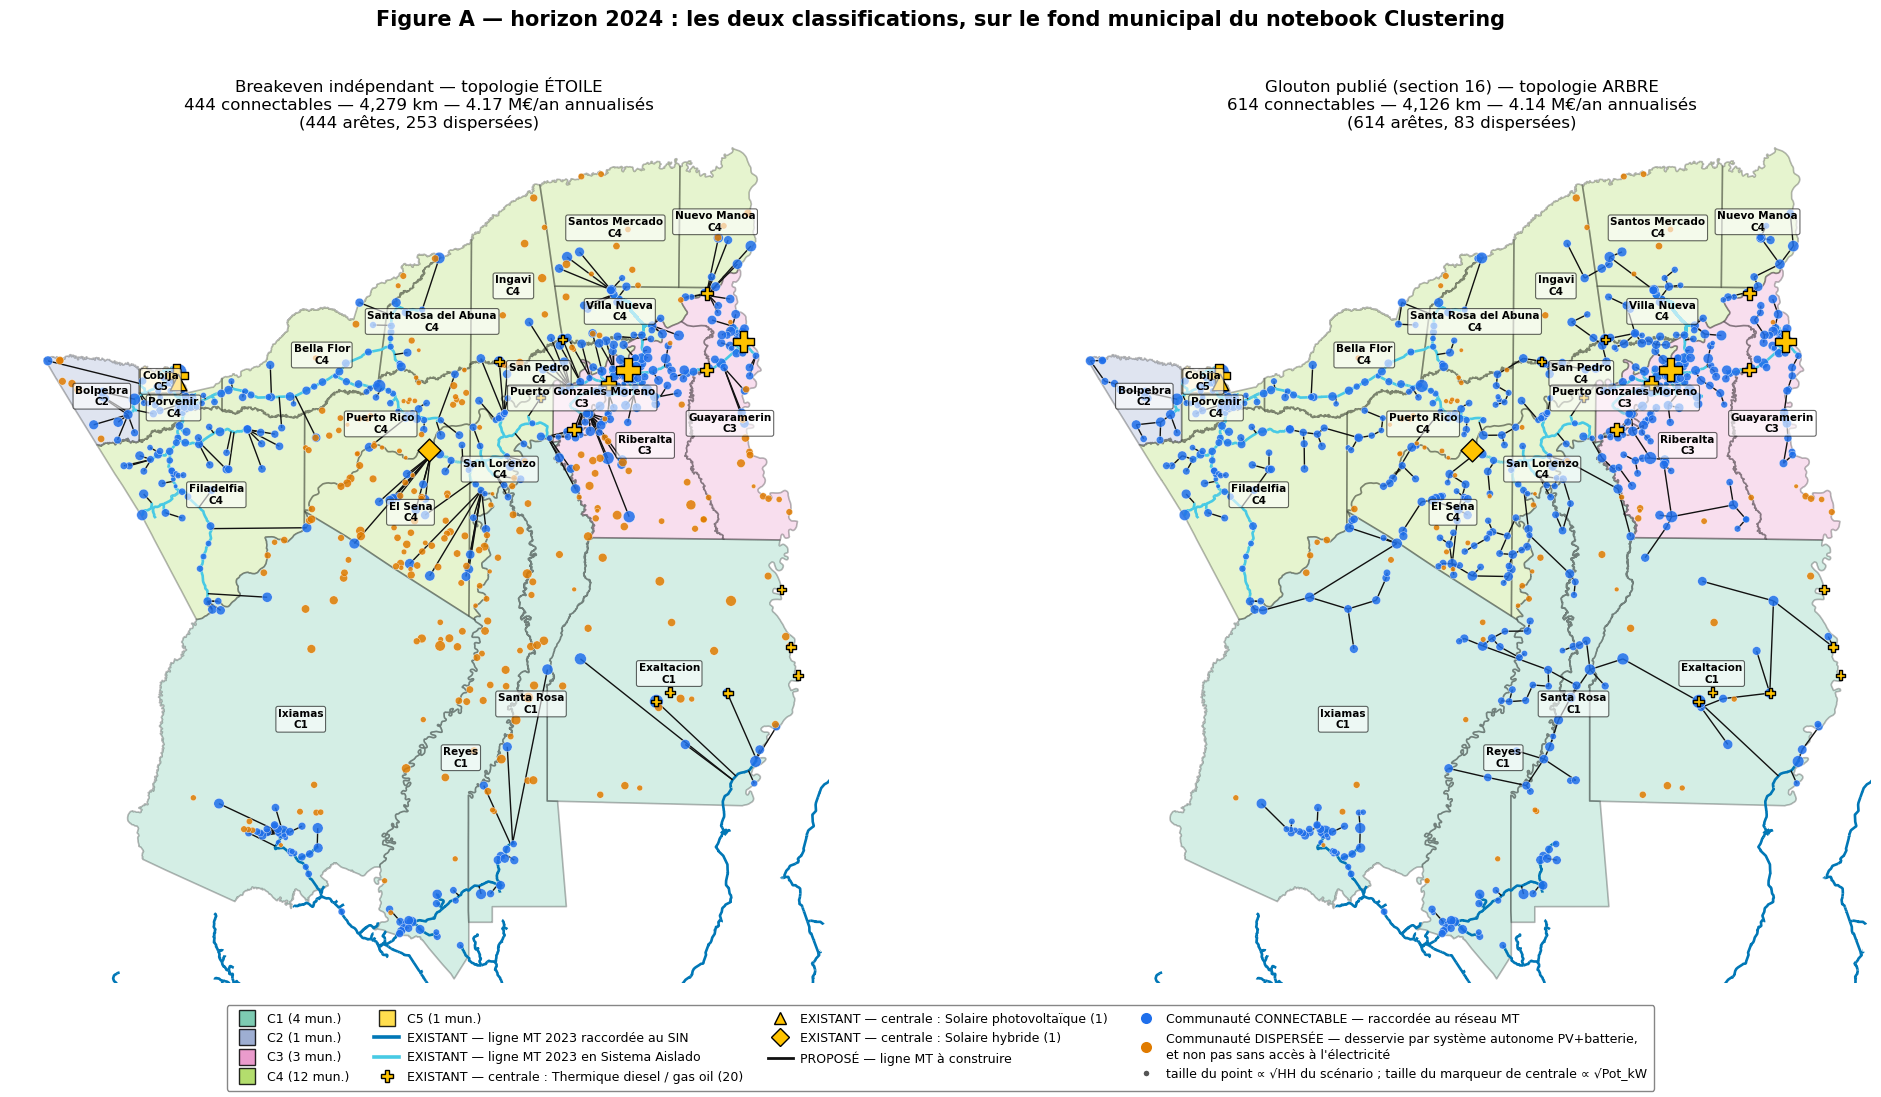

Figure A — 2024
  breakeven indépendant : 444 connectables, 4,279.43 km d'étoile, 4,170,409 EUR/an
  glouton publié        : 614 connectables, 4,125.63 km d'arbre, 4,142,915 EUR/an
  Communauté DISPERSÉE — desservie par système autonome PV+batterie,
et non pas sans accès à l'électricité


In [134]:
# ── 18.2 Figure A — horizon 2024 : breakeven indépendant (étoile) vs glouton publié ──
# Gauche  : classification par breakeven indépendant (section 7, conn_by_year), topologie
#           ÉTOILE — chaque connectable rejoint directement le réseau MT par sa
#           perpendiculaire. C'est la classification NON publiée depuis la section 16.
# Droite  : classification gloutonne à rejet définitif (section 16, pub_R), topologie
#           ARBRE — arêtes du glouton, intra-cluster.
# Les deux capex annualisés sont ceux de leur propre topologie : étoile avec poste
# transformateur à gauche (extension_capex_star_annualise_EUR, section 7), arbre à droite
# (extension_capex_annualise_EUR de published_summaries, section 16.2).
_y = "2024"

_N_STAR_ATTENDU, _N_TREE_ATTENDU = 444, 614   # valeurs de contrôle de l'énoncé
assert int(conn_by_year[_y].sum()) == _N_STAR_ATTENDU, \
    f"breakeven indépendant {_y} : {int(conn_by_year[_y].sum())} != {_N_STAR_ATTENDU}"
assert int(pub_R[_y].sum()) == _N_TREE_ATTENDU, \
    f"glouton publié {_y} : {int(pub_R[_y].sum())} != {_N_TREE_ATTENDU}"

_hh = hh_by_year[_y]
_ann_star = float(scenario_summaries[_y].set_index("Cluster")
                  .loc["TOTAL", "extension_capex_star_annualise_EUR"])
_ann_tree = float(published_summaries[_y].set_index("Cluster")
                  .loc["TOTAL", "extension_capex_annualise_EUR"])

_panneaux = [
    ("Breakeven indépendant — topologie ÉTOILE",
     conn_by_year[_y], _segments_star(conn_by_year[_y]), star_len[_y], _ann_star,
     "Antenne directe vers le réseau MT"),
    ("Glouton publié (section 16) — topologie ARBRE",
     pub_R[_y], _segments_tree(pub_edges[_y]), pub_km[_y], _ann_tree,
     "Arête de l'arbre glouton"),
]

fig, axes = plt.subplots(1, 2, figsize=(21, 11))
for ax, (titre, conn, segs, km, ann, lab_edge) in zip(axes, _panneaux):
    _base_map_muni(ax)
    ax.add_collection(LineCollection(segs, colors=C_EDGE, linewidths=1.0, zorder=2))
    _plot_points(ax, conn, _hh)
    ax.set_title(f"{titre}\n{int(conn.sum())} connectables — {km:,.0f} km — "
                 f"{ann / 1e6:.2f} M€/an annualisés\n"
                 f"({len(segs)} arêtes, {int((~conn).sum())} dispersées)", fontsize=12)

fig.legend(handles=_muni_handles() + _legend_handles_18(
    [Line2D([], [], color=C_EDGE, lw=2.0, label="PROPOSÉ — ligne MT à construire")]),
    loc="lower center", ncol=4, fontsize=9, frameon=True, edgecolor="gray",
    facecolor="white", framealpha=0.95, borderpad=0.6, handletextpad=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.87, bottom=0.10)
plt.suptitle(f"Figure A — horizon {_y} : les deux classifications, sur le fond municipal "
             f"du notebook Clustering",
             fontweight="bold", fontsize=15, y=0.985)
plt.show()

print(f"Figure A — {_y}")
print(f"  breakeven indépendant : {_N_STAR_ATTENDU} connectables, "
      f"{star_len[_y]:,.2f} km d'étoile, {_ann_star:,.0f} EUR/an")
print(f"  glouton publié        : {_N_TREE_ATTENDU} connectables, "
      f"{pub_km[_y]:,.2f} km d'arbre, {_ann_tree:,.0f} EUR/an")
print(f"  {LEGENDE_DISPERSEE}")

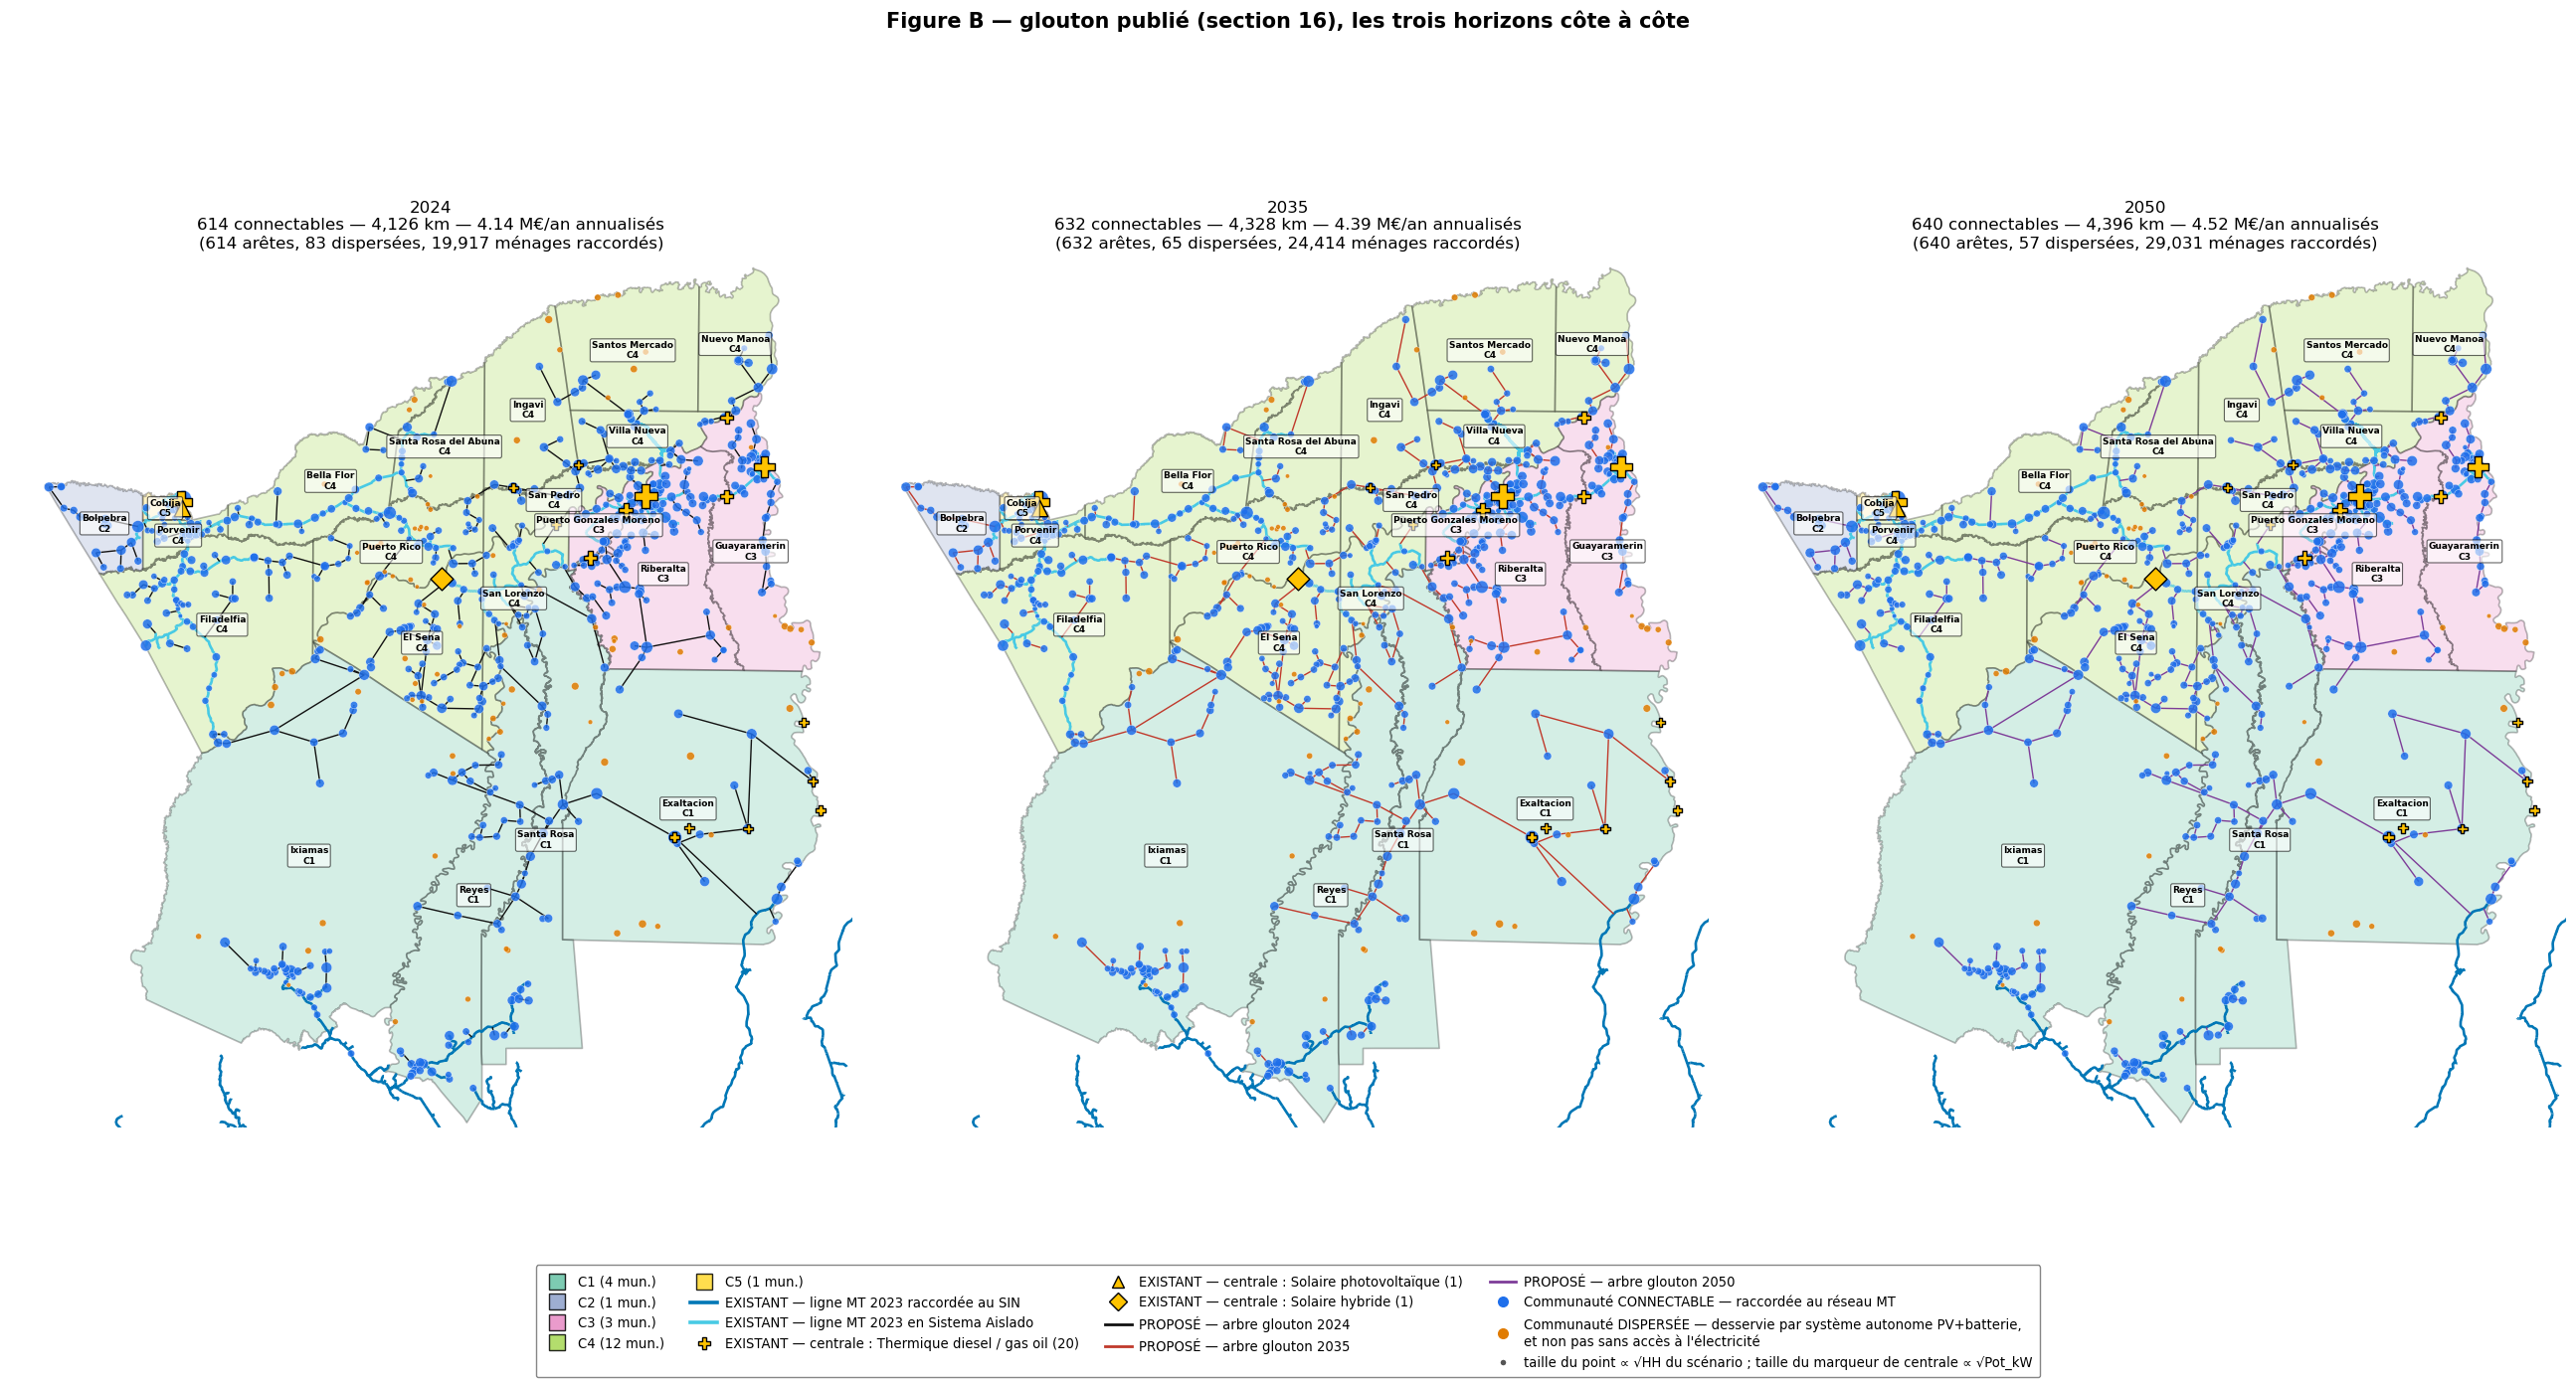

Figure B — glouton publié
  2024 : 614 connectables, 4,125.63 km,  83 dispersées,  4,142,915 EUR/an
  2035 : 632 connectables, 4,327.57 km,  65 dispersées,  4,393,346 EUR/an
  2050 : 640 connectables, 4,396.38 km,  57 dispersées,  4,524,678 EUR/an
  Communauté DISPERSÉE — desservie par système autonome PV+batterie,
et non pas sans accès à l'électricité


In [135]:
# ── 18.3 Figure B — les trois horizons du glouton publié ────────────────────
# Même topologie et même classification que la section 16, un panneau par horizon.
# Les arbres gloutons ne sont PAS incrémentaux (markdown de la section 16) : chaque
# panneau porte l'arbre construit indépendamment pour son horizon. Seul l'emboîtement
# des ENSEMBLES connectables est garanti, et il est réasserté ici.
for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
    assert not (pub_R[_a] & ~pub_R[_b]).any(), f"emboîtement rompu entre {_a} et {_b}"

fig, axes = plt.subplots(1, 3, figsize=(26, 14))
for ax, _y in zip(axes, EXT_YEARS):
    _segs = _segments_tree(pub_edges[_y])
    _ann = float(published_summaries[_y].set_index("Cluster")
                 .loc["TOTAL", "extension_capex_annualise_EUR"])
    _base_map_muni(ax, label_fs=6.5)
    ax.add_collection(LineCollection(_segs, colors=C_BY_YEAR[_y], linewidths=1.0, zorder=2))
    _plot_points(ax, pub_R[_y], hh_by_year[_y])
    ax.set_title(f"{_y}\n{int(pub_R[_y].sum())} connectables — {pub_km[_y]:,.0f} km — "
                 f"{_ann / 1e6:.2f} M€/an annualisés\n"
                 f"({len(_segs)} arêtes, {int((~pub_R[_y]).sum())} dispersées, "
                 f"{hh_by_year[_y][pub_R[_y]].sum():,.0f} ménages raccordés)", fontsize=12)

fig.legend(handles=_muni_handles() + _legend_handles_18(
    [Line2D([], [], color=C_BY_YEAR[_y2], lw=2.0,
            label=f"PROPOSÉ — arbre glouton {_y2}") for _y2 in EXT_YEARS]),
    loc="lower center", ncol=4, fontsize=9.5, frameon=True, edgecolor="gray",
    facecolor="white", framealpha=0.95, borderpad=0.6, handletextpad=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.90, bottom=0.09)
plt.suptitle("Figure B — glouton publié (section 16), les trois horizons côte à côte",
             fontweight="bold", fontsize=15, y=0.985)
plt.show()

print("Figure B — glouton publié")
for _y in EXT_YEARS:
    print(f"  {_y} : {int(pub_R[_y].sum()):>3} connectables, {pub_km[_y]:>8,.2f} km, "
          f"{int((~pub_R[_y]).sum()):>3} dispersées, "
          f"{float(published_summaries[_y].set_index('Cluster').loc['TOTAL', 'extension_capex_annualise_EUR']):>10,.0f} EUR/an")
print(f"  {LEGENDE_DISPERSEE}")

─── chemin cumulé maximal jusqu'au réseau, par cluster (arbre glouton 2024) ───
  C1 :  292.40 km
  C2 :   75.02 km
  C3 :  143.43 km
  C4 :  195.25 km
  C5 :    3.54 km



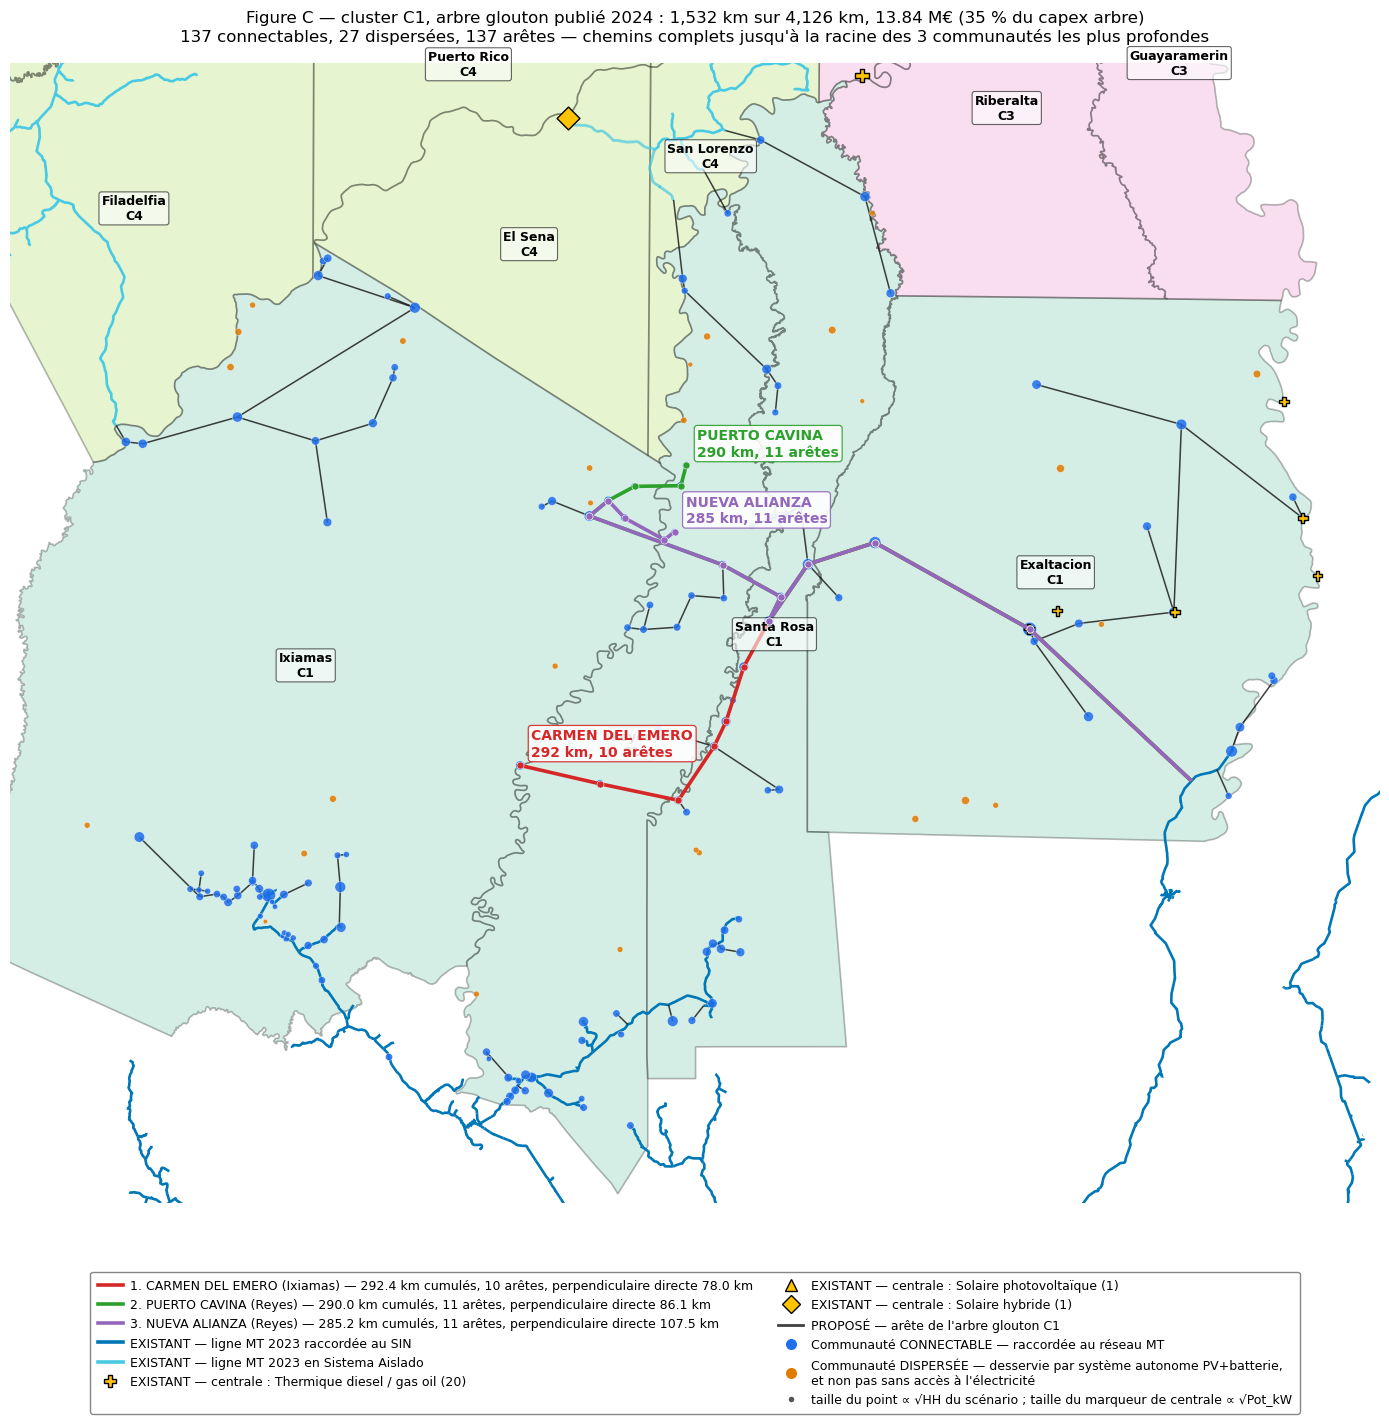

─── C1, arbre glouton 2024 — les 3 plus longs chemins jusqu'au réseau ───
  1. CARMEN DEL EMERO (Ixiamas) — 292.40 km cumulés, 10 arêtes, perpendiculaire directe 78.03 km, HH 44.4
     chemin : CARMEN DEL EMERO -> SAN PEDRO -> EL CANDADO -> TACUARAL -> EL ENCERRADO -> EL CERRITO -> PALMA FLOR -> AUSTRALIA -> ESTANCIAS DISPERSAS -> COQUINAL -> RACINE (réseau MT 2023)
  2. PUERTO CAVINA (Reyes) — 290.01 km cumulés, 11 arêtes, perpendiculaire directe 86.09 km, HH 19.7
     chemin : PUERTO CAVINA -> MISION CAVINAS -> CAYUBABA -> BARRACON -> EMBAJADORES DEL MADIDI -> CANDELARIA -> PORVENIR -> PALMA FLOR -> AUSTRALIA -> ESTANCIAS DISPERSAS -> COQUINAL -> RACINE (réseau MT 2023)
  3. NUEVA ALIANZA (Reyes) — 285.16 km cumulés, 11 arêtes, perpendiculaire directe 107.50 km, HH 7.7
     chemin : NUEVA ALIANZA -> PEÑA GUARAYO -> CAMPESINA LAS PALMAS -> BARRACON -> EMBAJADORES DEL MADIDI -> CANDELARIA -> PORVENIR -> PALMA FLOR -> AUSTRALIA -> ESTANCIAS DISPERSAS -> COQUINAL -> RACINE (réseau MT 202

In [136]:
# ── 18.4 Figure C — zoom sur C1, arbre glouton publié 2024, trois chemins les plus longs ──
# C1 est le cluster où le chemin cumulé jusqu'au réseau atteint son maximum, 292 km
# (section 14 : même diagnostic sur l'arbre glouton). Les trois communautés retenues sont
# les trois plus longs chemins cumulés de C1 ; leur chemin COMPLET jusqu'à la racine est
# tracé en couleur, arête par arête, sur l'arbre gris du cluster.
# N_CHEMINS = 3 — imposé par l'énoncé.
# C_CHEMINS — trois couleurs distinctes du reste de la palette (arêtes noires, points
#   bleu/orange, polygones vert d'eau) ; valeur de mise en page.
_y = "2024"
N_CHEMINS = 3
C_CHEMINS = ["#d62728", "#2ca02c", "#9467bd"]

_c1 = (CL_ARR == "C1")
_par = tree_parents(pub_edges[_y])
# Les arêtes étant strictement intra-cluster (edges_length_by_cluster asserte ce point),
# celles de C1 se sélectionnent sans ambiguïté.
_edges_c1 = {e: w for e, w in pub_edges[_y].items() if all(_c1[n] for n in e if n != ROOT)}

_cum = {}
for _n in _par:
    if _c1[_n]:
        _chain, _L = path_to_root(_n, _par)
        _cum[_n] = (_chain, _L)
_tops = sorted(_cum, key=lambda n: -_cum[n][1])[:N_CHEMINS]

# ASSERTIONS : C1 porte bien le maximum tous clusters confondus, et ce maximum est 292 km
_max_par_cluster = {}
for _cl in CLUSTERS:
    _l = [path_to_root(n, _par)[1] for n in _par if CL_ARR[n] == _cl]
    _max_par_cluster[_cl] = max(_l) if _l else 0.0
assert max(_max_par_cluster, key=_max_par_cluster.get) == "C1", \
    f"le chemin cumulé maximal n'est pas dans C1 : {_max_par_cluster}"
assert abs(_max_par_cluster["C1"] - 292) < 1.0, \
    f"chemin cumulé maximal de C1 = {_max_par_cluster['C1']:.2f} km, attendu ~292 km"
print("─── chemin cumulé maximal jusqu'au réseau, par cluster (arbre glouton 2024) ───")
for _cl in CLUSTERS:
    print(f"  {_cl} : {_max_par_cluster[_cl]:>7.2f} km")
print()

fig, ax = plt.subplots(figsize=(14, 14))
_base_map_muni(ax, sub=_c1, label_fs=9)
ax.add_collection(LineCollection(_segments_tree(_edges_c1), colors=C_EDGE,
                                 linewidths=1.1, alpha=0.8, zorder=2))
_plot_points(ax, pub_R[_y], hh_by_year[_y], sub=_c1)

_handles_chemins = []
for _rang, (_n, _col) in enumerate(zip(_tops, C_CHEMINS), 1):
    _chain, _L = _cum[_n]
    _segs = [[(XY[a, 0], XY[a, 1]), (XY[b, 0], XY[b, 1])]
             for a, b in zip(_chain, _chain[1:])]
    _segs.append([(XY[_chain[-1], 0], XY[_chain[-1], 1]),
                  (FOOT[_chain[-1], 0], FOOT[_chain[-1], 1])])
    # ASSERTION : le chemin tracé compte exactement autant de segments que d'arêtes
    assert len(_segs) == len(_chain), "chemin tracé incomplet"
    ax.add_collection(LineCollection(_segs, colors=_col, linewidths=2.6, zorder=4))
    ax.scatter(XY[_chain, 0], XY[_chain, 1], s=26, c=_col, zorder=5,
               edgecolor="white", linewidth=0.4)
    ax.annotate(f"{task1_geo['Comunidad'].iloc[_n]}\n{_L:,.0f} km, {len(_chain)} arêtes",
                (XY[_n, 0], XY[_n, 1]), xytext=(8, 7), textcoords="offset points",
                fontsize=10, weight="bold", color=_col, zorder=6,
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec=_col,
                          linewidth=0.9, alpha=0.9))
    _handles_chemins.append(Line2D([], [], color=_col, lw=2.6, label=(
        f"{_rang}. {task1_geo['Comunidad'].iloc[_n]} "
        f"({task1_geo['Municipio_std'].iloc[_n].replace('_', ' ')}) — "
        f"{_L:,.1f} km cumulés, {len(_chain)} arêtes, "
        f"perpendiculaire directe {D_GRID[_n]:,.1f} km")))

_km_c1 = pub_km_cluster[_y]["C1"]
_cs = published_summaries[_y].set_index("Cluster")
ax.set_title(
    f"Figure C — cluster C1, arbre glouton publié {_y} : "
    f"{_km_c1:,.0f} km sur {pub_km[_y]:,.0f} km, "
    f"{_cs.loc['C1', 'extension_capex_EUR'] / 1e6:.2f} M€ "
    f"({100 * _cs.loc['C1', 'extension_capex_EUR'] / _cs.loc['TOTAL', 'extension_capex_EUR']:.0f} % du capex arbre)\n"
    f"{int(pub_R[_y][_c1].sum())} connectables, {int((~pub_R[_y][_c1]).sum())} dispersées, "
    f"{len(_edges_c1)} arêtes — chemins complets jusqu'à la racine des "
    f"{N_CHEMINS} communautés les plus profondes",
    fontsize=12, pad=16)
fig.legend(handles=_handles_chemins + _legend_handles_18(
    [Line2D([], [], color=C_EDGE, lw=2.0, alpha=0.8,
            label="PROPOSÉ — arête de l'arbre glouton C1")]),
    loc="lower center", ncol=2, fontsize=9, frameon=True, edgecolor="gray",
    facecolor="white", framealpha=0.95, borderpad=0.6, handletextpad=0.6)
plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()

print(f"─── C1, arbre glouton {_y} — les {N_CHEMINS} plus longs chemins jusqu'au réseau ───")
for _rang, _n in enumerate(_tops, 1):
    _chain, _L = _cum[_n]
    print(f"  {_rang}. {task1_geo['Comunidad'].iloc[_n]} "
          f"({task1_geo['Municipio_std'].iloc[_n]}) — {_L:,.2f} km cumulés, "
          f"{len(_chain)} arêtes, perpendiculaire directe {D_GRID[_n]:,.2f} km, "
          f"HH {hh_by_year[_y][_n]:,.1f}")
    print("     chemin : " + " -> ".join(
        [task1_geo["Comunidad"].iloc[i] for i in _chain] + ["RACINE (réseau MT 2023)"]))
print()
print(f"  {LEGENDE_DISPERSEE}")
print("RAPPEL — section 18 : figures affichées en sortie de cellule, aucun fichier écrit.")

## 19. Datation du coût unitaire et reclassification au coût actualisé — DIAGNOSTIC SEUL

**Cette section n'écrit aucun fichier et ne remplace aucune valeur publiée.** La valeur
publiée reste `MV_USD = 9 000` (section 1, section 16).

### 19.a — Ce qui est confirmé : l'indice CPI

`CPI_2014 = 236.736` et `CPI_2024 = 313.689`, moyennes annuelles de l'indice CPI-U
*All Urban Consumers, U.S. city average, all items, 1982-84 = 100*, série **CUUR0000SA0**,
période **M13** (« Annual »), obtenues de l'API publique du **Bureau of Labor Statistics** :

```
POST https://api.bls.gov/publicAPI/v2/timeseries/data/
{"seriesid":["CUUR0000SA0"],"startyear":"2014","endyear":"2023","annualaverage":true}
{"seriesid":["CUUR0000SA0"],"startyear":"2016","endyear":"2025","annualaverage":true}
```

(deux requêtes, l'API plafonnant une requête à dix années). Facteur
`CPI_2024 / CPI_2014 = 1.325058`. Recoupement indépendant : la page BLS de la série
CUUR0000SA0 affiche pour 2024 des moyennes semestrielles de 312.145 et 315.233, dont la
moyenne est bien 313.689.

### 19.b — Ce qui n'est PAS confirmé : l'année monétaire de la table A.5

> ## SOURCE ABSENTE
>
> **L'année de base monétaire de `MV_USD = 9 000`, `CONN_USD = 150` et `TRAFO_USD = 3 500`
> n'a pas pu être établie.**
>
> - Le texte de Peña Balderrama et al. 2020, ESD 56, n'est pas accessible : ScienceDirect
>   renvoie HTTP 403 (PII S0973082620302180), et aucune version en texte intégral n'est
>   déposée dans DiVA (KTH, notice diva2:1442651, « full text via publisher ») ni dans ORBi
>   (ULiège). La note *b* de la table A.5 n'a donc pas pu être lue.
> - Le document « ESMAP 2014 » vers lequel cette note renverrait n'a pas pu être identifié :
>   la recherche ne ramène que *Reducing the Cost of Grid Extension for Rural Electrification*
>   (ESM227), qui est de 2000, et les rapports *Global Tracking Framework*, dont aucun n'est
>   une source de coûts unitaires de ligne MT. Son année monétaire propre est donc elle aussi
>   inconnue.
> - Aucun exemplaire de l'article ni du rapport ESMAP n'est versionné dans
>   `bolivia-energy-data` (recherche `*.pdf` : seuls deux exports du notebook Clustering).
>
> **Aucun facteur n'est donc inventé pour dater la table A.5.** Le facteur 1.325058 ci-dessus
> est l'escalade CPI **2014 → 2024**, rien de plus : il ne devient un facteur d'actualisation
> de la table A.5 que **si** cette table est en USD 2014, ce qui reste une hypothèse non
> vérifiée.

### 19.c — Ce que vaut l'hypothèse

Tout ce qui suit est calculé **sous l'hypothèse déclarée et non vérifiée** « table A.5 en
USD 2014 ». La section 19.1 applique le facteur aux **trois** postes — ligne, transformateur
et raccordement — et la section 19.2 rejoue la classification gloutonne du bloc 24 avec ces
trois postes actualisés.

L'hypothèse a un appui, purement numérique : `9 000 × 1.325058 = 11 926 USD/km` tombe à
1.2 % de la valeur ENDE 2021 (12 072 USD/km) et à 2.7 % de la valeur BID Paraguay 2025
(12 262 USD/km) de la section 17. Trois chiffres d'origines indépendantes qui convergent
vers ~12 000 USD/km 2024 rendent l'hypothèse plausible — ils ne la démontrent pas, et ne
remplacent pas la note *b*.

**Propriété utile de l'escalade uniforme.** Les trois postes étant multipliés par le même
facteur, `TRAFO_KM_EQ = TRAFO_EUR / MV_EUR` est **invariant** — c'est asserté en 19.2. La
décision de `classify_communities` revient alors à comparer le coût autonome *divisé par le
facteur* au coût d'extension d'origine : l'escalade uniforme déplace la frontière autrement
qu'une hausse du seul coût du kilomètre (section 17), et les deux ne sont pas comparables
terme à terme.

In [137]:
# ── 19.1 Escalade CPI des trois postes de la table A.5 ──────────────────────
# CPI_2014, CPI_2024 — moyennes annuelles de la serie CUUR0000SA0 (CPI-U, All Urban
#   Consumers, U.S. city average, all items, base 1982-84 = 100), periode M13 « Annual »,
#   API publique du Bureau of Labor Statistics :
#     POST https://api.bls.gov/publicAPI/v2/timeseries/data/
#          {"seriesid":["CUUR0000SA0"],"startyear":"2014","endyear":"2023",
#           "annualaverage":true}
#          {"seriesid":["CUUR0000SA0"],"startyear":"2016","endyear":"2025",
#           "annualaverage":true}
#   Deux requetes parce que l'API plafonne une requete a dix annees. Valeurs recuperees le
#   2026-08-14. Recoupement : la page BLS de la serie affiche pour 2024 des moyennes
#   semestrielles 312.145 et 315.233, de moyenne 313.689.
# MV_USD / CONN_USD / TRAFO_USD — sections 1 et 7bis.2, Pena Balderrama et al. 2020 table A.5.
# FX = 0.924 — section 1.
#
# *** L'ANNEE MONETAIRE DE LA TABLE A.5 EST INCONNUE : voir le bloc SOURCE ABSENTE du
# *** markdown 19.b. Tout ce qui suit est CONDITIONNEL a l'hypothese « table A.5 en USD 2014 »,
# *** qui n'est PAS verifiee. Ce n'est pas une datation, c'est un scenario.
CPI_2014 = 236.736
CPI_2024 = 313.689
CPI_SERIE = "CUUR0000SA0 / M13 (annual), BLS public API v2"
CPI_FACTEUR = CPI_2024 / CPI_2014

assert abs(CPI_FACTEUR - 1.325058) < 1e-6, f"facteur CPI inattendu : {CPI_FACTEUR}"
print(f"CPI-U {CPI_SERIE}")
print(f"  moyenne annuelle 2014 : {CPI_2014}")
print(f"  moyenne annuelle 2024 : {CPI_2024}")
print(f"  facteur 2014 -> 2024  : {CPI_FACTEUR:.6f}")
print()
print("ANNEE MONETAIRE DE LA TABLE A.5 : SOURCE ABSENTE (markdown 19.b). "
      "Le facteur ci-dessus est une escalade CPI 2014->2024, pas une datation.")
print()

POSTES_USD_2014 = {"MV (EUR/km)": MV_USD, "CONN (EUR/menage)": CONN_USD,
                   "TRAFO (EUR/communaute)": TRAFO_USD}
_rows = []
for _nom, _usd in POSTES_USD_2014.items():
    _usd24 = _usd * CPI_FACTEUR
    _rows.append({
        "poste": _nom,
        "USD table A.5": _usd,
        "USD 2024 (hypothese)": round(_usd24, 2),
        "EUR 2024 @ FX 0.924": round(_usd24 * FX, 2),
        "EUR publie (section 1)": round(_usd * FX, 2),
    })
bloc26 = pd.DataFrame(_rows)
print("─── escalade CPI des trois postes, SOUS HYPOTHESE NON VERIFIEE ───")
print(bloc26.to_string(index=False))
print()

MV_EUR_CPI = MV_USD * CPI_FACTEUR * FX
CONN_EUR_CPI = CONN_USD * CPI_FACTEUR * FX
TRAFO_EUR_CPI = TRAFO_USD * CPI_FACTEUR * FX

print("─── convergence avec les deux sources externes de la section 17 ───")
for _lab, _usd in [("ENDE 2021 (hors depot)", MV_USD_ENDE_2021),
                   ("BID 2025 Paraguay", MV_USD_BID_2025_PY)]:
    _ecart = 100 * (MV_USD * CPI_FACTEUR / _usd - 1)
    print(f"  MV actualise {MV_USD * CPI_FACTEUR:>9,.0f} USD/km  vs  {_lab:<24} "
          f"{_usd:>9,.0f} USD/km   ecart {_ecart:+6.2f} %")
print("  (convergence numerique ; elle rend l'hypothese plausible, elle ne la demontre pas)")

CPI-U CUUR0000SA0 / M13 (annual), BLS public API v2
  moyenne annuelle 2014 : 236.736
  moyenne annuelle 2024 : 313.689
  facteur 2014 -> 2024  : 1.325058

ANNEE MONETAIRE DE LA TABLE A.5 : SOURCE ABSENTE (markdown 19.b). Le facteur ci-dessus est une escalade CPI 2014->2024, pas une datation.

─── escalade CPI des trois postes, SOUS HYPOTHESE NON VERIFIEE ───
                 poste  USD table A.5  USD 2024 (hypothese)  EUR 2024 @ FX 0.924  EUR publie (section 1)
           MV (EUR/km)           9000              11925.52             11019.18                  8316.0
     CONN (EUR/menage)            150                198.76               183.65                   138.6
TRAFO (EUR/communaute)           3500               4637.70              4285.24                  3234.0

─── convergence avec les deux sources externes de la section 17 ───
  MV actualise    11,926 USD/km  vs  ENDE 2021 (hors depot)      12,072 USD/km   ecart  -1.21 %
  MV actualise    11,926 USD/km  vs  BID 2025 Paragua

In [138]:
# ── 19.2 Reclassification gloutonne aux trois postes actualises ─────────────
# Meme algorithme qu'en 17.1 (greedy_connect_mv), etendu aux TROIS postes : le
# raccordement CONN_EUR et le transformateur TRAFO_EUR sont actualises au meme titre
# que le kilometre MV_EUR. Aucune autre constante ne bouge — memes menages par horizon,
# memes distances, meme CRF_MV, meme shs_annual, meme regle d'arret a rejet definitif.
# Rappel : tout ceci est conditionnel a l'hypothese non verifiee du markdown 19.b.


def capex_posts_3(length_km, n_connectable, hh_connectable, mv_eur, trafo_eur, conn_eur):
    """capex_posts (section 7bis.2) avec les TROIS postes parametres.
    A (MV_EUR, TRAFO_EUR, CONN_EUR) elle rend exactement capex_posts — asserte plus bas."""
    ligne = length_km * mv_eur
    transfo = n_connectable * trafo_eur
    raccord = hh_connectable * conn_eur
    total = ligne + transfo + raccord
    return {"ligne_EUR": ligne, "transformateur_EUR": transfo,
            "raccordement_EUR": raccord, "total_EUR": total,
            "total_annualise_EUR": CRF_MV * total}


def greedy_connect_costs(hh, mv_eur, conn_eur, trafo_eur):
    """greedy_connect_v2 (cellule 15.1) parametree par les trois postes de capex."""
    trafo_km_eq = trafo_eur / mv_eur
    n = len(hh)
    R = np.zeros(n, dtype=bool)
    blocked = np.zeros(n, dtype=bool)
    edges = {}
    attach_cost = D_GRID.astype(float).copy()
    attach_parent = np.full(n, ROOT, dtype=int)

    while True:
        elig = np.where((~R) & (~blocked))[0]
        if len(elig) == 0:
            break

        ext = mv_eur * attach_cost[elig] / hh[elig] + conn_eur + trafo_eur / hh[elig]
        c = int(elig[np.argmin(ext)])

        row = task1_geo.iloc[[c]].copy()
        row["HH_2024_scaled"] = hh[c]
        row["distance_km"] = attach_cost[c] + trafo_km_eq
        verdict = classify_communities(row, shs_annual, mv_eur, conn_eur, CRF_MV)
        assert len(verdict) == 1, "classify_communities a ecarte le candidat (HH <= 0)"

        if bool(verdict["dispersed"].iloc[0]):
            blocked[c] = True
            continue

        n_before = int(R.sum())
        R[c] = True
        edges[frozenset((c, int(attach_parent[c])))] = float(attach_cost[c])
        assert int(R.sum()) == n_before + 1, "R n'a pas cru d'exactement une communaute"
        assert len(edges) == int(R.sum()), "une arete par communaute raccordee"

        cand = np.where((~R) & (CL_ARR == CL_ARR[c]))[0]
        if len(cand):
            better = D_COMM[cand, c] < attach_cost[cand]
            attach_cost[cand[better]] = D_COMM[cand[better], c]
            attach_parent[cand[better]] = c

    return R, edges


# ASSERTION : TRAFO_KM_EQ est invariant sous escalade uniforme des trois postes.
assert abs(TRAFO_EUR_CPI / MV_EUR_CPI - TRAFO_EUR / MV_EUR) < 1e-12, \
    "TRAFO_KM_EQ devrait etre invariant sous escalade uniforme"
print(f"TRAFO_KM_EQ invariant : {TRAFO_EUR / MV_EUR:.6f} km avant et apres escalade")
print()

COUTS = {
    "publie":      (MV_EUR,     CONN_EUR,     TRAFO_EUR),
    "CPI_2014_24": (MV_EUR_CPI, CONN_EUR_CPI, TRAFO_EUR_CPI),
}
print("─── jeux de couts compares ───")
for _lab, (_mv, _cn, _tr) in COUTS.items():
    print(f"  {_lab:<12} MV {_mv:>9,.1f} EUR/km   CONN {_cn:>7,.2f} EUR/menage   "
          f"TRAFO {_tr:>9,.1f} EUR/communaute")
print()

cpi_R, cpi_edges = {}, {}
for _lab, (_mv, _cn, _tr) in COUTS.items():
    for _y in EXT_YEARS:
        _R, _E = greedy_connect_costs(hh_by_year[_y], _mv, _cn, _tr)
        # ── ASSERTIONS, identiques a la cellule 15.1 ─────────────────────────
        _km = float(sum(_E.values()))
        assert len(_E) == int(_R.sum()), f"{_lab}/{_y} : arbre non couvrant de R"
        _par = parent_edge_length(_E)
        assert set(_par) == set(np.where(_R)[0]), f"{_lab}/{_y} : arbre != R"
        _lc = edges_length_by_cluster(_E)
        assert abs(sum(_lc.values()) - _km) < 1e-6
        assert _km <= D_GRID[_R].sum() + 1e-9, f"{_lab}/{_y} : arbre plus long que l'etoile"
        cpi_R[(_lab, _y)], cpi_edges[(_lab, _y)] = _R, _E

# ASSERTIONS DE NON-REGRESSION : aux couts publies, greedy_connect_costs et capex_posts_3
# doivent reproduire exactement la section 16.
for _y in EXT_YEARS:
    assert (cpi_R[("publie", _y)] == pub_R[_y]).all(), f"{_y} : cpi_R publie != pub_R"
    assert cpi_edges[("publie", _y)] == pub_edges[_y], f"{_y} : cpi_edges publie != pub_edges"
    _a = capex_posts_3(pub_km[_y], int(pub_R[_y].sum()),
                       float(hh_by_year[_y][pub_R[_y]].sum()),
                       MV_EUR, TRAFO_EUR, CONN_EUR)
    _b = capex_posts(pub_km[_y], int(pub_R[_y].sum()),
                     float(hh_by_year[_y][pub_R[_y]].sum()))
    assert all(abs(_a[k] - _b[k]) < 1e-6 for k in _b), f"{_y} : capex_posts_3 != capex_posts"
print("ASSERTIONS DE NON-REGRESSION OK — aux couts publies, greedy_connect_costs reproduit "
      "pub_R / pub_edges et capex_posts_3 reproduit capex_posts")
print()

# ── Tableau principal ───────────────────────────────────────────────────────
_rows = []
for _lab, (_mv, _cn, _tr) in COUTS.items():
    for _y in EXT_YEARS:
        _R, _E = cpi_R[(_lab, _y)], cpi_edges[(_lab, _y)]
        _km = float(sum(_E.values()))
        _cap = capex_posts_3(_km, int(_R.sum()), float(hh_by_year[_y][_R].sum()),
                             _mv, _tr, _cn)
        _rows.append({
            "variante": _lab,
            "annee": _y,
            "N_connectable": int(_R.sum()),
            "dN_vs_publie": int(_R.sum()) - int(pub_R[_y].sum()),
            "km_arbre": round(_km, 2),
            "capex_EUR": round(_cap["total_EUR"], 0),
            "capex_annualise_EUR": round(_cap["total_annualise_EUR"], 0),
            "capex_ligne_EUR": round(_cap["ligne_EUR"], 0),
            "capex_transfo_EUR": round(_cap["transformateur_EUR"], 0),
            "capex_raccord_EUR": round(_cap["raccordement_EUR"], 0),
            "n_bascules": int((_R != pub_R[_y]).sum()),
            "bascules_perdues": int((pub_R[_y] & ~_R).sum()),
            "bascules_gagnees": int((~pub_R[_y] & _R).sum()),
        })
bloc27 = pd.DataFrame(_rows)

print("─── N_connectable, km d'arbre et capex ───")
print(bloc27[["variante", "annee", "N_connectable", "dN_vs_publie", "km_arbre",
              "capex_EUR", "capex_annualise_EUR"]].to_string(index=False))
print()
print("─── decomposition du capex en trois postes ───")
print(bloc27[["variante", "annee", "capex_ligne_EUR", "capex_transfo_EUR",
              "capex_raccord_EUR", "capex_EUR"]].to_string(index=False))
print()
print("─── bascules par rapport au cas publie (section 16) ───")
print(bloc27[["variante", "annee", "n_bascules", "bascules_perdues",
              "bascules_gagnees"]].to_string(index=False))
print()

# ── Detail par cluster ──────────────────────────────────────────────────────
_rows = []
for _y in EXT_YEARS:
    _R = cpi_R[("CPI_2014_24", _y)]
    _lc = edges_length_by_cluster(cpi_edges[("CPI_2014_24", _y)])
    for _c in CLUSTERS:
        _m = CL_ARR == _c
        _rows.append({
            "annee": _y, "Cluster": _c,
            "N_connectable_publie": int((pub_R[_y] & _m).sum()),
            "N_connectable_CPI": int((_R & _m).sum()),
            "perdues": int((pub_R[_y] & ~_R & _m).sum()),
            "gagnees": int((~pub_R[_y] & _R & _m).sum()),
            "km_arbre_CPI": round(_lc[_c], 2),
            "km_arbre_publie": round(pub_km_cluster[_y][_c], 2),
        })
bloc27_cluster = pd.DataFrame(_rows)
print("─── detail par cluster, couts actualises ───")
print(bloc27_cluster.to_string(index=False))
print()

# ── share_dispersion ────────────────────────────────────────────────────────
# Meme definition qu'en 17.1 : menages disperses de l'horizon / SCENARIOS[annee], qui
# coincide en 2024 avec aggregate_clusters (section 6). L'egalite des denominateurs est
# deja assertee en 17.1.
_rows = []
for _y in EXT_YEARS:
    _R = cpi_R[("CPI_2014_24", _y)]
    for _c in CLUSTERS:
        _m = CL_ARR == _c
        _den = SCENARIOS[_y][_c]
        _num = float(hh_by_year[_y][_m & ~_R].sum())
        _num_pub = float(hh_by_year[_y][_m & ~pub_R[_y]].sum())
        _rows.append({
            "annee": _y, "Cluster": _c,
            "HH_disperses": round(_num, 1),
            "HH_cluster": round(_den, 1),
            "share_dispersion_CPI": round(_num / _den, 4) if _den else 0.0,
            "share_dispersion_publie": round(_num_pub / _den, 4) if _den else 0.0,
        })
bloc27_share = pd.DataFrame(_rows)
bloc27_share["d_share"] = (bloc27_share["share_dispersion_CPI"]
                           - bloc27_share["share_dispersion_publie"]).round(4)
print("─── share_dispersion par cluster, couts actualises ───")
print(bloc27_share.to_string(index=False))
print()

print("─── emboitement des ensembles connectables, couts actualises ───")
for _a, _b in zip(EXT_YEARS, EXT_YEARS[1:]):
    _lost = int((cpi_R[("CPI_2014_24", _a)] & ~cpi_R[("CPI_2014_24", _b)]).sum())
    print(f"  {_a} ⊂ {_b} : {_lost == 0}   (perdues : {_lost})")
print()

# ── 19.3 km a construire par an ─────────────────────────────────────────────
# Meme convention qu'en 12.1 : ANNEE_BASE = 2024, DUREE = {2035: 11, 2050: 26}.
# ATTENTION : les arbres gloutons ne sont PAS incrementaux (markdown de la section 16) ;
# `km_ajoutes` est donc une difference entre deux arbres construits independamment, pas
# le chantier d'une extension emboitee. La colonne est conservee pour rester comparable
# a la section 12.1, qui la calcule deja ainsi pour la topologie gloutonne.
print("─── km a construire par an, couts actualises vs publies ───")
_rows = []
for _lab in COUTS:
    _km = {_y: float(sum(cpi_edges[(_lab, _y)].values())) for _y in EXT_YEARS}
    for _i, _y in enumerate(EXT_YEARS):
        if DUREE[_y] == 0:
            continue
        _prev = EXT_YEARS[_i - 1]
        _dt = DUREE[_y] - DUREE[_prev]
        _rows.append({
            "variante": _lab, "horizon": _y,
            "km_total_arbre": round(_km[_y], 2),
            "duree_depuis_2024_ans": DUREE[_y],
            "km_par_an_total": round(_km[_y] / DUREE[_y], 2),
            "increment_depuis": _prev,
            "km_ajoutes": round(_km[_y] - _km[_prev], 2),
            "duree_increment_ans": _dt,
            "km_par_an_increment": round((_km[_y] - _km[_prev]) / _dt, 2),
        })
effort_cpi = pd.DataFrame(_rows)
print(effort_cpi.to_string(index=False))
print()
print("─── lecture demandee : arbre 2035 / 11 ans et arbre 2050 / 26 ans ───")
for _lab in COUTS:
    _km = {_y: float(sum(cpi_edges[(_lab, _y)].values())) for _y in EXT_YEARS}
    print(f"  {_lab:<12} : 2035  {_km['2035']:>8,.2f} km / 11 ans = "
          f"{_km['2035'] / 11:>6.2f} km/an")
    print(f"  {_lab:<12} : 2050  {_km['2050']:>8,.2f} km / 26 ans = "
          f"{_km['2050'] / 26:>6.2f} km/an")
print()
print("RAPPEL — section 19 : diagnostic, aucun fichier ecrit. Tout ce tableau est "
      "conditionnel a l'hypothese NON VERIFIEE du markdown 19.b (SOURCE ABSENTE).")

TRAFO_KM_EQ invariant : 0.388889 km avant et apres escalade

─── jeux de couts compares ───
  publie       MV   8,316.0 EUR/km   CONN  138.60 EUR/menage   TRAFO   3,234.0 EUR/communaute
  CPI_2014_24  MV  11,019.2 EUR/km   CONN  183.65 EUR/menage   TRAFO   4,285.2 EUR/communaute

ASSERTIONS DE NON-REGRESSION OK — aux couts publies, greedy_connect_costs reproduit pub_R / pub_edges et capex_posts_3 reproduit capex_posts

─── N_connectable, km d'arbre et capex ───
   variante annee  N_connectable  dN_vs_publie  km_arbre  capex_EUR  capex_annualise_EUR
     publie  2024            614             0   4125.63 39054905.0            4142915.0
     publie  2035            632             0   4327.57 41415700.0            4393346.0
     publie  2050            640             0   4396.38 42653750.0            4524678.0
CPI_2014_24  2024            563           -51   3477.27 44244885.0            4693464.0
CPI_2014_24  2035            601           -31   3997.14 51035184.0            5413774.0
